This workbook is testing a function for inputing loading gas and process data into python. 

import libraries.

In [3]:
import numpy as np
import pandas as pd
import glob
from collections import defaultdict
import matplotlib.pyplot as plt
from datetime import datetime, time
import warnings

warnings.filterwarnings("ignore")


In [4]:
import sys
sys.path.append("..")
from core.functions import *

background

perform a mass balance on CO2. 

\begin{gather*}
\frac{dCO_2}{dt} = In - Out + Gen\\
\textit{Assume steady-state (no CO2 build up in reactor) }\\
In - Out = -Gen == CER \\
Gen = M_{CO_2,in} - M_{CO_2,out} \\
\end{gather*}

Substitute in Ideal Gas Law.

\begin{gather*}
PV = nRT & \text{where} \\ n = \frac{M}{molecular weight} \\ \frac{PVm.w.}{RT}= M
\end{gather*}

Substitute

\begin{gather*}
Gen = (Pm.w._{CO_2} * F_{in} - Pm.w._{CO_2} * F_{out})/RT \\
Gen = \frac{Pm.w._{CO_2}}{RT}(F_{in} - F_{out})
\end{gather*}
Calculate out flow rate - will change with gas consumption and production, and humidy. 

*Assume no humidity in flow*


Nitrogen balance.
\begin{gather*}
N_{2,in} = N_{2,out} \\
y_{N_{2,in}}*F_{in} = y_{N_{2,out}}*F_{out}
\end{gather*}

\begin{gather*}
y_{N_{2,in}} = 1 - y_{O_2,in} -y_{CO_2,in} \\
y_{N_{2,out}} = 1 - y_{O_2,out} -y_{CO_2,out} - y_{H_2O,out}
\end{gather*}

Ideal gas law
\begin{gather*}
P_1V_1 = n_1RT_1 \\
P_2V_2 = n_2RT_2 \\
V_2 = \frac{n_2V_1}{n_1} \\
V_2 = \frac{1 - y_{O_2,out} -y_{CO_2,out} - y_{H_2O,out}}{1 - y_{O_2,in} -y_{CO_2,in}}V_1
\end{gather*}


Finally:
\begin{gather*}
Gen = \frac{Pm.w._{CO_2}}{RT}F_{in}(1 - \frac{1 - y_{O_2,out} -y_{CO_2,out} - y_{H_2O,out}}{1 - y_{O_2,in} -y_{CO_2,in}})
\end{gather*}

OUR/CER from Biostat config file:

OUR.Value = (20.9 - (79.07*O2.Value/(100-O2.Value - CO2.Value))) * AIRFL.Value / V.Value*26.44



OUR.Value = (20.9 - (79.07*O2.Value/(100-O2.Value - CO2.Value))) * F.Value / V.Value*26.44

20.9 is percentage of oxygen. 

79.07 Nitrogen value 

100-O2 value - co2 value == N2 value in the output. 




CER.Value = ((79.07 * CO2.Value / (100 - O2.Value - CO2.Value)) - 0.03) * AIRFL.Value  / V.Value * 26.59


CER.Value = ((79.07 * CO2.Value / (100 - O2.Value - CO2.Value)) - 0.03) * F.Value / V.Value * 26.59



# Load process data. - Incyte, Offgas, process params.

In [5]:
# definition to grab text files from a process path (processData).
def processFiles(process_path):
    txt_files = glob.glob(process_path + "*.TXT")
    storage = defaultdict(dict)
    for i in txt_files:
        v = read_file(i)
        storage[v[0]]['date'] = v[1]
        storage[v[0]]['time'] = v[2]
        storage[v[0]]['age'] = v[3]
        storage[v[0]]['value'] = v[4]
    return storage

## Biostat Biodata. 

## Yarrowia Omics data

#### offline data. 

In [15]:

# r1: control (r1 -- stopped), r2: oscillations #1 
Biostat_29 = pd.read_excel('../../Biostat2L_29/Biostat2L_29.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
Biostat_29 = Biostat_29.iloc[:, 14:]
Biostat_29_r2 = Biostat_29[Biostat_29['reactor']=='r2']
#Biostat_29_r1 = Biostat_29[Biostat_22['reactor']=='r1']

# r1: control #1, r2: oscillations #2 
Biostat_30 = pd.read_excel('../../Biostat2L_30/Biostat2L_30.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
Biostat_30 = Biostat_30.iloc[:, 14:]
Biostat_30_r2 = Biostat_30[Biostat_30['reactor']=='r2']
Biostat_30_r1 = Biostat_30[Biostat_30['reactor']=='r1']

# r1: control #2, r2: oscillations #3 
Biostat_31 = pd.read_excel('../../Biostat2L_31/Biostat2L_31.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
Biostat_31 = Biostat_31.iloc[:, 14:]
Biostat_31_r2 = Biostat_31[Biostat_31['reactor']=='r2']
Biostat_31_r1 = Biostat_31[Biostat_31['reactor']=='r1']

# r1: control #3, r2: low O2 #1 
Biostat_32 = pd.read_excel('../../Biostat2L_32/Biostat2L_32.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
Biostat_32 = Biostat_32.iloc[:, 14:]
Biostat_32_r2 = Biostat_32[Biostat_32['reactor']=='r2']
Biostat_32_r1 = Biostat_32[Biostat_32['reactor']=='r1']


# # r1: low #2, r2: low O2 #3 -- r2 too high O2, outlier.  
Biostat_33 = pd.read_excel('../../Biostat2L_33/Biostat2L_33.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
# Biostat_33 = Biostat_27.iloc[:, 14:]
Biostat_33_r2 = Biostat_33[Biostat_33['reactor']=='r2']
Biostat_33_r1 = Biostat_33[Biostat_33['reactor']=='r1']


# # r1: low #2, r2: low O2 #3 -- r2 too high O2, outlier.  
Biostat_34 = pd.read_excel('../../Biostat2L_34/Biostat2L_34.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
Biostat_34 = Biostat_34.iloc[:, 14:]
Biostat_34_r2 = Biostat_34[Biostat_34['reactor']=='r2']
Biostat_34_r1 = Biostat_34[Biostat_34['reactor']=='r1']



# # r1: high O2 (50%) #1, r2: high O2 (40-50%) O2, #2.
# no omics collected - high O2 comparision. 
Biostat_35 = pd.read_excel('../../Biostat2L_35_highO2_noOmics/Biostat2L_35.xlsx',skiprows=12, sheet_name='data')#, usecols=lambda x: x not in range(14))
Biostat_35 = Biostat_35.iloc[:, 14:]
Biostat_35_r2 = Biostat_35[Biostat_35['reactor']=='r2']
Biostat_35_r1 = Biostat_35[Biostat_35['reactor']=='r1']

#### process data paths.

In [16]:
# Example usage for Reactor 29 - R2: oscillation #1
processPath29_r2 = '../../Biostat2L_29/R2_oscillate/'
xlsx_file_path_29 = '../../Biostat2L_29/Experiment_Biostat2L_29_2025-01-10 16-01-32.xlsx'
pathBlueVis29_bv = '../../Biostat2L_29/BlueVis_Export_from_2025_01_07_10_25.csv'

# Reactor 30 - r1: control #1, r2: oscillations #2 
processPath30_r1 = '../../Biostat2L_30/Biostat2L_30/R1_control/'
processPath30_r2 = '../../Biostat2L_30/Biostat2L_30/R2_oscillate/'
xlsx_file_path_30 = '../../Biostat2L_30/Biostat2L_30/Experiment_Biostat2L_30_2025-01-17 10-11-07.xlsx'

pathBlueVis30_bv = '../../Biostat2L_30/Biostat2L_30/BlueVis_Export_from_2025_01_14_10_18.csv'

# Reactor 31 - r1: control #2, r2: oscillations #3 
processPath31_r1 = '../../Biostat2L_31/Biostat2L_31/R1_control/'
processPath31_r2 = '../../Biostat2L_31/Biostat2L_31/R2_oscillate/'
xlsx_file_path_31 = '../../Biostat2L_31/Biostat2L_31/Experiment_Biostat2L_31_2025-01-24 08-54-02.xlsx'

pathBlueVis31_bv = '../../Biostat2L_31/Biostat2L_31/BlueVis_Export_from_2025_01_21_09_52.csv'

# Reactor 32 - r1: control #3, r2: low O2 #1 
processPath32_r1 = '../../Biostat2L_32/Biostat2L_32/R1_control/'
processPath32_r2 = '../../Biostat2L_32/Biostat2L_32/R2_lowO2/'
xlsx_file_path_32 = '../../Biostat2L_32/Biostat2L_32/Experiment_Biostat2L_32_2025-02-04 15-00-44.xlsx'

pathBlueVis32_bv = '../../Biostat2L_32/Biostat2L_32/BlueVis_Export_from_2025_01_28_10_07.csv'


# Reactor 33 - r1: low #2, r2: low O2 #3 -- r2 too high O2, outlier.  

processPath33_r1 = '../../Biostat2L_33/Biostat2L_33/R1_lowO2/'
processPath33_r2 = '../../Biostat2L_33/Biostat2L_33/R2_lowO2/'
xlsx_file_path_33 = '../../Biostat2L_33/Biostat2L_33/Experiment_Biostat2L_33_2025-02-08 09-58-23.xlsx'

pathBlueVis33_bv = '../../Biostat2L_33/Biostat2L_33/blueVis_Biostat2L_33/BlueVis_Export_from_2025_02_05_09_08.csv'

# Reactor 34 -  r1: low #2, r2: low O2 #3 -- r2 too high O2, outlier.  

processPath34_r1 = '../../Biostat2L_34/Biostat2L_34/R1_lowO2/'
processPath34_r2 = '../../Biostat2L_34/Biostat2L_34/R2_lowO2/'
xlsx_file_path_34 = '../../Biostat2L_34/Biostat2L_34/Experiment_Biostat2L_34_2025-02-17 12-37-56.xlsx'

pathBlueVis34_bv = '../../Biostat2L_34/Biostat2L_34/blueVis_Biostat2L_34/BlueVis_Export_from_2025_02_14_12_32.csv'


# Reactor 35 - r1: high O2 (50%) #1, r2: high O2 (40-50%) O2, #2.

processPath35_r1 = '../../Biostat2L_35_highO2_noOmics/Biostat2L_35/reac1/'
processPath35_r2 = '../../Biostat2L_35_highO2_noOmics/Biostat2L_35/reac2/'
xlsx_file_path_35 = '../../Biostat2L_35_highO2_noOmics/Biostat2L_35/Experiment_Biostat2L_35_2025-02-28 15-15-27.xlsx'

pathBlueVis35_bv = '../../Biostat2L_35_highO2_noOmics/Biostat2L_35/blueVis_Biostat2L_35/BlueVis_Export_from_2025_02_26_14_23.csv'

#### load incyte data. 

In [17]:

IncyteData_29_r2 = read_excel_after_fix(xlsx_file_path_29, skiprows=34, sheet_name='243950-02124620')  # Specify the correct sheet name
IncyteData_30_r1 = read_excel_after_fix(xlsx_file_path_30, skiprows=33, sheet_name='243950-02125008')
IncyteData_30_r2 = read_excel_after_fix(xlsx_file_path_30, skiprows=33, sheet_name='243950-02124620')
IncyteData_31_r1 = read_excel_after_fix(xlsx_file_path_31, skiprows=33, sheet_name='243950-02125008')
IncyteData_31_r2 = read_excel_after_fix(xlsx_file_path_31, skiprows=32, sheet_name='243950-02124620')
IncyteData_32_r1 = read_excel_after_fix(xlsx_file_path_32, skiprows=32, sheet_name='243950-02125008')
IncyteData_32_r2 = read_excel_after_fix(xlsx_file_path_32, skiprows=32, sheet_name='243950-02124620')

IncyteData_33_r1 = read_excel_after_fix(xlsx_file_path_33, skiprows=32, sheet_name='243950-02125008')
IncyteData_33_r2 = read_excel_after_fix(xlsx_file_path_33, skiprows=32, sheet_name='243950-02124620')
IncyteData_34_r1 = read_excel_after_fix(xlsx_file_path_34, skiprows=31, sheet_name='243950-02125008')
IncyteData_34_r2 = read_excel_after_fix(xlsx_file_path_34, skiprows=31, sheet_name='243950-02124620')

IncyteData_35_r1 = read_excel_after_fix(xlsx_file_path_35, skiprows=30, sheet_name='243950-02125008')
IncyteData_35_r2 = read_excel_after_fix(xlsx_file_path_35, skiprows=33, sheet_name='243950-02124620')
# Display loaded data for other reactors
print("IncyteData_29_r2:\n", 'has data' if IncyteData_29_r2 is not None else "Failed to load.")
print("IncyteData_30_r1:\n", 'has data' if IncyteData_30_r1 is not None else "Failed to load.")
print("IncyteData_30_r2:\n", 'has data' if IncyteData_30_r2 is not None else "Failed to load.")
print("IncyteData_31_r1:\n", 'has data' if IncyteData_31_r1 is not None else "Failed to load.")
print("IncyteData_31_r2:\n", 'has data' if IncyteData_31_r2 is not None else "Failed to load.")
print("IncyteData_32_r1:\n", 'has data' if IncyteData_32_r1 is not None else "Failed to load.")
print("IncyteData_32_r2:\n", 'has data' if IncyteData_32_r2 is not None else "Failed to load.")
print("IncyteData_33_r1:\n", 'has data' if IncyteData_31_r1 is not None else "Failed to load.")
print("IncyteData_33_r2:\n", 'has data' if IncyteData_31_r2 is not None else "Failed to load.")
print("IncyteData_34_r1:\n", 'has data' if IncyteData_32_r1 is not None else "Failed to load.")
print("IncyteData_34_r2:\n", 'has data' if IncyteData_32_r2 is not None else "Failed to load.")

Fixed styles in ../../Biostat2L_29/Experiment_Biostat2L_29_2025-01-10 16-01-32.xlsx and backed up original to ../../Biostat2L_29/Experiment_Biostat2L_29_2025-01-10 16-01-32.xlsx.bak
Fixed styles in ../../Biostat2L_30/Biostat2L_30/Experiment_Biostat2L_30_2025-01-17 10-11-07.xlsx and backed up original to ../../Biostat2L_30/Biostat2L_30/Experiment_Biostat2L_30_2025-01-17 10-11-07.xlsx.bak
Fixed styles in ../../Biostat2L_30/Biostat2L_30/Experiment_Biostat2L_30_2025-01-17 10-11-07.xlsx and backed up original to ../../Biostat2L_30/Biostat2L_30/Experiment_Biostat2L_30_2025-01-17 10-11-07.xlsx.bak
Fixed styles in ../../Biostat2L_31/Biostat2L_31/Experiment_Biostat2L_31_2025-01-24 08-54-02.xlsx and backed up original to ../../Biostat2L_31/Biostat2L_31/Experiment_Biostat2L_31_2025-01-24 08-54-02.xlsx.bak
Fixed styles in ../../Biostat2L_31/Biostat2L_31/Experiment_Biostat2L_31_2025-01-24 08-54-02.xlsx and backed up original to ../../Biostat2L_31/Biostat2L_31/Experiment_Biostat2L_31_2025-01-24 08-5

In [20]:
# task. remove all before comment "Inoculation". 

IncyteData_29_r2 = IncyteData_29_r2.dropna(subset=['Culture Time'])
IncyteData_29_r2['Time (h)'] = IncyteData_29_r2['Culture Time'].apply(convert_to_hours)

# # IncyteData_30_r1 = IncyteData_30_r1.dropna(subset=['Culture Time'])
# IncyteData_30_r1[IncyteData_30_r1['Permittivity(pF/cm)']>.2]
# IncyteData_30_r1['Time (h)'] = IncyteData_30_r1['Culture Time'].apply(convert_to_hours)
# IncyteData_30_r1.head()

# # IncyteData_30_r1 = IncyteData_30_r1.dropna(subset=['Culture Time'])
# IncyteData_30_r2[IncyteData_30_r2['Permittivity(pF/cm)']>.2]
# IncyteData_30_r2['Time (h)'] = IncyteData_30_r1['Culture Time'].apply(convert_to_hours)
# IncyteData_30_r2.head()



IncyteData_31_r1 = IncyteData_31_r1.dropna(subset=['Culture Time'])
IncyteData_31_r1['Time (h)'] = IncyteData_31_r1['Culture Time'].apply(convert_to_hours)
IncyteData_31_r1.head()

IncyteData_31_r2 = IncyteData_31_r2.dropna(subset=['Culture Time'])
IncyteData_31_r2['Time (h)'] = IncyteData_31_r2['Culture Time'].apply(convert_to_hours)
IncyteData_31_r2.head()

IncyteData_32_r1 = IncyteData_32_r1.dropna(subset=['Culture Time'])
IncyteData_32_r1['Time (h)'] = IncyteData_32_r1['Culture Time'].apply(convert_to_hours)
IncyteData_32_r1.head()

IncyteData_32_r2 = IncyteData_32_r2.dropna(subset=['Culture Time'])
IncyteData_32_r2['Time (h)'] = IncyteData_32_r2['Culture Time'].apply(convert_to_hours)
# IncyteData_32_r2.head()


IncyteData_33_r1 = IncyteData_33_r1.dropna(subset=['Culture Time'])
IncyteData_33_r1['Time (h)'] = IncyteData_33_r1['Culture Time'].apply(convert_to_hours)
IncyteData_33_r1.head()

IncyteData_33_r2 = IncyteData_33_r2.dropna(subset=['Culture Time'])
IncyteData_33_r2['Time (h)'] = IncyteData_33_r2['Culture Time'].apply(convert_to_hours)


IncyteData_34_r1 = IncyteData_34_r1.dropna(subset=['Culture Time'])
IncyteData_34_r1['Time (h)'] = IncyteData_34_r1['Culture Time'].apply(convert_to_hours)
IncyteData_34_r1.head()

IncyteData_34_r2 = IncyteData_34_r2.dropna(subset=['Culture Time'])
IncyteData_34_r2['Time (h)'] = IncyteData_34_r2['Culture Time'].apply(convert_to_hours)

IncyteData_35_r1 = IncyteData_35_r1.dropna(subset=['Culture Time'])
IncyteData_35_r1['Time (h)'] = IncyteData_35_r1['Culture Time'].apply(convert_to_hours)

IncyteData_35_r2 = IncyteData_35_r2.dropna(subset=['Culture Time'])
IncyteData_35_r2['Time (h)'] = IncyteData_35_r2['Culture Time'].apply(convert_to_hours)

#### reactor process data. 

In [21]:


# storage_29_r1 = processFiles(processPath29_r1)
storage_29_r2 = processFiles(processPath29_r2)
storage_30_r1 = processFiles(processPath30_r1)
storage_30_r2 = processFiles(processPath30_r2)

storage_31_r1 = processFiles(processPath31_r1)
storage_31_r2 = processFiles(processPath31_r2)
storage_32_r1 = processFiles(processPath32_r1)
storage_32_r2 = processFiles(processPath32_r2)

storage_33_r1 = processFiles(processPath33_r1)
storage_33_r2 = processFiles(processPath33_r2)
storage_34_r1 = processFiles(processPath34_r1)
storage_34_r2 = processFiles(processPath34_r2)


storage_35_r1 = processFiles(processPath35_r1)
storage_35_r2 = processFiles(processPath35_r2)

#### calculate OUR/CER from offgas.

In [22]:
# 

# BDCU 29 - only bdcu 2 full run
airflow_in_BDCU2 = pd.DataFrame(storage_29_r2['AIRSP_A_Value'])
df_29 = read_offGasData(pathBlueVis29_bv,airflow_in_BDCU2,airflow_in_BDCU2,False,False,)


# BDCU 30
airflow_in_BDCU1 = pd.DataFrame(storage_30_r1['AIRSP_A_Value'])
airflow_in_BDCU2 = pd.DataFrame(storage_30_r2['AIRSP_A_Value'])
df_30 = read_offGasData(pathBlueVis30_bv,airflow_in_BDCU1,airflow_in_BDCU2,False,False,)


# BDCU 31
airflow_in_BDCU1 = pd.DataFrame(storage_31_r1['AIRSP_A_Value'])
airflow_in_BDCU2 = pd.DataFrame(storage_31_r2['AIRSP_A_Value'])
df_31 = read_offGasData(pathBlueVis31_bv,airflow_in_BDCU1,airflow_in_BDCU2,False,False,)


# BDCU 32
airflow_in_BDCU1 = pd.DataFrame(storage_32_r1['AIRSP_A_Value'])
airflow_in_BDCU2 = pd.DataFrame(storage_32_r2['AIRSP_A_Value'])
df_32 = read_offGasData(pathBlueVis32_bv,airflow_in_BDCU1,airflow_in_BDCU2,False,False,)


# BDCU 33
airflow_in_BDCU1 = pd.DataFrame(storage_33_r1['AIRSP_A_Value'])
airflow_in_BDCU2 = pd.DataFrame(storage_33_r2['AIRSP_A_Value'])
df_33 = read_offGasData(pathBlueVis33_bv,airflow_in_BDCU1,airflow_in_BDCU2,False,False,)

# BDCU 34
airflow_in_BDCU1 = pd.DataFrame(storage_34_r1['AIRSP_A_Value'])
airflow_in_BDCU2 = pd.DataFrame(storage_34_r2['AIRSP_A_Value'])
df_34 = read_offGasData(pathBlueVis34_bv,airflow_in_BDCU1,airflow_in_BDCU2,False,False,)

# BDCU 35
airflow_in_BDCU1 = pd.DataFrame(storage_35_r1['AIRSP_A_Value'])
airflow_in_BDCU2 = pd.DataFrame(storage_35_r2['AIRSP_A_Value'])
df_35 = read_offGasData(pathBlueVis35_bv,airflow_in_BDCU1,airflow_in_BDCU2,False,False,)


#### Plot offgas OUR/CER

# delete from here

entered 1 1 2
entered 1 2 4
entered 1 3 6
entered 1 4 8
entered 1 5 10
entered 1 6 12


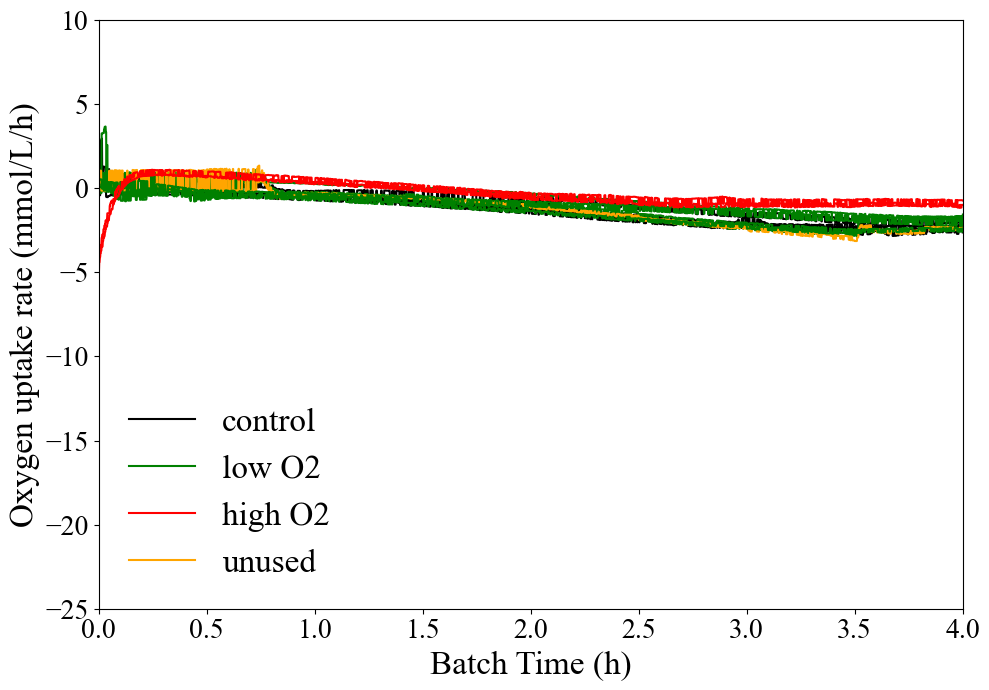

In [23]:


fig, ax = plt.subplots(figsize=(10, 7))

# dfs = [df_09_reac1,df_09_reac2,df_10_reac1,df_10_reac2,df_11]
dfs = [df_29,df_30,df_31,df_32, df_33,df_34,df_35]

colors = ['discard','blue', 'black', 'blue', 'black', 'blue','black','green','green','orange', 'green','green','red','red']  # Define colors for each dataframe

annotation = ['oscillate-discard bdcu29_1',
              'oscillate-1',
              'control-1',
              'oscillate-2', 
              'control-2',
              'oscillate-3',
              'control-3',
              'low-1',
              'low-2',
              'low-x1',
              'low-3',
              'low-xx2',
              'high-1',
              'high-2',

             ]

n=0
c=0
for i, df in enumerate(dfs):
    c=i*2
    # print('before: i',i,'c',c)
    # print(annotation[c])
    if (('Fermenter01','BDCU-1','OUR','g/h') in df.columns) and ('oscillate' not in annotation[c]):
        # Extract the columns you want to plot
        print('entered 1',i,c)
        x = df[('Fermenter01', 'BDCU-1', 'OUR', 'g/h')]*1000/(32*1.5)
        plt.plot(x, label=annotation[c], color=colors[c])
        # print(x.min(),x.iloc[200:].max())
        
        # print(min(x),annotation[c],x.idxmin(),x[x.idxmin()])
        # if (i!=1) and (colors[c+1]!='yellow'):

    if (('Fermenter02','BDCU-2','OUR','g/h') in df.columns) and ('oscillate' not in annotation[c+1]):
        # print('entered 2',i,c)

        x = df[('Fermenter02', 'BDCU-2', 'OUR', 'g/h')]*1000/(32*1.5)
        plt.plot(x, label=annotation[c+1], color=colors[c+1])
    # c+=1

ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=10)
            # print(min(x),annotation2[c],x.idxmin(),x[x.idxmin()])
plt.ylim(-25,10)
plt.xlim(0,4)


custom_labels = ['control',  'low O2', 'high O2', 'unused']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
ax.legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

#plt.title("flow rates adjusted, using max composition")
# plt.legend(bbox_to_anchor=(0.8, 1), loc='upper left',fontsize=20,frameon=False)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.xlabel('Batch Time (h)',size=24)
plt.ylabel('Oxygen uptake rate (mmol/L/h)', color='k',size=24)
plt.savefig('OMICS_OUR.png')
plt.tight_layout()
plt.show()


In [24]:
df_29_holder = df_29.copy()
df_29.drop(columns=[('Fermenter01','BDCU-1','OUR','g/h')],inplace=True)

before: i 0 c 0
5%
entered 2 0 0
before: i 1 c 1
25%
entered 1 1 1
entered 2 1 2
before: i 2 c 3
oscillate-2
entered 1 2 3
2 3 oscillate-2
entered 2 2 4
before: i 3 c 5
oscillate-3
entered 1 3 5
3 5 oscillate-3
entered 2 3 6
before: i 4 c 7
low
entered 1 4 7
entered 2 4 8
before: i 5 c 9
low-3
entered 1 5 9
entered 2 5 10
before: i 6 c 11
high-1
entered 1 6 11
entered 2 6 12


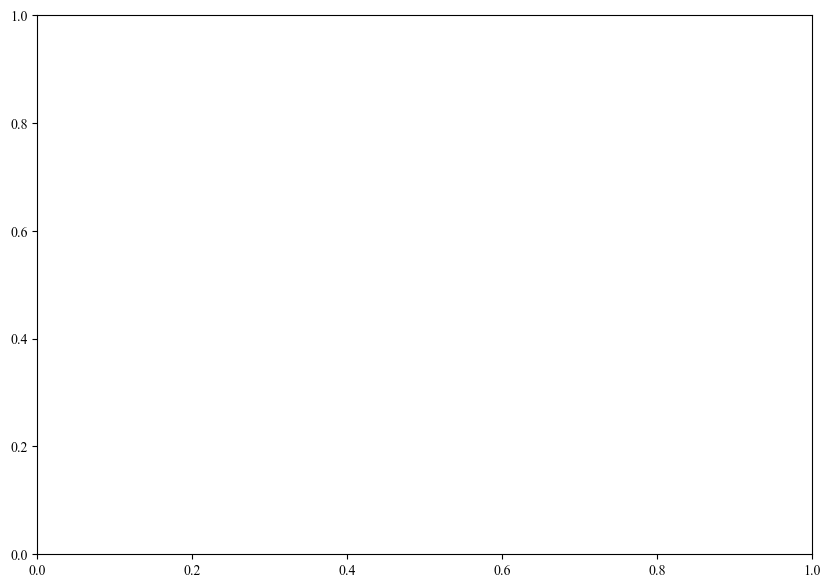

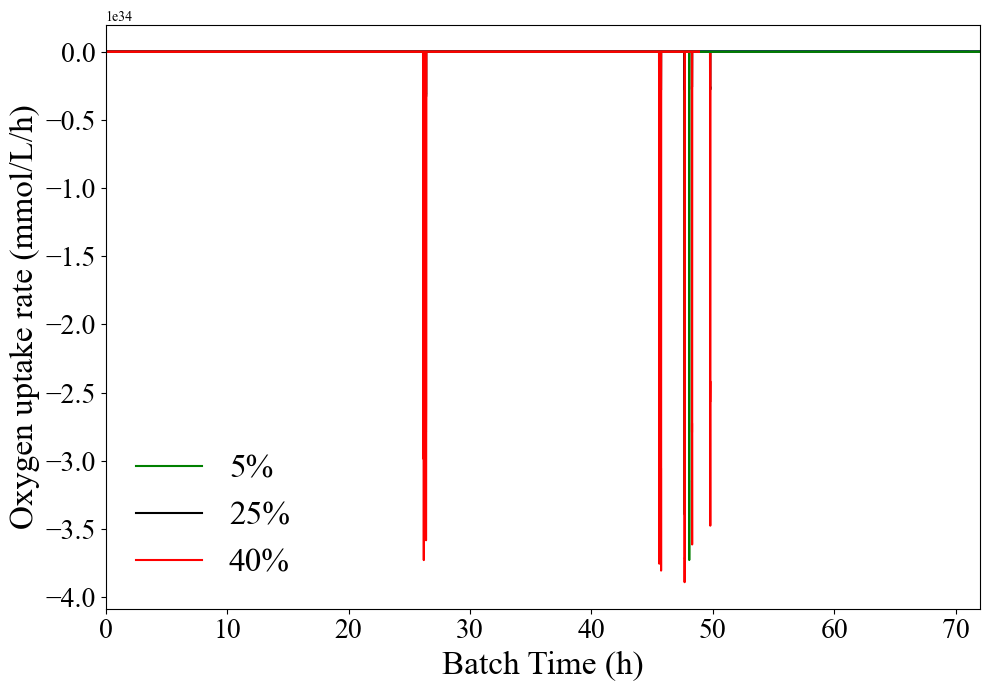

entered 1 1 2
entered 1 2 4
entered 1 4 8
entered 1 5 10
entered 1 6 12


IndexError: list index out of range

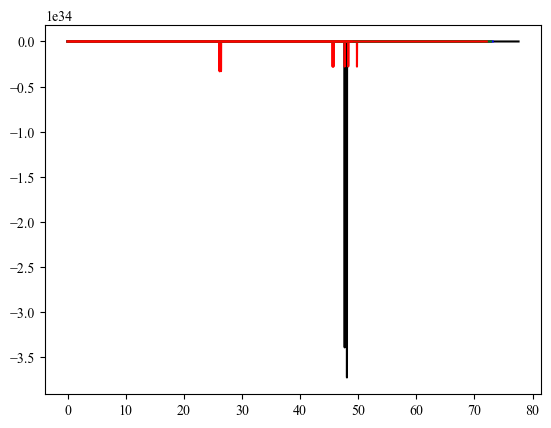

In [27]:


fig, ax = plt.subplots(figsize=(10, 7))

# dfs = [df_09_reac1,df_09_reac2,df_10_reac1,df_10_reac2,df_11]
dfs = [df_29,df_30,df_31,df_32, df_33,df_34,df_35]

colors = ['discard','blue', 'black', 'blue', 'black', 'blue','black','green','green','orange', 'green','green','red','red']  # Define colors for each dataframe

annotation = ['oscillate-discard bdcu29_1',
              'oscillate-1',
              'control-1',
              'oscillate-2', 
              'control-2',
              'oscillate-3',
              'control-3',
              'low-1',
              'discardlow-2',
              'low-x1',
              'low-3',
              'low-xx2',
              'high-1',
              'high-2',

             ]



def clean_data(series):
    # Convert infinities to NaN for easy filtering
    series.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Drop rows that are NaN or 0
    return series.dropna().loc[series != 0]




def calculate_our_offgas_oscillate(df):
    
    # constants
    R = 8.314472 # [J /mol/K]
    mw_co2 = 44 # g/mol
    mw_o2 = 32 # g/mol

    try: 
        df_po2 = pd.DataFrame({
            'age': df['temp_age_continue'],
            'yO2_out': df[('Fermenter01', 'BDCU-1', 'CH1-O2', 'Vol %')],
            'temp': df[('Fermenter01','BDCU-1','Temperature','°C')]+273.15, # in K
            'pres': df[('Fermenter01','BDCU-1','Pressure','bar')]*100 # kPa
        })
    except:
        try:
            df_po2 = pd.DataFrame({
            'age': df['temp_age_continue'],
            'yO2_out': df[('Fermenter02', 'BDCU-2', 'CH1-O2', 'Vol %')],
            'temp': df[('Fermenter02','BDCU-2','Temperature','°C')]+273.15, # in K
            'pres': df[('Fermenter02','BDCU-2','Pressure','bar')]*100 # kPa
            })
        except:
            try:
                df_po2 = pd.DataFrame({
                'age': df['temp_age_continue'],
                'yO2_out': df[('Fermenter03', 'BDCU-3', 'CH1-O2', 'Vol %')],
                'temp': df[('Fermenter03','BDCU-3','Temperature','°C')]+273.15, # in K
                'pres': df[('Fermenter03','BDCU-3','Pressure','bar')]*100 # kPa
                })
            except:
                print('failed to find data')
    df_po2['yO2_change'] = 20.95 - df_po2['yO2_out']
    df_po2['O2change'] = df_po2['yO2_change']/100*1.125*df_po2['pres']*mw_o2/(R*df_po2['temp'])
    df_po2['OUR (mmol/Lh)']= df_po2['O2change']*1000/(32*1.5)*-1

    return(df_po2)



fig, ax = plt.subplots(figsize=(10, 7))

# dfs = [df_09_reac1,df_09_reac2,df_10_reac1,df_10_reac2,df_11]
# dfs = [df_41,df_42,df_43]
# dfs = [df_41]
# 
colors = ['green',
          'black', 
          'red', 
          'blue', 
          'black', 
          'blue',
          'orange',
          'blue',
          'purple',
          # 'orange', 
          'green','green','red','red']  # Define colors for each dataframe

annotation = ['5%',
              '25%',
              '40%',
              'oscillate-2', 
              '25%',
              'oscillate-3',
              # 'DMR',
              'oscillate-2',
              'low',
              
              'low-x1',
              'low-3',
              'low-xx2',
              'high-1',
              'high-2',

             ]

n=0
c=0
for i, df in enumerate(dfs):

    print('before: i',i,'c',c)
    print(annotation[c])

    if ('Fermenter01','BDCU-1','OUR','g/h') in df.columns:
        # Extract the columns you want to plot
        print('entered 1',i,c)

        x = df[('Fermenter01', 'BDCU-1', 'OUR', 'g/h')]*1000/(32*1.5)
        # plt.plot(x, label='5%', color='green')
        # print(x.min(),x.iloc[200:].max())
        
        # print(min(x),annotation[c],x.idxmin(),x[x.idxmin()])
        # if (i!=1) and (colors[c+1]!='yellow'):


        

        if 'oscillate' in annotation[c]:
            print(i,c,annotation[c])

            df_offgas = calculate_our_offgas_oscillate(df)
            
            valid_rows = df[('Fermenter01', 'BDCU-1', 'F_in1', 'LPM')] > 0.375
            # x = x.loc[valid_rows]  # Only select rows where F_in2 is not zero        
        
            # x = clean_data(x)  # Apply cleaning function
            x = df_offgas['OUR (mmol/Lh)']
            plt.plot(x, label=annotation[c], color=colors[c])

        if not 'oscillate' in annotation[c]:
            plt.plot(x, label=annotation[c], color=colors[c])
        c+=1

    
    if ('Fermenter02','BDCU-2','OUR','g/h') in df.columns:
        print('entered 2',i,c)
        
        x = df[('Fermenter02', 'BDCU-2', 'OUR', 'g/h')]*1000/(32*1.5)


        if 'oscillate' in annotation[c]:
        
            valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] >0.375
            x = x.loc[valid_rows]  # Only select rows where F_in2 is not zero        
        
            x = clean_data(x)  # Apply cleaning function
            plt.plot(x, label=annotation[c], color=colors[c])

        if not 'oscillate' in annotation[c]:
            plt.plot(x, label=annotation[c], color=colors[c])
        
        c+=1

        
    if ('Fermenter03','BDCU-3','OUR','g/h') in df.columns:
        print('entered 3',i,c)

        x = df[('Fermenter03', 'BDCU-3', 'OUR', 'g/h')]*1000/(32*1.5)


        if 'oscillate' in annotation[c]:
            df_offgas = calculate_our_offgas_oscillate(df)
            
            valid_rows = df[('Fermenter03', 'BDCU-3', 'F_in3', 'LPM')] > 0.375
            # x = x.loc[valid_rows]  # Only select rows where F_in2 is not zero        
        
            # x = clean_data(x)  # Apply cleaning function
            x = df_offgas['OUR (mmol/Lh)']
            plt.plot(x, label=annotation[c], color=colors[c])

        if not 'oscillate' in annotation[c]:
            plt.plot(x, label=annotation[c], color=colors[c])
        c+=1
    # c+=1

ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=10)
            # print(min(x),annotation2[c],x.idxmin(),x[x.idxmin()])
# plt.ylim(,10)
plt.xlim(0,72)




custom_labels = ['5%',  '25%', '40%',]# 'unused']
custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
ax.legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

#plt.title("flow rates adjusted, using max composition")
# plt.legend(bbox_to_anchor=(0.8, 1), loc='upper left',fontsize=20,frameon=False)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.xlabel('Batch Time (h)',size=24)
plt.ylabel('Oxygen uptake rate (mmol/L/h)', color='k',size=24)
plt.savefig('lte_OUR.png')
plt.tight_layout()
plt.show()




n=0
c=0
for i, df in enumerate(dfs):
    c=i*2
    # print('before: i',i,'c',c)
    # print(annotation[c])
    if (('Fermenter01','BDCU-1','OUR','g/h') in df.columns) and ('oscillate' not in annotation[c]) and ('discard' not in annotation[c]):
        # Extract the columns you want to plot
        print('entered 1',i,c)
        x = df[('Fermenter01', 'BDCU-1', 'OUR', 'g/h')]*1000/(32*1.5)
        plt.plot(x, label=annotation[c], color=colors[c])
        # print(x.min(),x.iloc[200:].max())
        
        # print(min(x),annotation[c],x.idxmin(),x[x.idxmin()])
        # if (i!=1) and (colors[c+1]!='yellow'):

    if (('Fermenter02','BDCU-2','OUR','g/h') in df.columns) and ('oscillate' not in annotation[c+1])and ('discard' not in annotation[c]):
        # print('entered 2',i,c)

        x = df[('Fermenter02', 'BDCU-2', 'OUR', 'g/h')]*1000/(32*1.5)
        plt.plot(x, label=annotation[c+1], color=colors[c+1])
    # c+=1

ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=10)
            # print(min(x),annotation2[c],x.idxmin(),x[x.idxmin()])
plt.ylim(-25,0)
plt.xlim(0,100)


custom_labels = ['control',  'low O2', 'high O2', 'unused']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
ax.legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

#plt.title("flow rates adjusted, using max composition")
# plt.legend(bbox_to_anchor=(0.8, 1), loc='upper left',fontsize=20,frameon=False)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.xlabel('Batch Time (h)',size=24)
plt.ylabel('Oxygen uptake rate (mmol/L/h)', color='k',size=24)
plt.savefig('OMICS_OUR.png')
plt.tight_layout()
plt.show()


# delete to here

before: i 0 c 0
oscillate-1
entered 2 0 0
before: i 1 c 1
control-1
entered 1 1 1
entered 2 1 2
before: i 2 c 3
control-2
entered 1 2 3
entered 2 2 4
before: i 3 c 5
control-3
entered 1 3 5
entered 2 3 6
before: i 4 c 7
discardlow-2
entered 1 4 7
entered 2 4 8
before: i 5 c 9
low-3
entered 1 5 9
entered 2 5 10
before: i 6 c 11
high-1
entered 1 6 11
entered 2 6 12


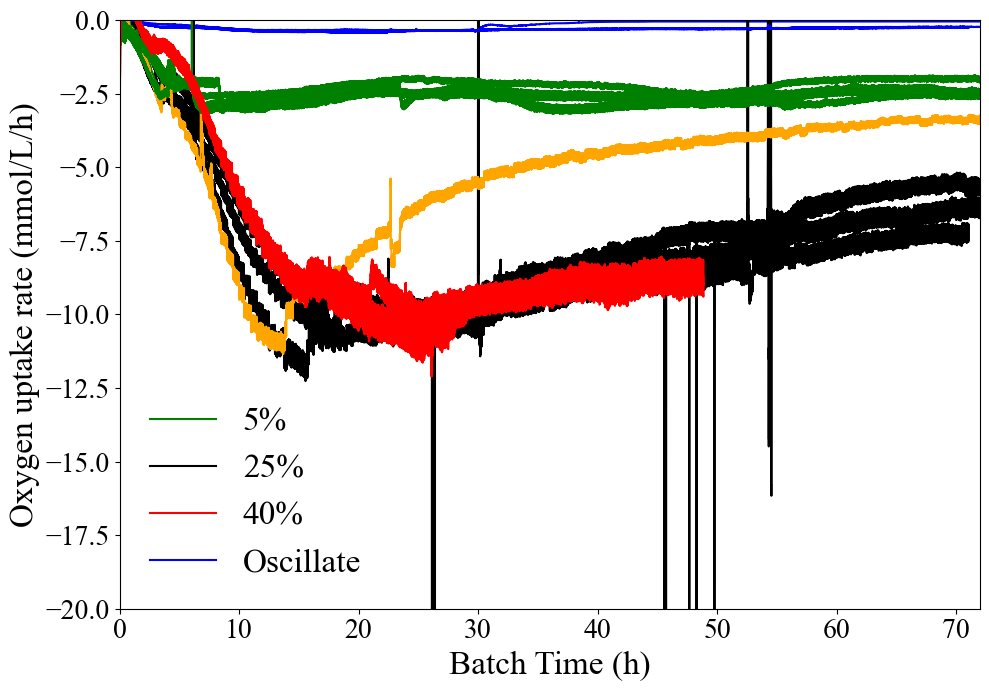

In [28]:


# dfs = [df_09_reac1,df_09_reac2,df_10_reac1,df_10_reac2,df_11]
dfs = [df_29,df_30,df_31,df_32, df_33,df_34,df_35]

colors = ['blue', 'black', 'blue', 'black', 'blue','black','green','green','orange', 'green','green','red','red']  # Define colors for each dataframe

annotation = [
              'oscillate-1',
              'control-1',
              'oscillate-2', 
              'control-2',
              'oscillate-3',
              'control-3',
              'low-1',
              'discardlow-2',
              'low-x1',
              'low-3',
              'low-xx2',
              'high-1',
              'high-2',

             ]



def clean_data(series):
    # Convert infinities to NaN for easy filtering
    series.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Drop rows that are NaN or 0
    return series.dropna().loc[series != 0]




def calculate_our_offgas_oscillate(df):
    
    # constants
    R = 8.314472 # [J /mol/K]
    mw_co2 = 44 # g/mol
    mw_o2 = 32 # g/mol

    try: 
        df_po2 = pd.DataFrame({
            'age': df['temp_age_continue'],
            'yO2_out': df[('Fermenter01', 'BDCU-1', 'CH1-O2', 'Vol %')],
            'temp': df[('Fermenter01','BDCU-1','Temperature','°C')]+273.15, # in K
            'pres': df[('Fermenter01','BDCU-1','Pressure','bar')]*100 # kPa
        })
    except:
        try:
            df_po2 = pd.DataFrame({
            'age': df['temp_age_continue'],
            'yO2_out': df[('Fermenter02', 'BDCU-2', 'CH1-O2', 'Vol %')],
            'temp': df[('Fermenter02','BDCU-2','Temperature','°C')]+273.15, # in K
            'pres': df[('Fermenter02','BDCU-2','Pressure','bar')]*100 # kPa
            })
        except:
            try:
                df_po2 = pd.DataFrame({
                'age': df['temp_age_continue'],
                'yO2_out': df[('Fermenter03', 'BDCU-3', 'CH1-O2', 'Vol %')],
                'temp': df[('Fermenter03','BDCU-3','Temperature','°C')]+273.15, # in K
                'pres': df[('Fermenter03','BDCU-3','Pressure','bar')]*100 # kPa
                })
            except:
                print('failed to find data')
    df_po2['yO2_change'] = 20.95 - df_po2['yO2_out']
    df_po2['O2change'] = df_po2['yO2_change']/100*1.125*df_po2['pres']*mw_o2/(R*df_po2['temp'])
    df_po2['OUR (mmol/Lh)']= df_po2['O2change']*1000/(32*1.5)*-1

    return(df_po2)



fig, ax = plt.subplots(figsize=(10, 7))

# dfs = [df_09_reac1,df_09_reac2,df_10_reac1,df_10_reac2,df_11]
# dfs = [df_41]
# 
n=0
c=0
for i, df in enumerate(dfs):

    print('before: i',i,'c',c)
    print(annotation[c])

    if ('Fermenter01','BDCU-1','OUR','g/h') in df.columns:
        # Extract the columns you want to plot
        print('entered 1',i,c)

        x = df[('Fermenter01', 'BDCU-1', 'OUR', 'g/h')]*1000/(32*1.5)
        # plt.plot(x, label='5%', color='green')
        # print(x.min(),x.iloc[200:].max())
        
        # print(min(x),annotation[c],x.idxmin(),x[x.idxmin()])
        # if (i!=1) and (colors[c+1]!='yellow'):


        

        if 'oscillate' in annotation[c]:
            print(i,c,annotation[c])

            df_offgas = calculate_our_offgas_oscillate(df)
            
            valid_rows = df[('Fermenter01', 'BDCU-1', 'F_in1', 'LPM')] > 0.375
            # x = x.loc[valid_rows]  # Only select rows where F_in2 is not zero        
        
            # x = clean_data(x)  # Apply cleaning function
            x = df_offgas['OUR (mmol/Lh)']
            plt.plot(x, label=annotation[c], color=colors[c])

        if not 'oscillate' in annotation[c]:
            plt.plot(x, label=annotation[c], color=colors[c])
        c+=1

    
    if ('Fermenter02','BDCU-2','OUR','g/h') in df.columns:
        print('entered 2',i,c)
        
        x = df[('Fermenter02', 'BDCU-2', 'OUR', 'g/h')]*1000/(32*1.5)


        if 'oscillate' in annotation[c]:

            df_offgas = calculate_our_offgas_oscillate(df)

            valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] >0.375
            x = x.loc[valid_rows]  # Only select rows where F_in2 is not zero        
        
            x = clean_data(x)  # Apply cleaning function

            x = df_offgas['OUR (mmol/Lh)']

            plt.plot(x, label=annotation[c], color=colors[c])

        if not 'oscillate' in annotation[c]:
            plt.plot(x, label=annotation[c], color=colors[c])
        
        c+=1

        
    if ('Fermenter03','BDCU-3','OUR','g/h') in df.columns:
        print('entered 3',i,c)

        x = df[('Fermenter03', 'BDCU-3', 'OUR', 'g/h')]*1000/(32*1.5)


        if 'oscillate' in annotation[c]:
            df_offgas = calculate_our_offgas_oscillate(df)
            
            valid_rows = df[('Fermenter03', 'BDCU-3', 'F_in3', 'LPM')] > 0.375
            # x = x.loc[valid_rows]  # Only select rows where F_in2 is not zero        
        
            # x = clean_data(x)  # Apply cleaning function
            x = df_offgas['OUR (mmol/Lh)']
            plt.plot(x, label=annotation[c], color=colors[c])

        if not 'oscillate' in annotation[c]:
            plt.plot(x, label=annotation[c], color=colors[c])
        c+=1
    # c+=1

ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=10)
            # print(min(x),annotation2[c],x.idxmin(),x[x.idxmin()])
plt.ylim(-20,0)
plt.xlim(0,72)




custom_labels = ['5%',  '25%', '40%','Oscillate']# 'unused']
custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
ax.legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

#plt.title("flow rates adjusted, using max composition")
# plt.legend(bbox_to_anchor=(0.8, 1), loc='upper left',fontsize=20,frameon=False)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.xlabel('Batch Time (h)',size=24)
plt.ylabel('Oxygen uptake rate (mmol/L/h)', color='k',size=24)
plt.savefig('lte_OUR.png')
plt.tight_layout()
plt.show()



entered 1 1 2
entered 1 2 4
entered 1 3 6
entered 1 4 8
entered 1 5 10
entered 1 6 12


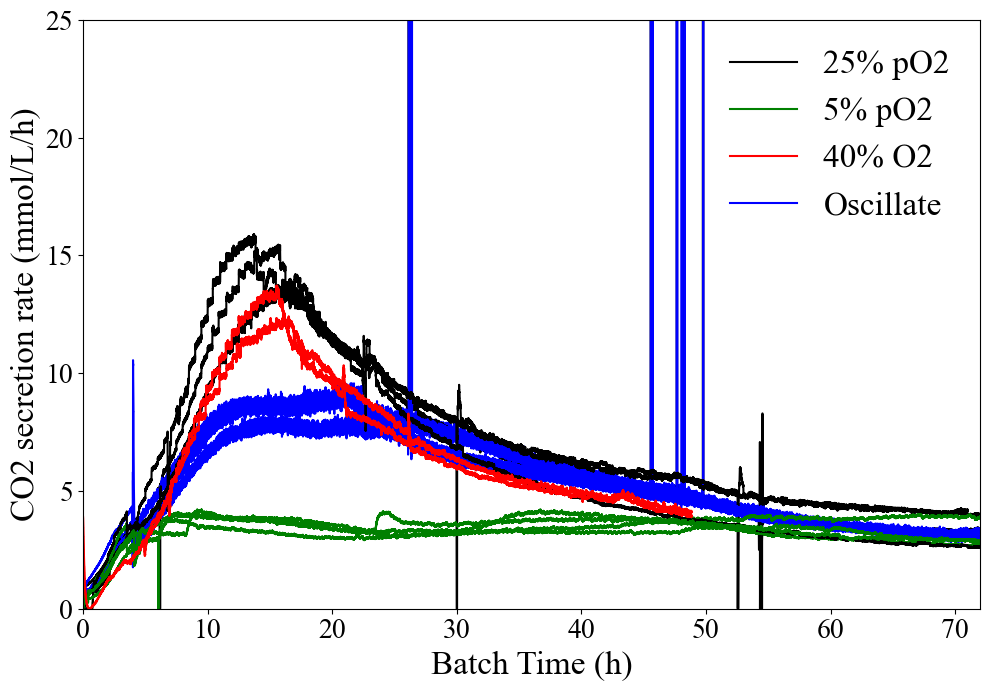

In [30]:

def clean_data(series):
    # Convert infinities to NaN for easy filtering
    series.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Drop rows that are NaN or 0
    return series.dropna().loc[series != 0]

fig, ax = plt.subplots(figsize=(10, 7))

# dfs = [df_09_reac1,df_09_reac2,df_10_reac1,df_10_reac2,df_11]
dfs = [df_29,df_30,df_31,df_32, df_33,df_34,df_35]
# dfs = [df_29,df_30,df_31,df_32, df_33,df_34,df_35]

colors = ['discard','blue', 'black', 'blue', 'black', 'blue','black','green','green','black', 'green','green','red','red']  # Define colors for each dataframe

annotation = ['discard bdcu29_1',
              'oscillate-1',
              'control-1',
              'oscillate-2', 
              'control-2',
              'oscillate-3',
              'control-3',
              'low-1',
              'low-2',
              'low-x1',
              'low-3',
              'low-xx2',
              'high-1',
              'high-2',

             ]

n=0
c=0
for i, df in enumerate(dfs):
    c=i*2
    # print('before: i',i,'c',c)
    # print(annotation[c])
    if (('Fermenter01','BDCU-1','CER','g/h') in df.columns) and ('discard' not in annotation[c]):
        # Extract the columns you want to plot
        print('entered 1',i,c)
        x = df[('Fermenter01', 'BDCU-1', 'CER', 'g/h')]*1000/(44*1.5)

        valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] != 0
        x = x.loc[valid_rows]  # Only select rows where F_in2 is not zero        
        
        if 'oscillate' in annotation[c]:
            x = clean_data(x)  # Apply cleaning function

        plt.plot(x, label=annotation[c], color=colors[c])
        # print(x.min(),x.iloc[200:].max())
        
        # print(min(x),annotation[c],x.idxmin(),x[x.idxmin()])
        # if (i!=1) and (colors[c+1]!='yellow'):

    if (('Fermenter02','BDCU-2','CER','g/h') in df.columns) and ('discard' not in annotation[c+1]):
        # print('entered 2',i,c)

        x = df[('Fermenter02', 'BDCU-2', 'CER', 'g/h')]*1000/(44*1.5)
        if 'oscillate' in annotation[c+1]:
            # Drop rows where F_in2 is zero
            valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] >= .375
            x = x.loc[valid_rows]  # Only select rows where F_in2 is not zero        
        

            x = clean_data(x)  # Apply cleaning function
            
        plt.plot(x, label=annotation[c+1], color=colors[c+1])
    # c+=1

ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=10)
            # print(min(x),annotation2[c],x.idxmin(),x[x.idxmin()])
plt.ylim(0,25)
plt.xlim(0,72)


custom_labels = ['25% pO2',  '5% pO2', '40% O2', 'Oscillate']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
ax.legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

#plt.title("flow rates adjusted, using max composition")
# plt.legend(bbox_to_anchor=(0.8, 1), loc='upper left',fontsize=20,frameon=False)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.xlabel('Batch Time (h)',size=24)
plt.ylabel('CO2 secretion rate (mmol/L/h)', color='k',size=24)
plt.savefig('OMICS_CER.png')
plt.tight_layout()
plt.show()


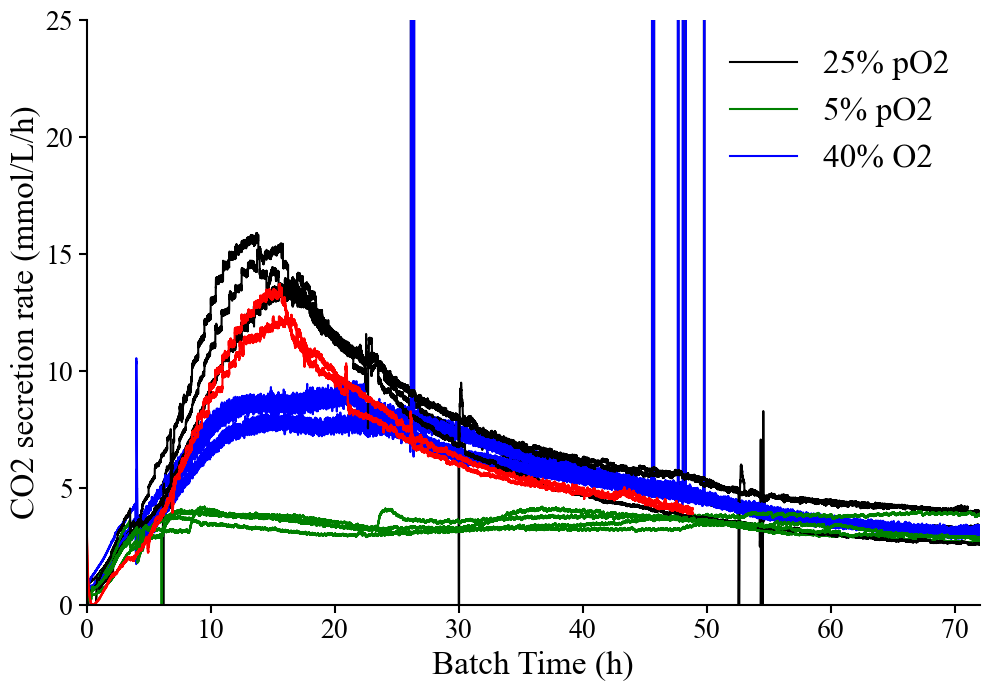

In [111]:
def clean_data(series):
    # Convert infinities to NaN for easy filtering
    series.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Drop rows that are NaN or 0
    return series.dropna().loc[series != 0]

# --- Global publication-quality settings ---
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['pdf.fonttype'] = 42   # editable text in vector PDF
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

fig, ax = plt.subplots(figsize=(10, 7))

dfs = [df_29, df_30, df_31, df_32, df_33, df_34, df_35]
colors = ['discard','blue', 'black', 'blue', 'black', 'blue','black','green','green','black', 'green','green','red','red']
annotation = ['discard bdcu29_1',
              'oscillate-1',
              'control-1',
              'oscillate-2', 
              'control-2',
              'oscillate-3',
              'control-3',
              'low-1',
              'low-2',
              'low-x1',
              'low-3',
              'low-xx2',
              'high-1',
              'high-2',
             ]
n = 0
c = 0
for i, df in enumerate(dfs):
    c = i * 2
    if (('Fermenter01','BDCU-1','CER','g/h') in df.columns) and ('discard' not in annotation[c]):
        x = df[('Fermenter01', 'BDCU-1', 'CER', 'g/h')]*1000/(44*1.5)
        valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] != 0
        x = x.loc[valid_rows]

        if 'oscillate' in annotation[c]:
            x = clean_data(x)
        ax.plot(x, label=annotation[c], color=colors[c])

    if (('Fermenter02','BDCU-2','CER','g/h') in df.columns) and ('discard' not in annotation[c+1]):
        x = df[('Fermenter02', 'BDCU-2', 'CER', 'g/h')]*1000/(44*1.5)
        if 'oscillate' in annotation[c+1]:
            valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] >= .375
            x = x.loc[valid_rows]
            x = clean_data(x)
        ax.plot(x, label=annotation[c+1], color=colors[c+1])

ax.tick_params(axis='both', which='major', labelsize=20, width=1.5, length=6)
ax.tick_params(axis='both', which='minor', labelsize=10)

ax.set_ylim(0, 25)
ax.set_xlim(0, 72)

custom_labels = ['25% pO2', '5% pO2', '40% O2', 'Oscillate']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    # plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]
ax.legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

ax.set_xlabel('Batch Time (h)', size=24)
ax.set_ylabel('CO2 secretion rate (mmol/L/h)', color='k', size=24)

# --- Remove top/right spines, thicken remaining ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()

# --- High-quality save ---
plt.savefig('OMICS_CER_40.png', dpi=600, bbox_inches='tight')
plt.savefig('OMICS_CER_40.pdf', bbox_inches='tight')
plt.savefig('OMICS_CER_40.svg', bbox_inches='tight')

plt.show()

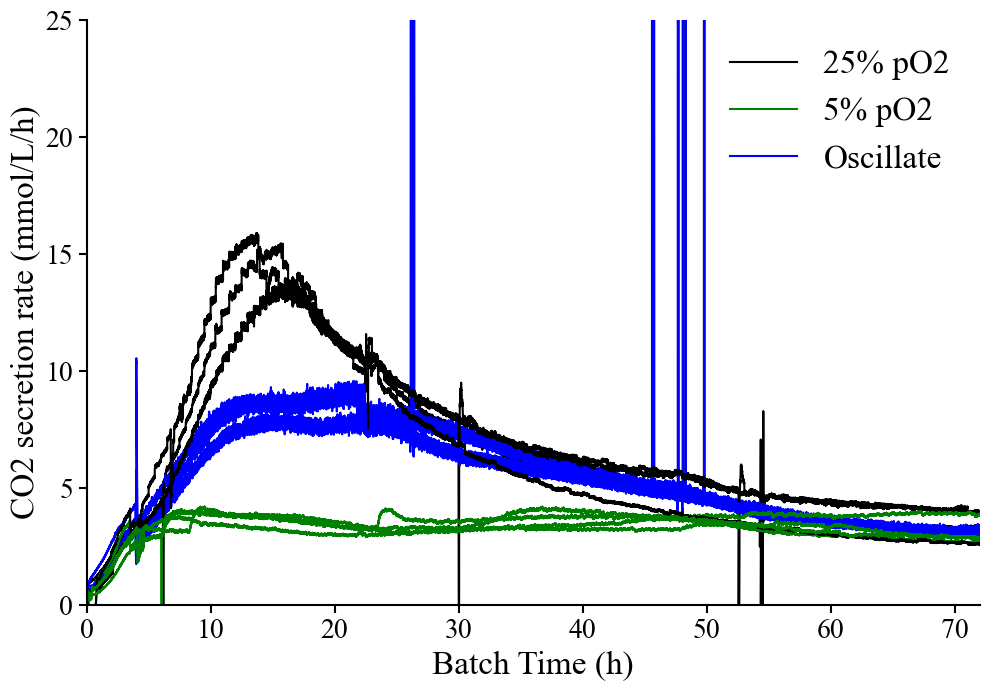

In [110]:
def clean_data(series):
    # Convert infinities to NaN for easy filtering
    series.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Drop rows that are NaN or 0
    return series.dropna().loc[series != 0]

# --- Global publication-quality settings ---
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['pdf.fonttype'] = 42   # editable text in vector PDF
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

fig, ax = plt.subplots(figsize=(10, 7))

dfs = [df_29, df_30, df_31, df_32, df_33, df_34]  # df_35 (40% O2 / red) removed
colors = ['discard','blue', 'black', 'blue', 'black', 'blue','black','green','green','black', 'green','green']
annotation = ['discard bdcu29_1',
              'oscillate-1',
              'control-1',
              'oscillate-2', 
              'control-2',
              'oscillate-3',
              'control-3',
              'low-1',
              'low-2',
              'low-x1',
              'low-3',
              'low-xx2',
             ]
n = 0
c = 0
for i, df in enumerate(dfs):
    c = i * 2
    if (('Fermenter01','BDCU-1','CER','g/h') in df.columns) and ('discard' not in annotation[c]):
        x = df[('Fermenter01', 'BDCU-1', 'CER', 'g/h')]*1000/(44*1.5)
        valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] != 0
        x = x.loc[valid_rows]

        if 'oscillate' in annotation[c]:
            x = clean_data(x)
        ax.plot(x, label=annotation[c], color=colors[c])

    if (('Fermenter02','BDCU-2','CER','g/h') in df.columns) and ('discard' not in annotation[c+1]):
        x = df[('Fermenter02', 'BDCU-2', 'CER', 'g/h')]*1000/(44*1.5)
        if 'oscillate' in annotation[c+1]:
            valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] >= .375
            x = x.loc[valid_rows]
            x = clean_data(x)
        ax.plot(x, label=annotation[c+1], color=colors[c+1])

ax.tick_params(axis='both', which='major', labelsize=20, width=1.5, length=6)
ax.tick_params(axis='both', which='minor', labelsize=10)

ax.set_ylim(0, 25)
ax.set_xlim(0, 72)

custom_labels = ['25% pO2', '5% pO2', 'Oscillate']  # '40% O2' removed
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]
ax.legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

ax.set_xlabel('Batch Time (h)', size=24)
ax.set_ylabel('CO2 secretion rate (mmol/L/h)', color='k', size=24)

# --- Remove top/right spines, thicken remaining ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()

# --- High-quality save ---
plt.savefig('OMICS_CER.png', dpi=600, bbox_inches='tight')
plt.savefig('OMICS_CER.pdf', bbox_inches='tight')
plt.savefig('OMICS_CER.svg', bbox_inches='tight')

entered 1 1 2
entered 1 2 4
entered 1 3 6
entered 1 4 8
entered 1 5 10
entered 1 6 12


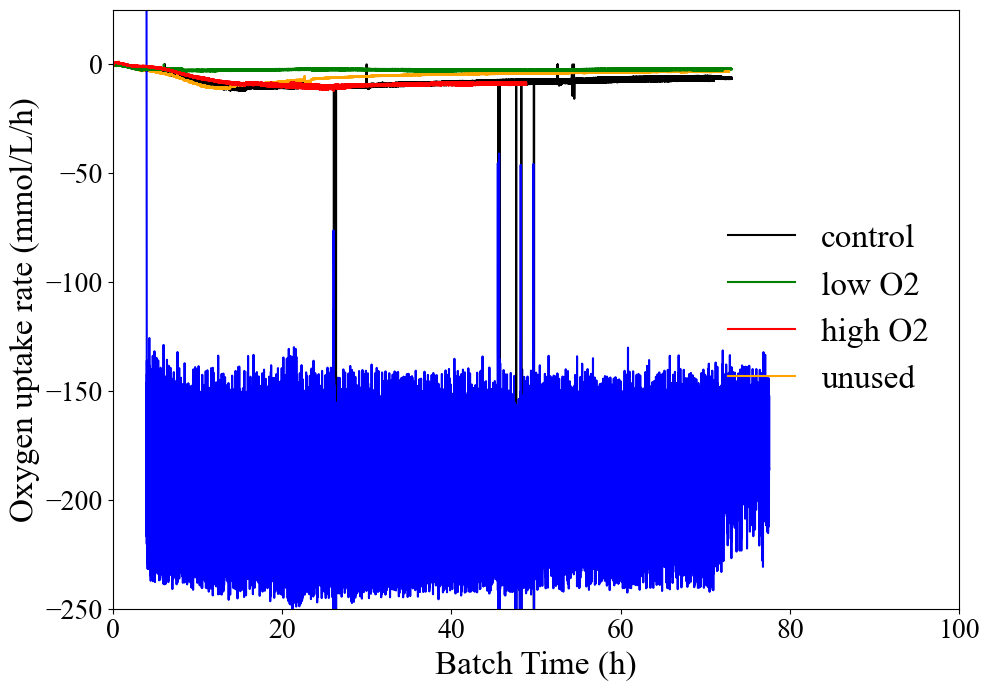

In [31]:

def clean_data_df(series):
    # Convert infinities to NaN for easy filtering
    series.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Drop rows that are NaN or 0
    return series.dropna().loc[series != 0]

fig, ax = plt.subplots(figsize=(10, 7))

# dfs = [df_09_reac1,df_09_reac2,df_10_reac1,df_10_reac2,df_11]
dfs = [df_29,df_30,df_31,df_32, df_33,df_34,df_35]
# dfs = [df_29,df_30,df_31,df_32, df_33,df_34,df_35]

colors = ['discard','blue', 'black', 'blue', 'black', 'blue','black','green','green','orange', 'green','green','red','red']  # Define colors for each dataframe

annotation = ['discard bdcu29_1',
              'oscillate-1',
              'control-1',
              'oscillate-2', 
              'control-2',
              'oscillate-3',
              'control-3',
              'low-1',
              'low-2',
              'low-x1',
              'low-3',
              'low-xx2',
              'high-1',
              'high-2',

             ]

n=0
c=0
for i, df in enumerate(dfs):
    c=i*2
    # print('before: i',i,'c',c)
    # print(annotation[c])
    if (('Fermenter01','BDCU-1','OUR','g/h') in df.columns) and ('discard' not in annotation[c]):
        # Extract the columns you want to plot
        print('entered 1',i,c)
        x = df[('Fermenter01', 'BDCU-1', 'OUR', 'g/h')]*1000/(32*1.5)

        valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] != 0
        x = x.loc[valid_rows]  # Only select rows where F_in2 is not zero        
        
        if 'oscillate' in annotation[c]:
            x = clean_data(x)  # Apply cleaning function

        plt.plot(x, label=annotation[c], color=colors[c])
        # print(x.min(),x.iloc[200:].max())
        
        # print(min(x),annotation[c],x.idxmin(),x[x.idxmin()])
        # if (i!=1) and (colors[c+1]!='yellow'):

    if (('Fermenter02','BDCU-2','OUR','g/h') in df.columns) and ('discard' not in annotation[c+1]):
        # print('entered 2',i,c)

        x = df[('Fermenter02', 'BDCU-2', 'OUR', 'g/h')]*1000/(32*1.5)
        if 'oscillate' in annotation[c+1]:
            # Drop rows where F_in2 is zero
            valid_rows = df[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] > 1
            x = x.loc[valid_rows]  # Only select rows where F_in2 is not zero        
        

            x = clean_data(x)  # Apply cleaning function
            
        plt.plot(x, label=annotation[c+1], color=colors[c+1])
    # c+=1

ax.tick_params(axis='both', which='major', labelsize=20)
ax.tick_params(axis='both', which='minor', labelsize=10)
            # print(min(x),annotation2[c],x.idxmin(),x[x.idxmin()])
plt.ylim(-250,25)
plt.xlim(0,100)


custom_labels = ['control',  'low O2', 'high O2', 'unused']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
ax.legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

#plt.title("flow rates adjusted, using max composition")
# plt.legend(bbox_to_anchor=(0.8, 1), loc='upper left',fontsize=20,frameon=False)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.xlabel('Batch Time (h)',size=24)
plt.ylabel('Oxygen uptake rate (mmol/L/h)', color='k',size=24)
# plt.savefig('OMICS_OUR.png')
plt.tight_layout()
plt.show()


#### plot oscillating OUR.

# Product Plots to data. 

plot FAME DCW, citrate (add morphology later), to glucose and O2/CER/Incyte. 

### Biostat 22-27; all phenotypes

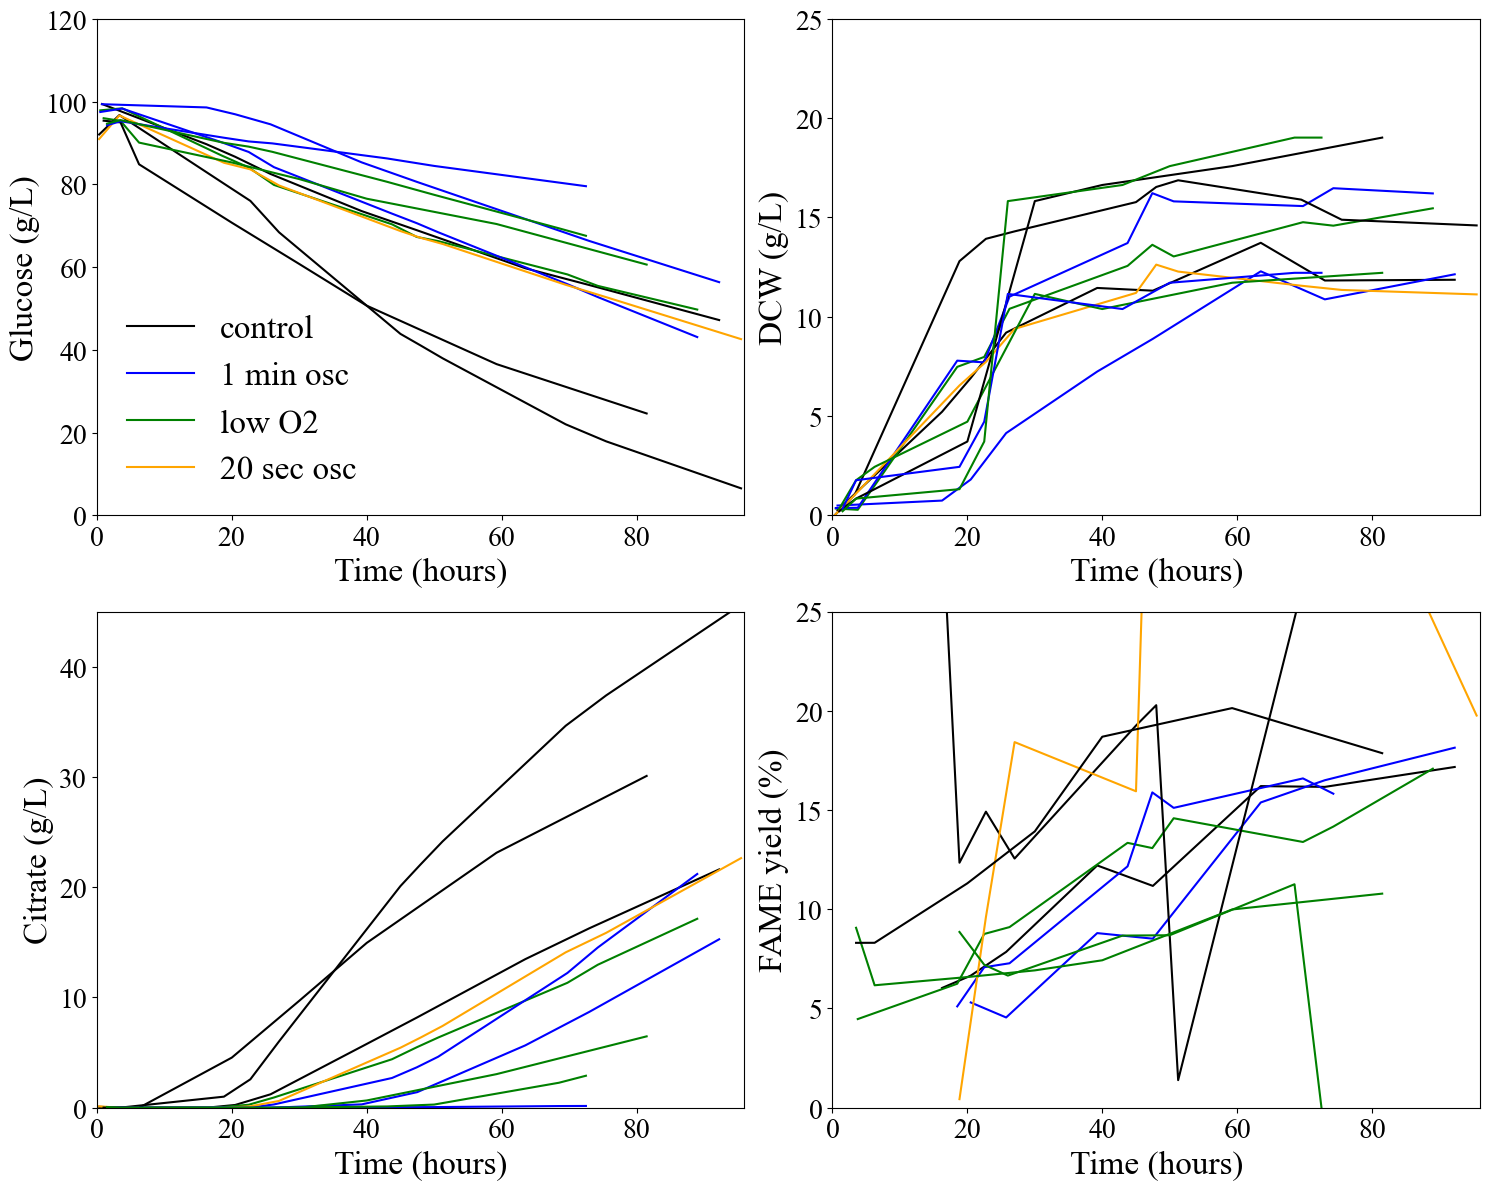

In [42]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Define the datasets and their labels and plotting styles
storages = [
    (Biostat_22_r1, 'Control (25% pO2)', 'black', '-'), # control
    (Biostat_22_r2, '1 min osc - Biostat_22_r2', 'blue', '-'), # oscillating
    (Biostat_23_r1, 'low O2', 'green', '-'),  # pO2 5%   
    (Biostat_23_r2, '1 min osc - Biostat_23_r2', 'blue', '-'), # oscillating
    (Biostat_24_r1, 'Control', 'black', '-'), # control
    (Biostat_24_r2, '20 sec osc', 'orange', '-'), # 20 sec oscillating
    (Biostat_26_r1, 'low O2', 'green', '-'), # pO2 5% 
    (Biostat_26_r2, 'Control', 'black', '-'), # control
    (Biostat_27_r1, '1 min osc', 'blue', '-'), # oscillating
    (Biostat_27_r2, 'low O2', 'green', '-'),  # pO2 5% 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)



# Define the datasets and their labels and plotting styles
storages = [
    (Biostat_22_r1, 'Control (25% pO2)', 'black', '-'), # control
    (Biostat_22_r2, '1 min osc - Biostat_22_r2', 'blue', '-'), # oscillating
    (Biostat_23_r1, 'low O2', 'green', '-'),  # pO2 5%   
    (Biostat_23_r2, '1 min osc - Biostat_23_r2', 'blue', '-'), # oscillating
    (Biostat_24_r1, 'Control', 'black', '-'), # control
    (Biostat_24_r2, '20 sec osc', 'orange', '-'), # 20 sec oscillating
    (Biostat_26_r1, 'low O2', 'green', '-'), # pO2 5% 
    (Biostat_26_r2, 'Control', 'black', '-'), # control
    # (Biostat_27_r1, '1 min osc', 'blue', '-'), # oscillating
    (Biostat_27_r2, 'low O2', 'green', '-'),  # pO2 5% 
]
# Add the FAME yield data to the last subplot
idx_fame = 3  # this is the index for the last subplot
for store, label, color, linestyle in storages:
    if fame_yield_col in store:
        # axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
        if "Biostat_23_r2" in label:
            axs[idx_fame].plot(store['hour'][:-1], store[fame_yield_col][:-1] * 100, label=label, color=color, linestyle=linestyle)
        elif "Biostat_22_r2" in label:
            axs[idx_fame].plot(store['hour'].iloc[2:], store[fame_yield_col].iloc[2:] * 100, label=label, color=color, linestyle=linestyle)
        else:
            axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
axs[idx_fame].set_xlim(0, 96)
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['control', '1 min osc', 'low O2', '20 sec osc']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
# plt.savefig('Biostat_phenotypeComparison_2x2_dropped.png')
plt.show()


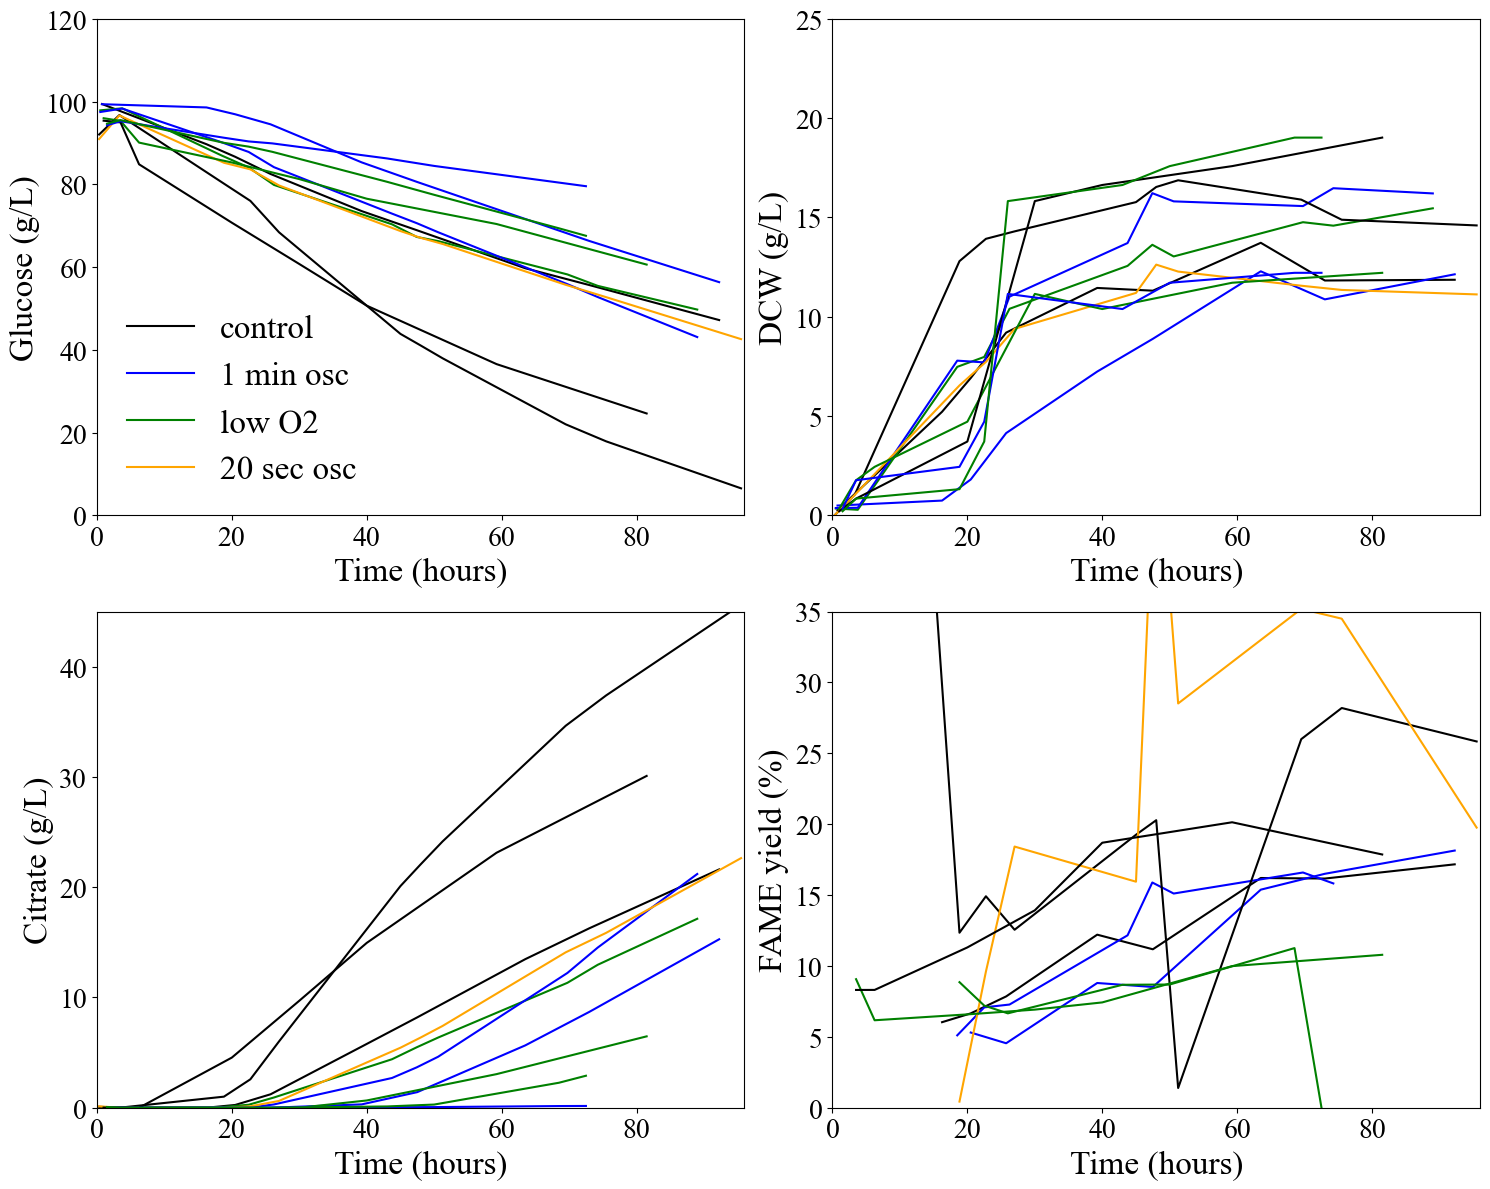

In [40]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Define the datasets and their labels and plotting styles
storages = [
    (Biostat_22_r1, 'Control (25% pO2)', 'black', '-'), # control
    (Biostat_22_r2, '1 min osc - Biostat_22_r2', 'blue', '-'), # oscillating
    (Biostat_23_r1, 'low O2', 'green', '-'),  # pO2 5%   
    (Biostat_23_r2, '1 min osc - Biostat_23_r2', 'blue', '-'), # oscillating
    (Biostat_24_r1, 'Control', 'black', '-'), # control
    (Biostat_24_r2, '20 sec osc', 'orange', '-'), # 20 sec oscillating
    (Biostat_26_r1, 'low O2', 'green', '-'), # pO2 5% 
    (Biostat_26_r2, 'Control', 'black', '-'), # control
    (Biostat_27_r1, '1 min osc', 'blue', '-'), # oscillating
    (Biostat_27_r2, 'low O2', 'green', '-'),  # pO2 5% 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)



# Define the datasets and their labels and plotting styles
storages = [
    (Biostat_22_r1, 'Control (25% pO2)', 'black', '-'), # control
    (Biostat_22_r2, '1 min osc - Biostat_22_r2', 'blue', '-'), # oscillating
    # (Biostat_23_r1, 'low O2', 'green', '-'),  # pO2 5%   
    (Biostat_23_r2, '1 min osc - Biostat_23_r2', 'blue', '-'), # oscillating
    (Biostat_24_r1, 'Control', 'black', '-'), # control
    (Biostat_24_r2, '20 sec osc', 'orange', '-'), # 20 sec oscillating
    (Biostat_26_r1, 'low O2', 'green', '-'), # pO2 5% 
    (Biostat_26_r2, 'Control', 'black', '-'), # control
    # (Biostat_27_r1, '1 min osc', 'blue', '-'), # oscillating
    (Biostat_27_r2, 'low O2', 'green', '-'),  # pO2 5% 
]
# Add the FAME yield data to the last subplot
idx_fame = 3  # this is the index for the last subplot
for store, label, color, linestyle in storages:
    if fame_yield_col in store:
        # axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
        if "Biostat_23_r2" in label:
            axs[idx_fame].plot(store['hour'][:-1], store[fame_yield_col][:-1] * 100, label=label, color=color, linestyle=linestyle)
        elif "Biostat_22_r2" in label:
            axs[idx_fame].plot(store['hour'].iloc[2:], store[fame_yield_col].iloc[2:] * 100, label=label, color=color, linestyle=linestyle)
        else:
            axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_ylim(0, 35)  # Adjust according to actual data range
axs[idx_fame].set_xlim(0, 96)
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['control', '1 min osc', 'low O2', '20 sec osc']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
# plt.savefig('Biostat_phenotypeComparison_2x2_dropped_2compare.png')
plt.show()


#### pO2 levels:

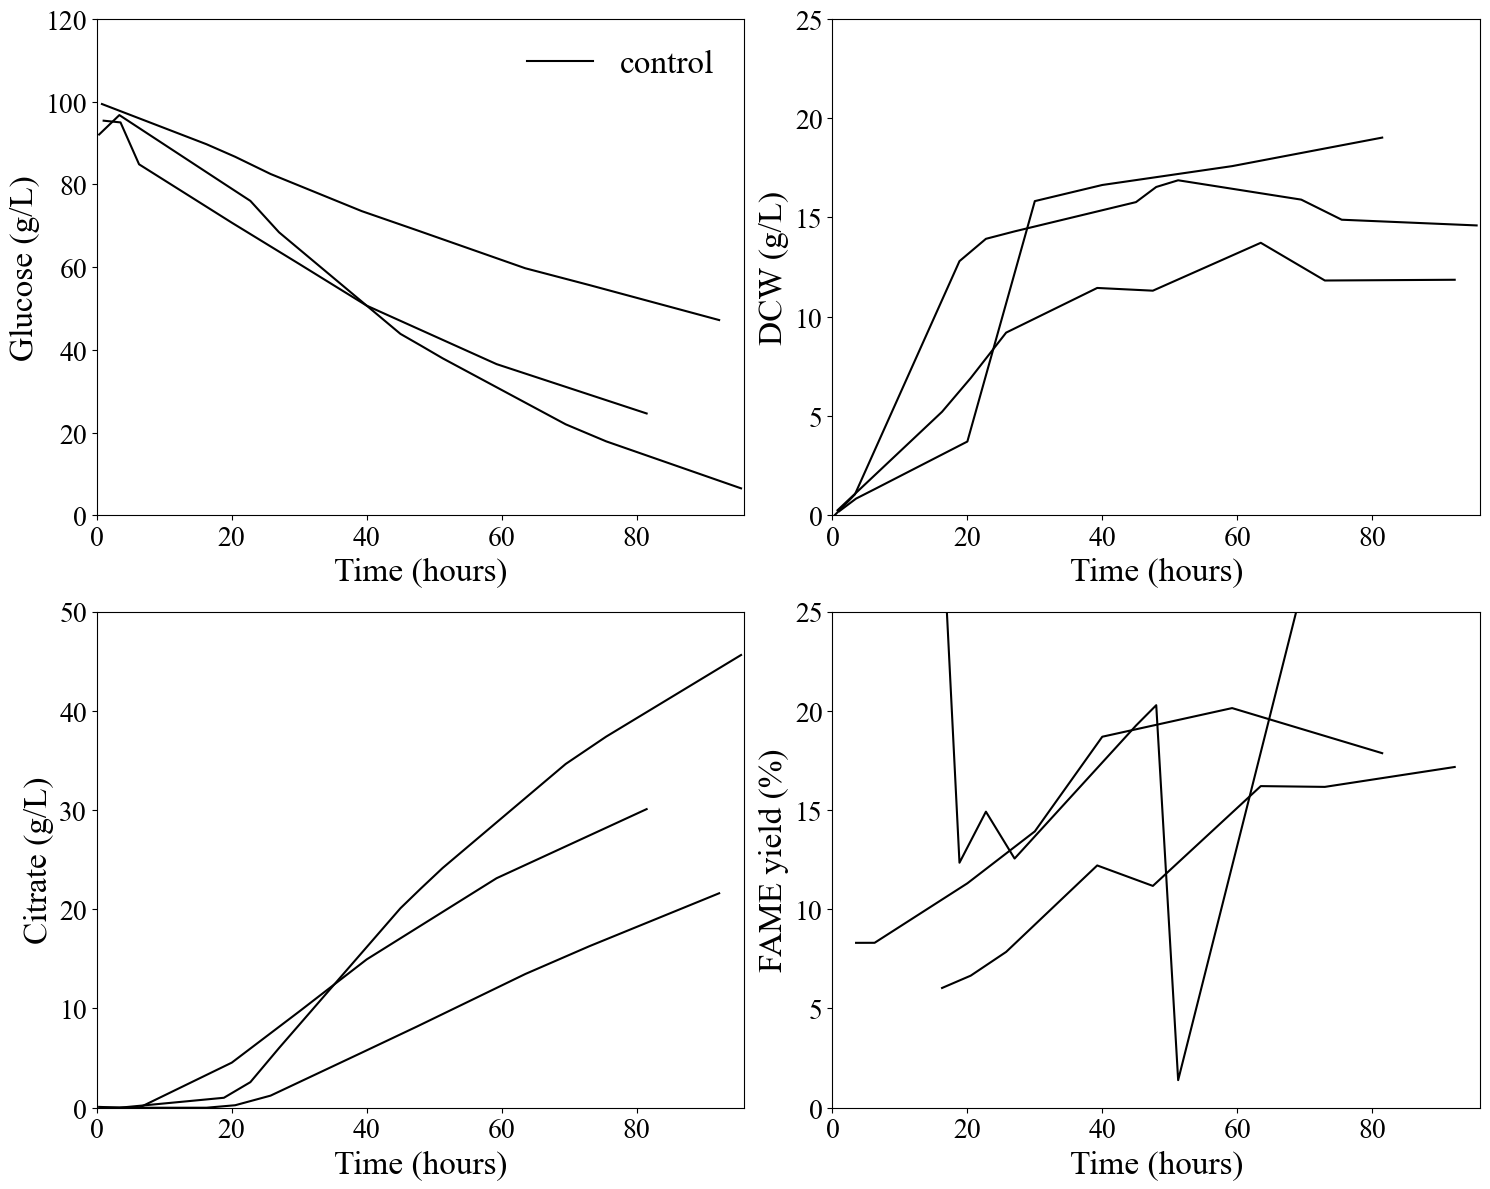

In [36]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Define the datasets and their labels and plotting styles
storages = [
    (Biostat_22_r1, 'Control (25% pO2)', 'black', '-'), # control
    # (Biostat_22_r2, '1 min osc', 'blue', '--'), # oscillating
    # (Biostat_23_r1, 'low O2', 'green', '-'),  # pO2 5%   
    # (Biostat_23_r2, 'Biostat 23 r2', 'blue', '-'), # oscillating
    (Biostat_24_r1, 'Control', 'black', '-'), # control
    # (Biostat_24_r2, '20 sec osc', 'orange', '-'), # 20 sec oscillating
    # (Biostat_26_r1, 'low O2', 'green', '-'), # pO2 5% 
    (Biostat_26_r2, 'Control', 'black', '-'), # control
    # (Biostat_27_r1, '1 min osc', 'red', '-.'), # oscillating
    # (Biostat_27_r2, 'low O2', 'red', '-.'),  # pO2 5% 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    # ('OD600', 'OD600', (0, 40)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 50)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()

# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        # axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
        axs[idx].plot(store['hour'], pd.to_numeric(store[y_col], errors='coerce'), label=label, color=color, linestyle=linestyle)

    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)

# Add the FAME yield data to the last subplot
idx_fame = 3  # this is the index for the last subplot
for store, label, color, linestyle in storages:
    if fame_yield_col in store:
        axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)

axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
axs[idx_fame].set_xlim(0, 96)
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['control',] #'1 min osc', 'low O2', '20 sec osc']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    # plt.Line2D([0], [0], color='blue', linestyle='-'),
    # plt.Line2D([0], [0], color='green', linestyle='-'),
    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
# plt.savefig('Biostat_phenotypeComparison_glucose_controls_2x2.png')
plt.show()


#### 1 min oscillations

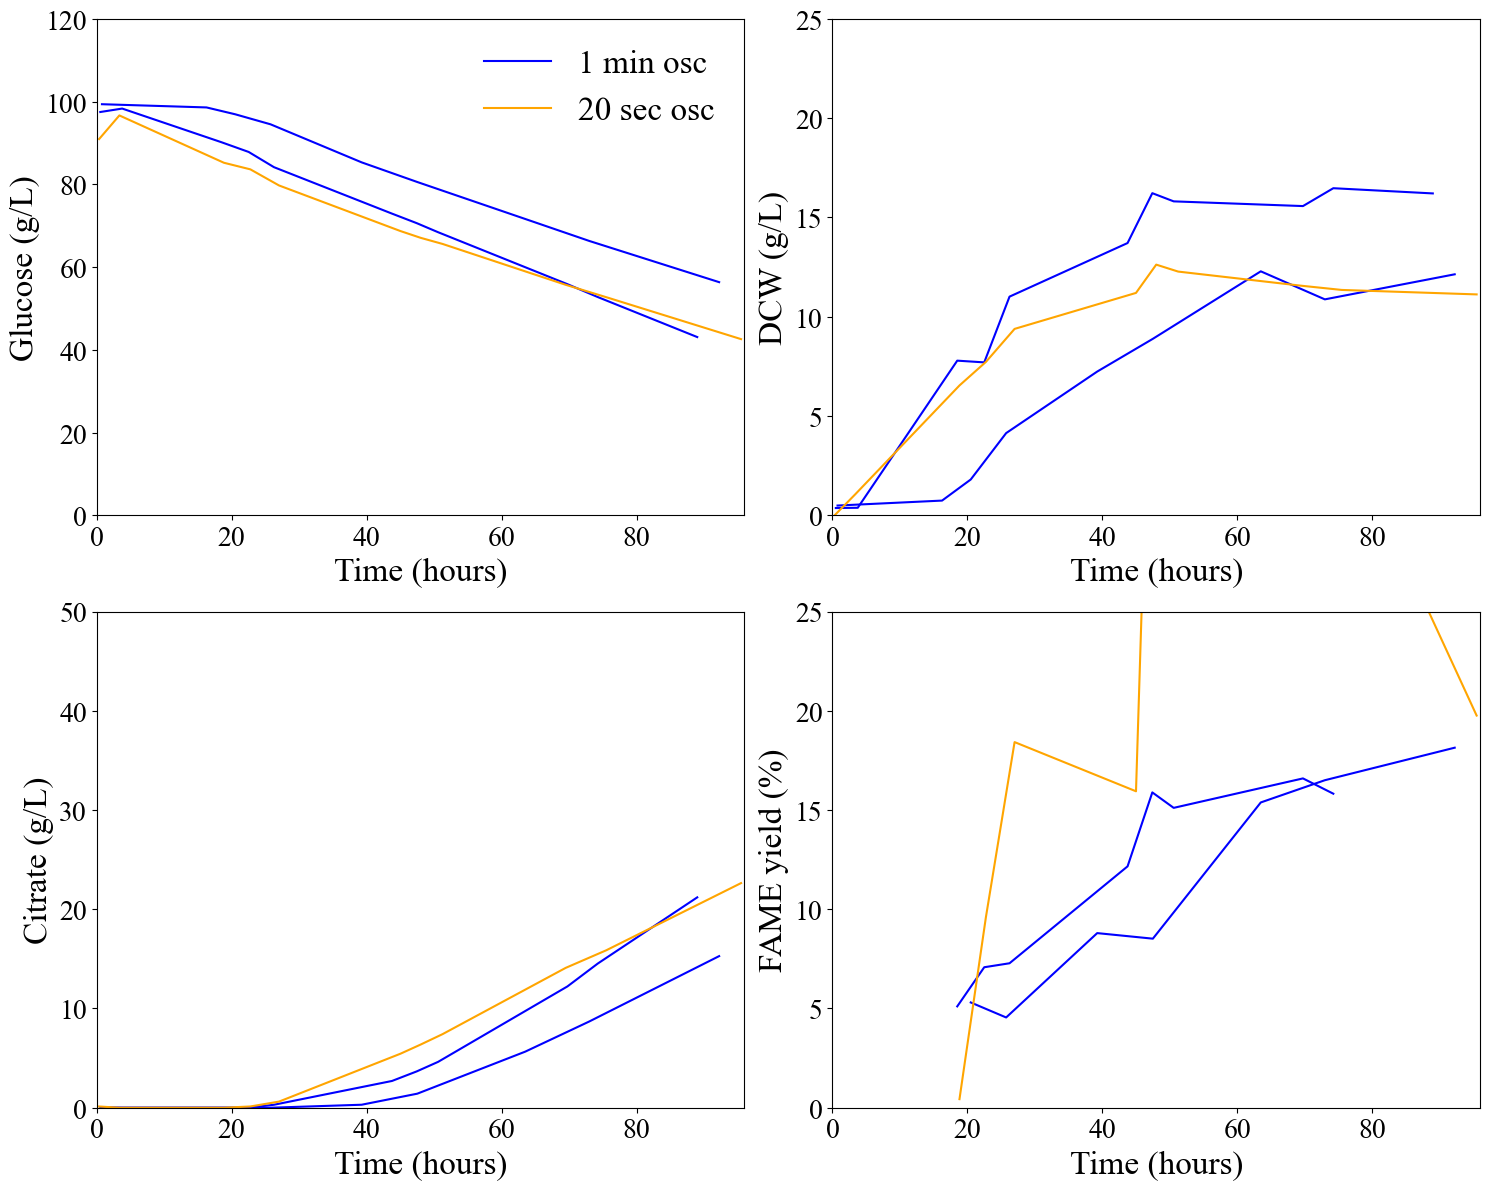

In [38]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Define the datasets and their labels and plotting styles
storages = [
    # (Biostat_22_r1, 'Control (25% pO2)', 'black', '-'), # control
    (Biostat_22_r2, '1 min osc - Biostat_22_r2', 'blue', '-'), # oscillating
    # (Biostat_23_r1, 'low O2', 'green', '-'),  # pO2 5%   
    (Biostat_23_r2, '1 min osc - Biostat_23_r2', 'blue', '-'), # oscillating
    # (Biostat_24_r1, 'Control', 'black', '-'), # control
    (Biostat_24_r2, '20 sec osc', 'orange', '-'), # 20 sec oscillating
    # (Biostat_26_r1, 'low O2', 'green', '-'), # pO2 5% 
    # (Biostat_26_r2, 'Control', 'black', '-'), # control
    (Biostat_27_r1, '1 min osc', 'blue', '-'), # oscillating
    # (Biostat_27_r2, 'low O2', 'red', '-.'),  # pO2 5% 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    # ('OD600', 'OD600', (0, 35)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 50)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()

# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        # axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
        axs[idx].plot(store['hour'], pd.to_numeric(store[y_col], errors='coerce'), label=label, color=color, linestyle=linestyle)

    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)

# Add the FAME yield data to the last subplot
idx_fame = 3  # this is the index for the last subplot
for store, label, color, linestyle in storages:
    if fame_yield_col in store:
        # axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
        if "Biostat_23_r2" in label:
            axs[idx_fame].plot(store['hour'][:-1], store[fame_yield_col][:-1] * 100, label=label, color=color, linestyle=linestyle)
        elif "Biostat_22_r2" in label:
            axs[idx_fame].plot(store['hour'].iloc[2:], store[fame_yield_col].iloc[2:] * 100, label=label, color=color, linestyle=linestyle)
        else:
            axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
axs[idx_fame].set_xlim(0, 96)
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = [ '1 min osc', '20 sec osc']
custom_lines = [
    # plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    # plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
# plt.savefig('Biostat_phenotypeComparison_2x2_oscillations.png')
plt.show()


#### low pO2

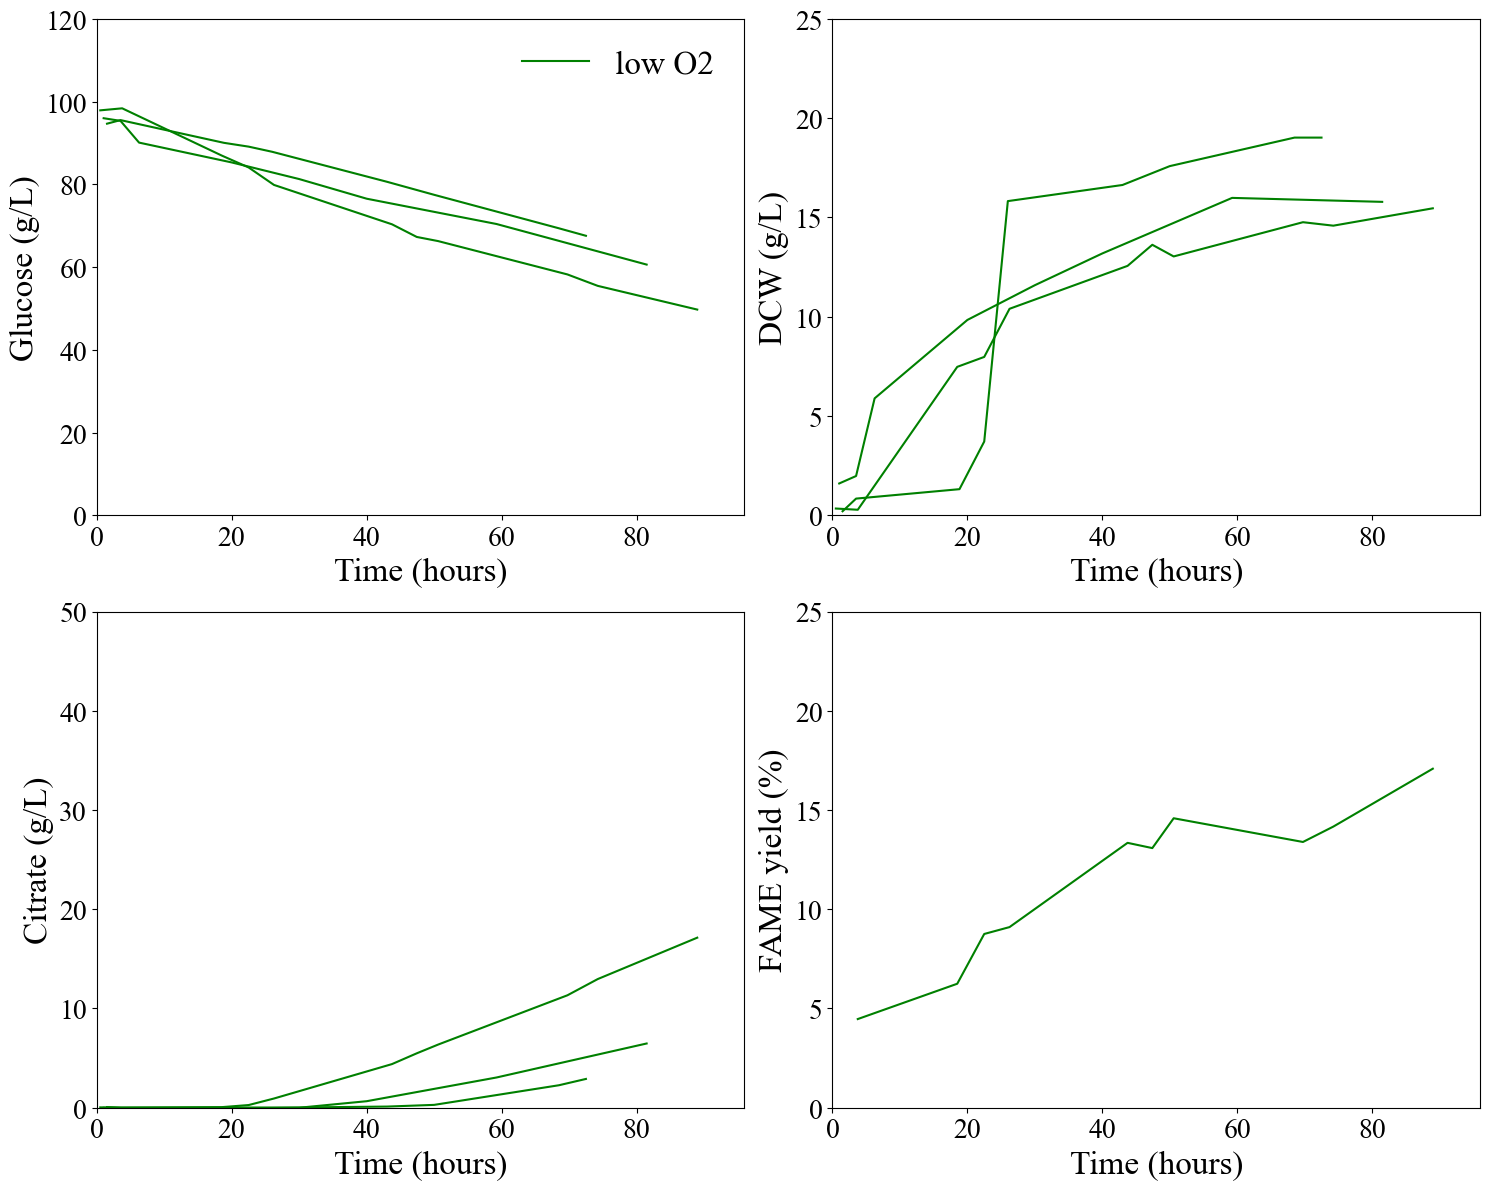

In [290]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Define the datasets and their labels and plotting styles
storages = [
    # (Biostat_22_r1, 'Control (25% pO2)', 'black', '-'), # control
    # (Biostat_22_r2, '1 min osc', 'blue', '-'), # oscillating
    (Biostat_23_r1, 'low O2', 'green', '-'),  # pO2 5%   
    # (Biostat_23_r2, 'Biostat 23 r2', 'blue', '-'), # oscillating
    # (Biostat_24_r1, 'Control', 'black', '-'), # control
    # (Biostat_24_r2, '20 sec osc', 'orange', '-'), # 20 sec oscillating
    (Biostat_26_r1, 'low O2', 'green', '-'), # pO2 5% 
    # (Biostat_26_r2, 'Control', 'black', '-'), # control
    # (Biostat_27_r1, '1 min osc', 'blue', '-.'), # oscillating
    (Biostat_27_r2, 'low O2', 'green', '-')  # pO2 5% 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    # ('OD600', 'OD600', (0, 35)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 50)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()

# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs[idx].plot(store['hour'], pd.to_numeric(store[y_col], errors='coerce'), label=label, color=color, linestyle=linestyle)

        # axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)

# Add the FAME yield data to the last subplot
idx_fame = 3  # this is the index for the last subplot
for store, label, color, linestyle in storages:
    if fame_yield_col in store:
        axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
axs[idx_fame].set_xlim(0, 96)
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = [ 'low O2']
custom_lines = [
    # plt.Line2D([0], [0], color='black', linestyle='-'),
    # plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
plt.savefig('Biostat_phenotypeComparison_2x2_lowO2.png')
plt.show()


#### O2 levels. 

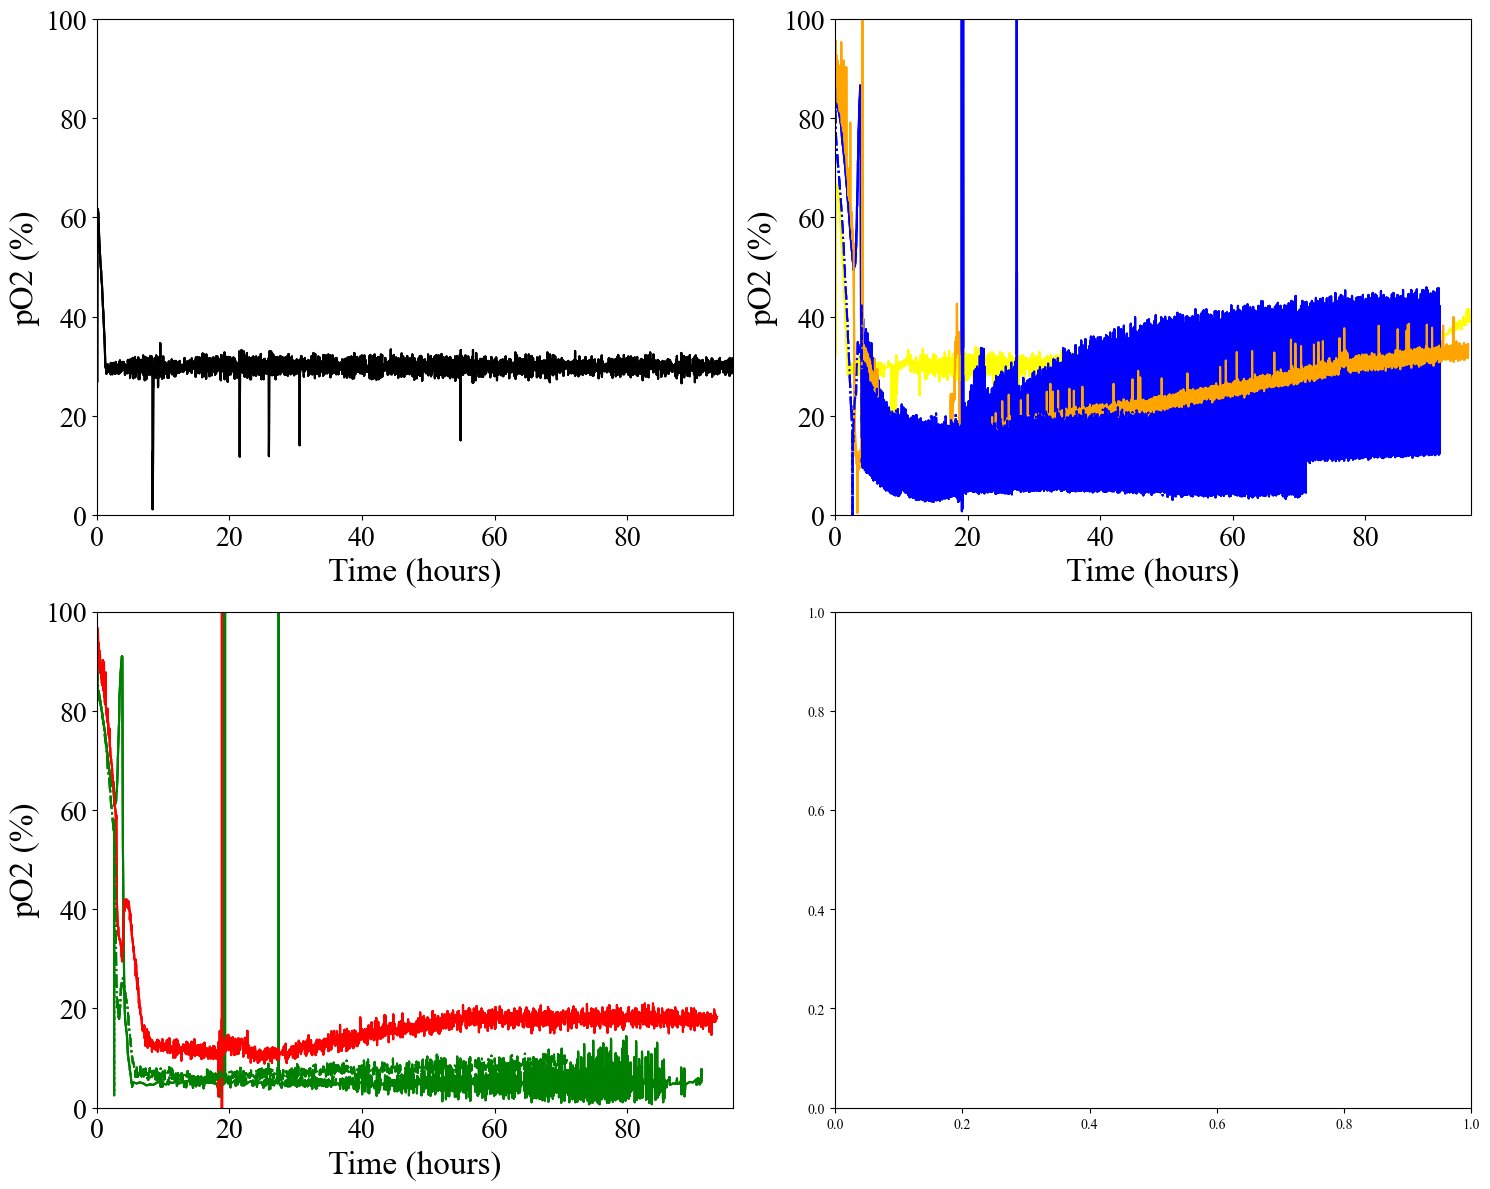

In [295]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Define the datasets and their labels and plotting styles
storages = [
    (storage_21_r1, 'Control (25% pO2)', 'black', '-'), # control
    (storage_21_r2, '1 min osc', 'yellow', '-'), # oscillating
    (storage_23_r1, 'low O2', 'green', '-'),  # pO2 5%   
    (storage_23_r2, '1 min osc', 'blue', '-'), # oscillating
    (storage_24_r1, 'Control', 'black', '-'), # control
    (storage_24_r2, '20 sec osc', 'orange', '-'), # 20 sec oscillating
    (storage_26_r1, 'low O2', 'red', '-'), # pO2 5% 
    (storage_26_r2, 'Control', 'black', '-'), # control
    (storage_27_r1, '1 min osc', 'blue', '-.'), # oscillating
    (storage_27_r2, 'low O2', 'green', '-.'),  # pO2 5% 
]



# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'pO2 (%)', (0, 100)),  # Adjust according to actual data range
    ('DCW (g/L)', 'pO2 (%)', (0, 100)),
    ('Citric Acid.1',  'pO2 (%)', (0, 100)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()

# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        if label == 'Control (25% pO2)':
            axs[0].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=label, color=color, linestyle=linestyle)
        if (label == '1 min osc') | (label == '20 sec osc'):
            axs[1].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=label, color=color, linestyle=linestyle)
        if label == 'low O2':
            axs[2].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=label, color=color, linestyle=linestyle)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)

# Add the FAME yield data to the last subplot
# idx_fame = 3  # this is the index for the last subplot
# for store, label, color, linestyle in storages:
#     if fame_yield_col in store:
#         axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
# axs[idx_fame].set_xlim(0, 96)
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
# custom_labels = [ '1 min osc', '20 sec osc']
# custom_lines = [
#     # plt.Line2D([0], [0], color='black', linestyle='-'),
#     plt.Line2D([0], [0], color='blue', linestyle='-'),
#     # plt.Line2D([0], [0], color='green', linestyle='-'),
#     plt.Line2D([0], [0], color='orange', linestyle='-'),
# ]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
# axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
plt.savefig('Biostat_pO2.png')
plt.show()


### Process data.

#### biostat 23r2

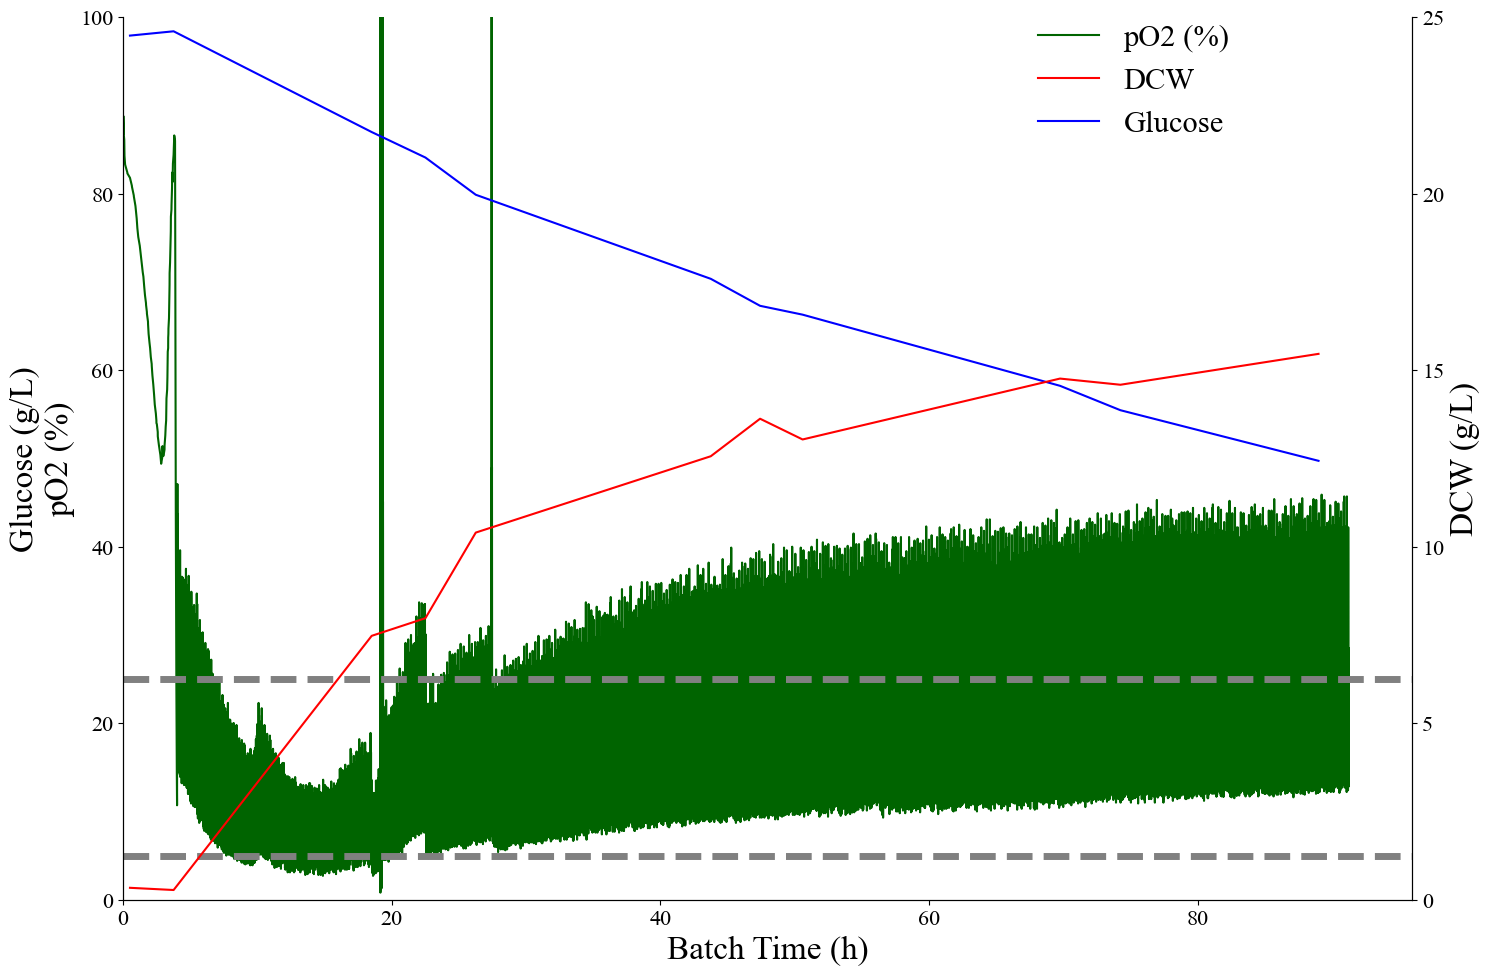

In [214]:
fig, ax = plt.subplots(ncols=1, figsize=(15, 10))

# plt.plot(storage_16_osc['PO2_A_Setpoint']['age'], storage_16_osc['PO2_A_Setpoint']['value'],'r--')
storages = [storage_22_r2,storage_20_r2, storage_21_r1, storage_21_r2, storage_22_r2, storage_22_r1,]

# annotation2 = ['Biostat16 (YNB)',"Biostat20_r1 (YNB50, C/N 60 seed)","Biostat20_r1 (YNB50, C/N 40 seed)","Biostat21_r1 (1/6YPD)", "Biostat21_r2 (YNB+YE)"]

# titles = ['Plot 1: Biostat16', 'Plot 2: Biostat20_r1', 'Plot 3: Biostat21_r1']
x_labels = ['Batch Time (h)', 'Elapsed Time (h)', 'Fermentation Time (h)']
y_labels = ['Dissolved oxygen (%)', 'Stir rate (RPM)', 'Aeration (VVM)']

values = ['PO2_A_Value', 'STIRR_Value','AIRSP_A_Value']
ax_lims = [100,800,1.5]

# Define the colors to match each plot's line style
# colors = ['blue', 'orange', 'green', 'red', 'purple','black']  # Define colors for each dataframe

# Plot each subplot
idx=0
c=0
# Plot the data for each storage dataset

#ax.plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=annotation2[c], color=colors[c])
lns1 = ax.plot(storage_23_r2[values[idx]]['age'], storage_23_r2[values[idx]]['value'], label='pO2 (%)', color='DarkGreen')
ax.set_ylim(0, ax_lims[idx])
ax.set_xlim(0,96)

# Plot IncyteData in the last subplot with a secondary y-axis
# ax_last = axs[-1]
ax_twin = ax.twinx()
# lns2 = ax_twin.plot(IncyteData_22_r2['Time (h)'], IncyteData_22_r2['Permittivity(pF/cm)'], color='black', label='Permittivity (pF/cm)')
lns2 = ax_twin.plot(Biostat_23_r1['hour'], Biostat_23_r1['DCW (g/L)'], color='red', label='DCW')

lns3 = ax.plot(Biostat_23_r1['hour'], Biostat_23_r1['Glucose.1'], color='blue', label='Glucose')


# ax.set_title(titles[idx], fontsize=18)
ax.set_xlabel(x_labels[idx], fontsize=24)
ax.set_ylabel('Glucose (g/L)\npO2 (%)', fontsize=24)
# ax_twin.set_ylabel('DCW (g/L) and \n Permittivity (pF/cm)', fontsize=24)

ax_twin.set_ylabel('DCW (g/L)', fontsize=24)

ax_twin.set_ylim(0,25)

# Plot horizontal lines at y = 25 and y = 5
ax.axhline(y=25, color='Gray', linestyle='--', linewidth=5)
ax.axhline(y=5, color='Gray', linestyle='--', linewidth=5)


# Add legend for each subplot
# Combine all legend entries
lns = lns1 + lns2 + lns3 
labs = [l.get_label() for l in lns]
# ax.legend(lns, labs, fontsize=16, loc=(0.8,0.85))
ax.legend(lns, labs, fontsize=22, loc=(0.7,0.85),frameon=False)

# Apply font styles globally
# Set tick sizes for all axes
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=12)
ax_twin.tick_params(axis='both', which='major', labelsize=16)
ax_twin.tick_params(axis='both', which='minor', labelsize=12)

ax.margins(y=0)
ax_twin.margins(y=0)



ax.spines['top'].set_visible(False)
ax_twin.spines['top'].set_visible(False)
# Adjust spacing between plots
plt.tight_layout()

plt.savefig('Biostat23_oscillations_complete.png')
# plt.savefig('plot_key_parms.png')


#### biostat27_r2

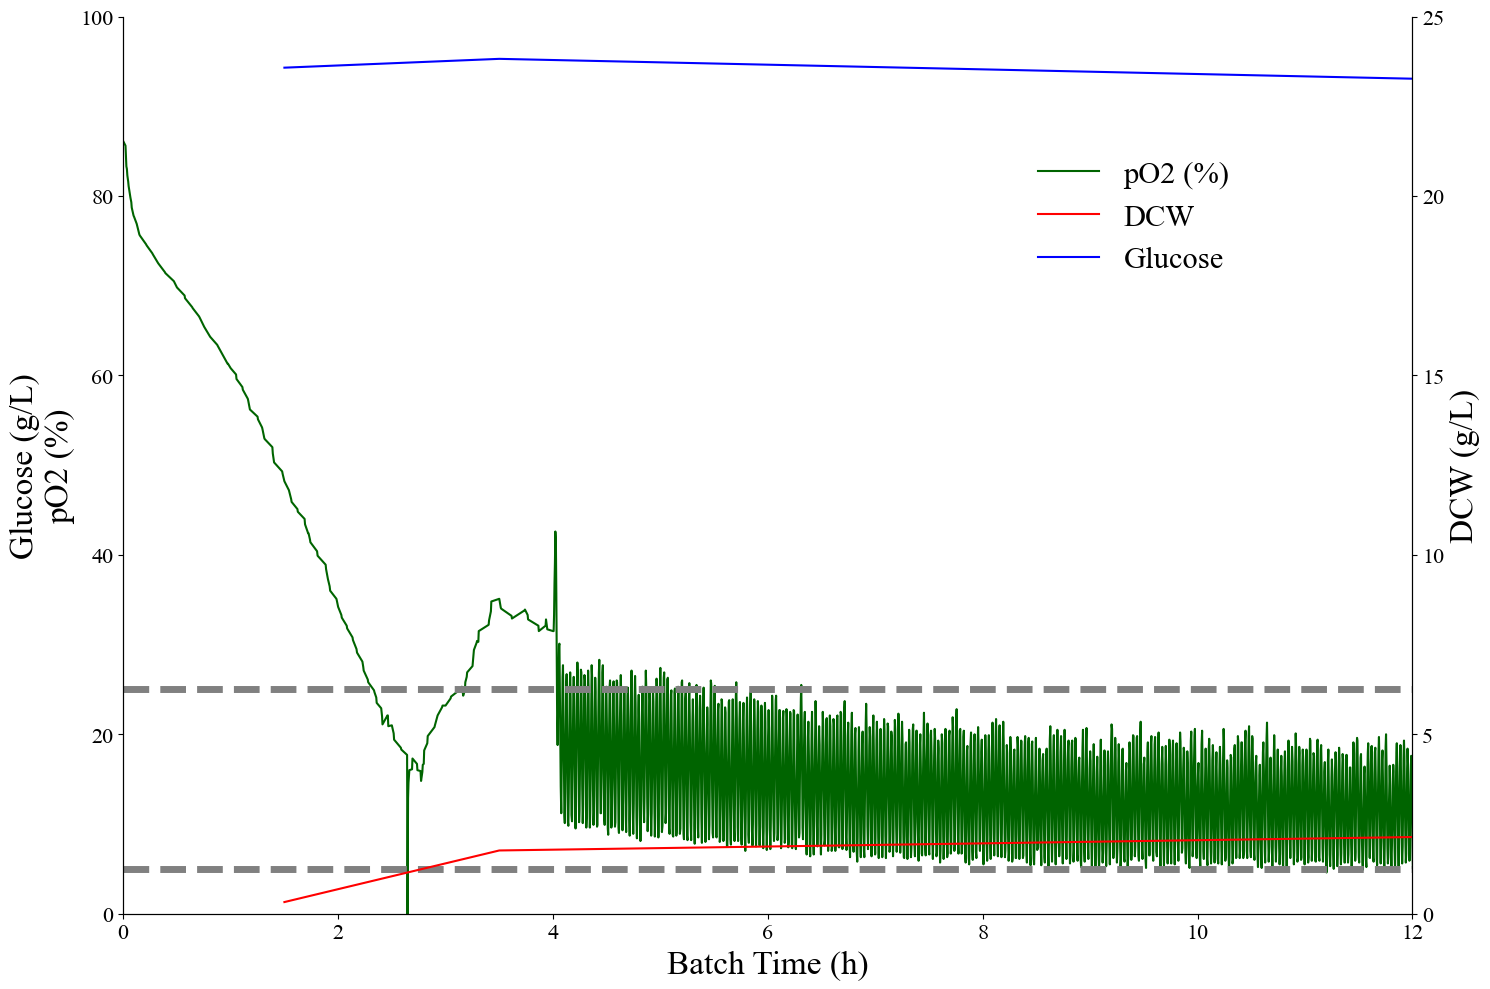

In [302]:
fig, ax = plt.subplots(ncols=1, figsize=(15, 10))

# plt.plot(storage_16_osc['PO2_A_Setpoint']['age'], storage_16_osc['PO2_A_Setpoint']['value'],'r--')
storages = [storage_22_r2,storage_20_r2, storage_21_r1, storage_21_r2, storage_22_r2, storage_22_r1,]

# annotation2 = ['Biostat16 (YNB)',"Biostat20_r1 (YNB50, C/N 60 seed)","Biostat20_r1 (YNB50, C/N 40 seed)","Biostat21_r1 (1/6YPD)", "Biostat21_r2 (YNB+YE)"]

# titles = ['Plot 1: Biostat16', 'Plot 2: Biostat20_r1', 'Plot 3: Biostat21_r1']
x_labels = ['Batch Time (h)', 'Elapsed Time (h)', 'Fermentation Time (h)']
y_labels = ['Dissolved oxygen (%)', 'Stir rate (RPM)', 'Aeration (VVM)']

values = ['PO2_A_Value', 'STIRR_Value','AIRSP_A_Value']
ax_lims = [100,800,1.5]

# Define the colors to match each plot's line style
# colors = ['blue', 'orange', 'green', 'red', 'purple','black']  # Define colors for each dataframe

# Plot each subplot
idx=0
c=0
# Plot the data for each storage dataset

#ax.plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=annotation2[c], color=colors[c])
lns1 = ax.plot(storage_27_r1[values[idx]]['age'], storage_27_r1[values[idx]]['value'], label='pO2 (%)', color='DarkGreen')
ax.set_ylim(0, ax_lims[idx])
ax.set_xlim(0,12)

# Plot IncyteData in the last subplot with a secondary y-axis
# ax_last = axs[-1]
ax_twin = ax.twinx()
# lns2 = ax_twin.plot(IncyteData_22_r2['Time (h)'], IncyteData_22_r2['Permittivity(pF/cm)'], color='black', label='Permittivity (pF/cm)')
lns2 = ax_twin.plot(Biostat_27_r1['hour'], Biostat_27_r1['DCW (g/L)'], color='red', label='DCW')

lns3 = ax.plot(Biostat_27_r1['hour'], Biostat_27_r1['Glucose.1'], color='blue', label='Glucose')


# ax.set_title(titles[idx], fontsize=18)
ax.set_xlabel(x_labels[idx], fontsize=24)
ax.set_ylabel('Glucose (g/L)\npO2 (%)', fontsize=24)
# ax_twin.set_ylabel('DCW (g/L) and \n Permittivity (pF/cm)', fontsize=24)

ax_twin.set_ylabel('DCW (g/L)', fontsize=24)

ax_twin.set_ylim(0,25)

# Plot horizontal lines at y = 25 and y = 5
ax.axhline(y=25, color='Gray', linestyle='--', linewidth=5)
ax.axhline(y=5, color='Gray', linestyle='--', linewidth=5)


# Add legend for each subplot
# Combine all legend entries
lns = lns1 + lns2 + lns3 
labs = [l.get_label() for l in lns]
# ax.legend(lns, labs, fontsize=16, loc=(0.8,0.85))
ax.legend(lns, labs, fontsize=22, loc=(0.7,0.7),frameon=False)

# Apply font styles globally
# Set tick sizes for all axes
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=12)
ax_twin.tick_params(axis='both', which='major', labelsize=16)
ax_twin.tick_params(axis='both', which='minor', labelsize=12)

ax.margins(y=0)
ax_twin.margins(y=0)



ax.spines['top'].set_visible(False)
ax_twin.spines['top'].set_visible(False)
# Adjust spacing between plots
plt.tight_layout()

plt.savefig('Biostat27_oscillations_zoomed.png')
# plt.savefig('plot_key_parms.png')


#### biostat 22 r2

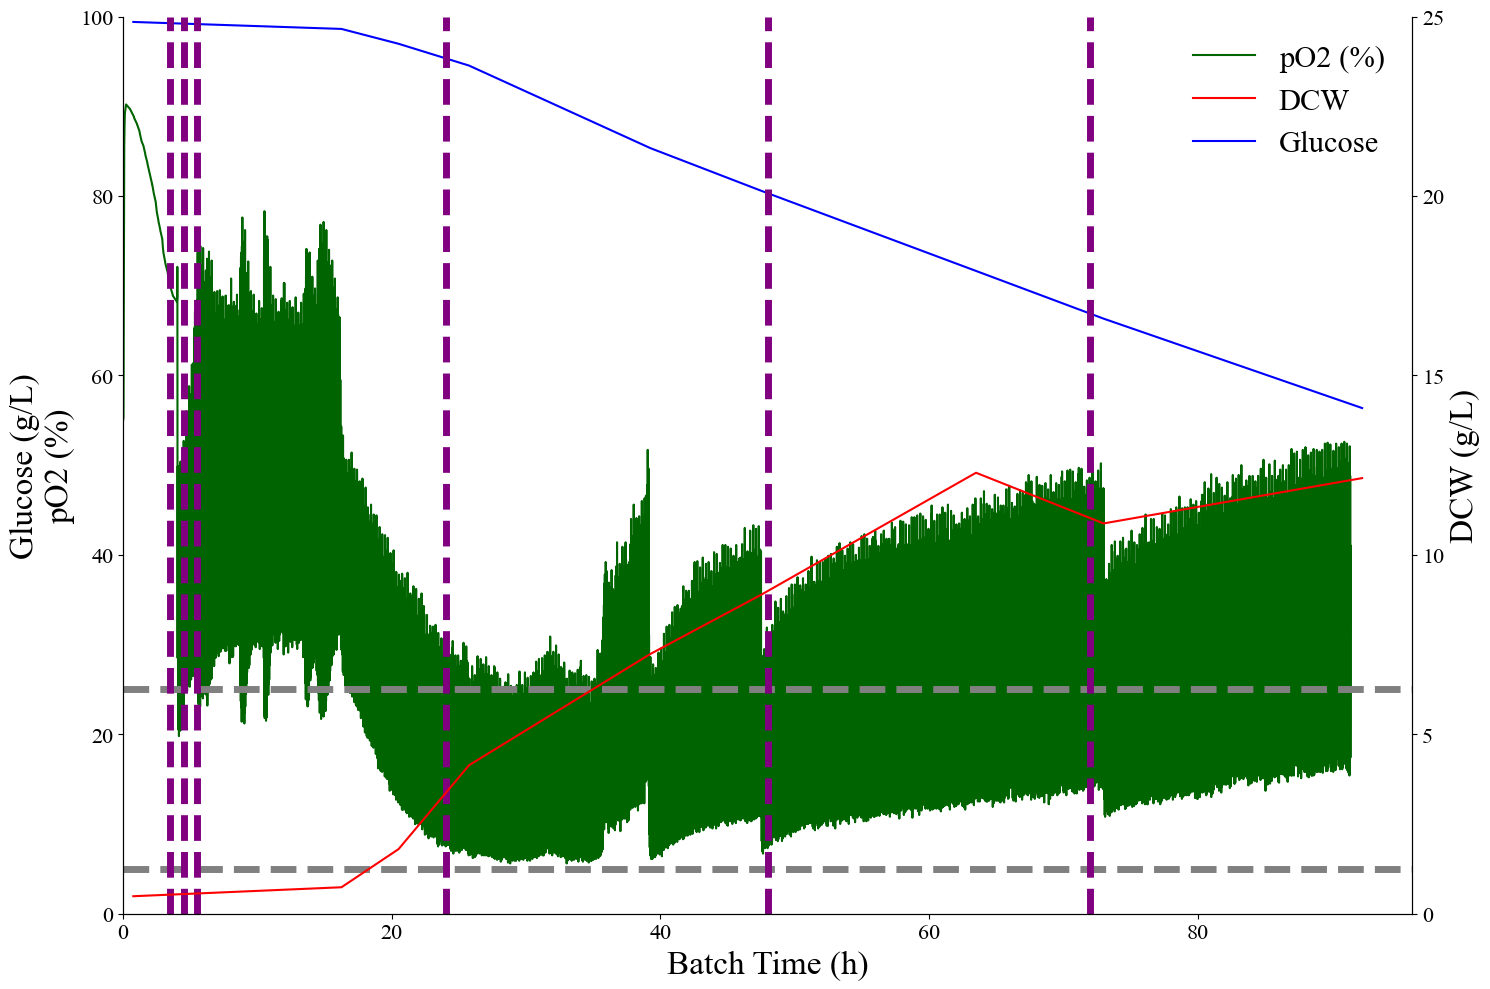

In [243]:
fig, ax = plt.subplots(ncols=1, figsize=(15, 10))

# plt.plot(storage_16_osc['PO2_A_Setpoint']['age'], storage_16_osc['PO2_A_Setpoint']['value'],'r--')
storages = [storage_22_r2,storage_20_r2, storage_21_r1, storage_21_r2, storage_22_r2, storage_22_r1,]

# annotation2 = ['Biostat16 (YNB)',"Biostat20_r1 (YNB50, C/N 60 seed)","Biostat20_r1 (YNB50, C/N 40 seed)","Biostat21_r1 (1/6YPD)", "Biostat21_r2 (YNB+YE)"]

# titles = ['Plot 1: Biostat16', 'Plot 2: Biostat20_r1', 'Plot 3: Biostat21_r1']
x_labels = ['Batch Time (h)', 'Elapsed Time (h)', 'Fermentation Time (h)']
y_labels = ['Dissolved oxygen (%)', 'Stir rate (RPM)', 'Aeration (VVM)']

values = ['PO2_A_Value', 'STIRR_Value','AIRSP_A_Value']
ax_lims = [100,800,1.5]

# Define the colors to match each plot's line style
# colors = ['blue', 'orange', 'green', 'red', 'purple','black']  # Define colors for each dataframe

# Plot each subplot
idx=0
c=0
# Plot the data for each storage dataset

#ax.plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=annotation2[c], color=colors[c])
lns1 = ax.plot(storage_22_r2[values[idx]]['age'], storage_22_r2[values[idx]]['value'], label='pO2 (%)', color='DarkGreen')
ax.set_ylim(0, ax_lims[idx])
ax.set_xlim(0,96)

# Plot IncyteData in the last subplot with a secondary y-axis
# ax_last = axs[-1]
ax_twin = ax.twinx()
# lns2 = ax_twin.plot(IncyteData_22_r2['Time (h)'], IncyteData_22_r2['Permittivity(pF/cm)'], color='black', label='Permittivity (pF/cm)')
lns2 = ax_twin.plot(Biostat_22_r2['hour'], Biostat_22_r2['DCW (g/L)'], color='red', label='DCW')

lns3 = ax.plot(Biostat_22_r2['hour'], Biostat_22_r2['Glucose.1'], color='blue', label='Glucose')


# ax.set_title(titles[idx], fontsize=18)
ax.set_xlabel(x_labels[idx], fontsize=24)
ax.set_ylabel('Glucose (g/L)\npO2 (%)', fontsize=24)
# ax_twin.set_ylabel('DCW (g/L) and \n Permittivity (pF/cm)', fontsize=24)

ax_twin.set_ylabel('DCW (g/L)', fontsize=24)

ax_twin.set_ylim(0,25)

# Plot horizontal lines at y = 25 and y = 5
ax.axhline(y=25, color='Gray', linestyle='--', linewidth=5)
ax.axhline(y=5, color='Gray', linestyle='--', linewidth=5)


ax.axvline(x=3.5, color='Purple', linestyle='--', linewidth=5)
ax.axvline(x=4.5, color='Purple', linestyle='--', linewidth=5)
ax.axvline(x=5.5, color='Purple', linestyle='--', linewidth=5)
ax.axvline(x=24, color='Purple', linestyle='--', linewidth=5)
ax.axvline(x=48, color='Purple', linestyle='--', linewidth=5)
ax.axvline(x=72, color='Purple', linestyle='--', linewidth=5)





# Add legend for each subplot
# Combine all legend entries
lns = lns1 + lns2 + lns3 
labs = [l.get_label() for l in lns]
# ax.legend(lns, labs, fontsize=16, loc=(0.8,0.85))
ax.legend(lns, labs, fontsize=22, loc='best',frameon=False)

# Apply font styles globally
# Set tick sizes for all axes
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=12)
ax_twin.tick_params(axis='both', which='major', labelsize=16)
ax_twin.tick_params(axis='both', which='minor', labelsize=12)

ax.margins(y=0)
ax_twin.margins(y=0)



ax.spines['top'].set_visible(False)
ax_twin.spines['top'].set_visible(False)
# Adjust spacing between plots
plt.tight_layout()

plt.savefig('Biostat22_oscillations_samplingh.png')
# plt.savefig('plot_key_parms.png')


#### Biostat27_r2

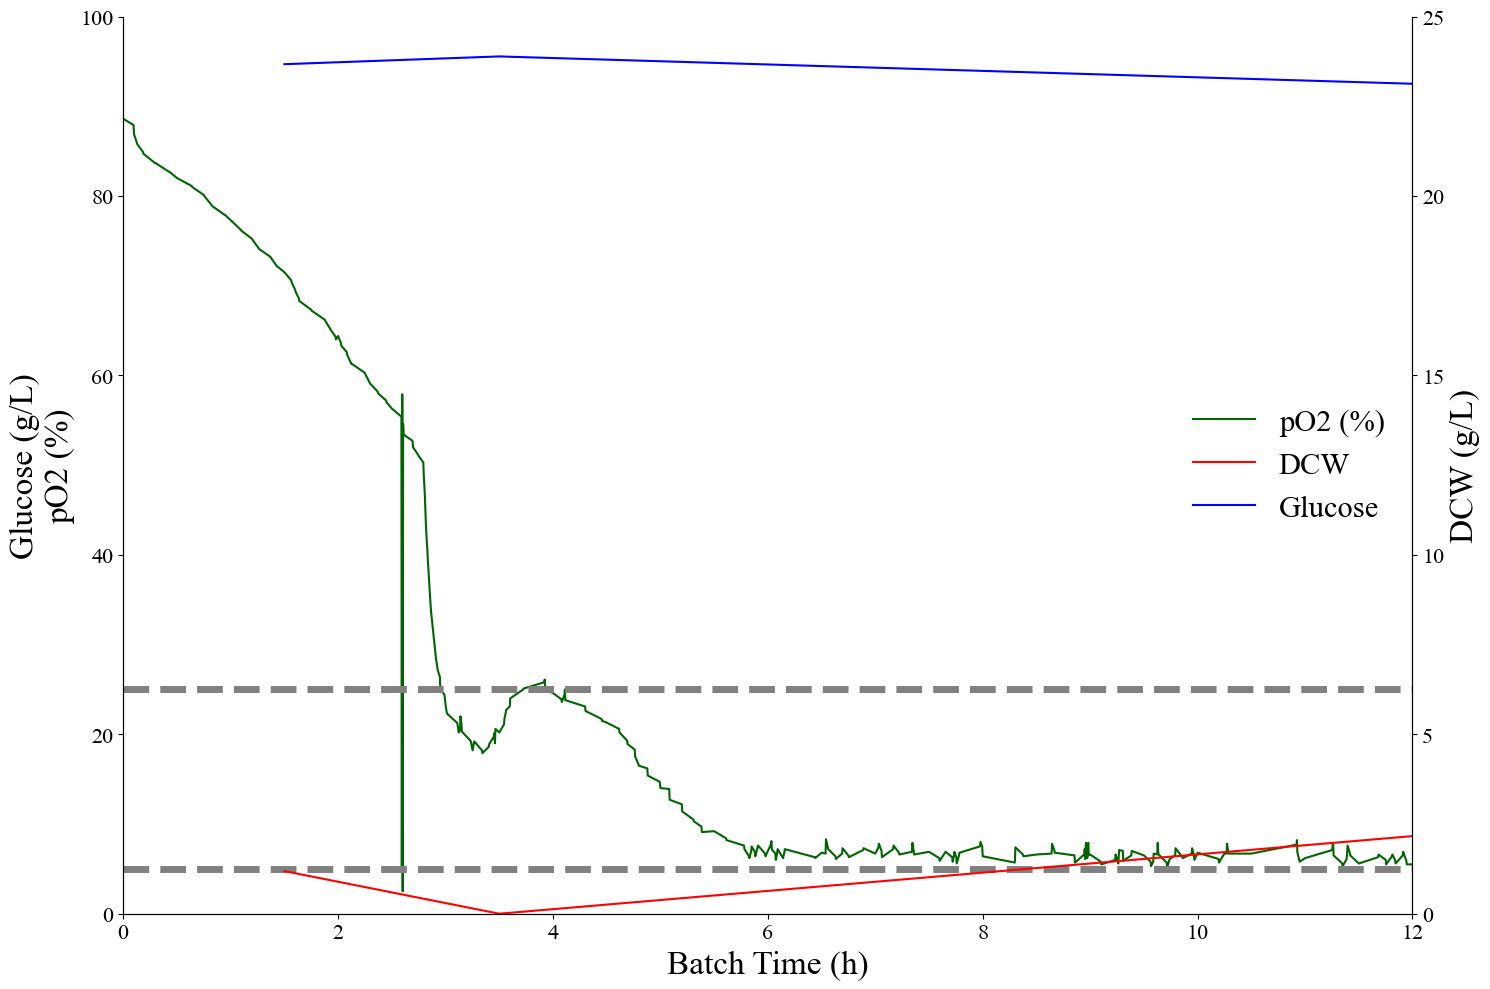

In [245]:
fig, ax = plt.subplots(ncols=1, figsize=(15, 10))

# plt.plot(storage_16_osc['PO2_A_Setpoint']['age'], storage_16_osc['PO2_A_Setpoint']['value'],'r--')
storages = [storage_22_r2,storage_20_r2, storage_21_r1, storage_21_r2, storage_22_r2, storage_22_r1,]

# annotation2 = ['Biostat16 (YNB)',"Biostat20_r1 (YNB50, C/N 60 seed)","Biostat20_r1 (YNB50, C/N 40 seed)","Biostat21_r1 (1/6YPD)", "Biostat21_r2 (YNB+YE)"]

# titles = ['Plot 1: Biostat16', 'Plot 2: Biostat20_r1', 'Plot 3: Biostat21_r1']
x_labels = ['Batch Time (h)', 'Elapsed Time (h)', 'Fermentation Time (h)']
y_labels = ['Dissolved oxygen (%)', 'Stir rate (RPM)', 'Aeration (VVM)']

values = ['PO2_A_Value', 'STIRR_Value','AIRSP_A_Value']
ax_lims = [100,800,1.5]

# Define the colors to match each plot's line style
# colors = ['blue', 'orange', 'green', 'red', 'purple','black']  # Define colors for each dataframe

# Plot each subplot
idx=0
c=0
# Plot the data for each storage dataset

#ax.plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=annotation2[c], color=colors[c])
lns1 = ax.plot(storage_27_r2[values[idx]]['age'], storage_27_r2[values[idx]]['value'], label='pO2 (%)', color='DarkGreen')
ax.set_ylim(0, ax_lims[idx])
ax.set_xlim(0,12)

# Plot IncyteData in the last subplot with a secondary y-axis
# ax_last = axs[-1]
ax_twin = ax.twinx()
# lns2 = ax_twin.plot(IncyteData_22_r2['Time (h)'], IncyteData_22_r2['Permittivity(pF/cm)'], color='black', label='Permittivity (pF/cm)')
lns2 = ax_twin.plot(Biostat_27_r2['hour'], Biostat_27_r2['DCW (g/L)'], color='red', label='DCW')

lns3 = ax.plot(Biostat_27_r2['hour'], Biostat_27_r2['Glucose.1'], color='blue', label='Glucose')


# ax.set_title(titles[idx], fontsize=18)
ax.set_xlabel(x_labels[idx], fontsize=24)
ax.set_ylabel('Glucose (g/L)\npO2 (%)', fontsize=24)
# ax_twin.set_ylabel('DCW (g/L) and \n Permittivity (pF/cm)', fontsize=24)

ax_twin.set_ylabel('DCW (g/L)', fontsize=24)

ax_twin.set_ylim(0,25)

# Plot horizontal lines at y = 25 and y = 5
ax.axhline(y=25, color='Gray', linestyle='--', linewidth=5)
ax.axhline(y=5, color='Gray', linestyle='--', linewidth=5)


# ax.axvline(x=3.5, color='Purple', linestyle='--', linewidth=5)
# ax.axvline(x=4.5, color='Purple', linestyle='--', linewidth=5)
# ax.axvline(x=5.5, color='Purple', linestyle='--', linewidth=5)
# ax.axvline(x=24, color='Purple', linestyle='--', linewidth=5)
# ax.axvline(x=48, color='Purple', linestyle='--', linewidth=5)
# ax.axvline(x=72, color='Purple', linestyle='--', linewidth=5)





# Add legend for each subplot
# Combine all legend entries
lns = lns1 + lns2 + lns3 
labs = [l.get_label() for l in lns]
# ax.legend(lns, labs, fontsize=16, loc=(0.8,0.85))
ax.legend(lns, labs, fontsize=22, loc='best',frameon=False)

# Apply font styles globally
# Set tick sizes for all axes
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=12)
ax_twin.tick_params(axis='both', which='major', labelsize=16)
ax_twin.tick_params(axis='both', which='minor', labelsize=12)

ax.margins(y=0)
ax_twin.margins(y=0)



ax.spines['top'].set_visible(False)
ax_twin.spines['top'].set_visible(False)
# Adjust spacing between plots
plt.tight_layout()

plt.savefig('Biostat27_low_o2_zoomed.png')
# plt.savefig('plot_key_parms.png')


#### combined all data. oscillations

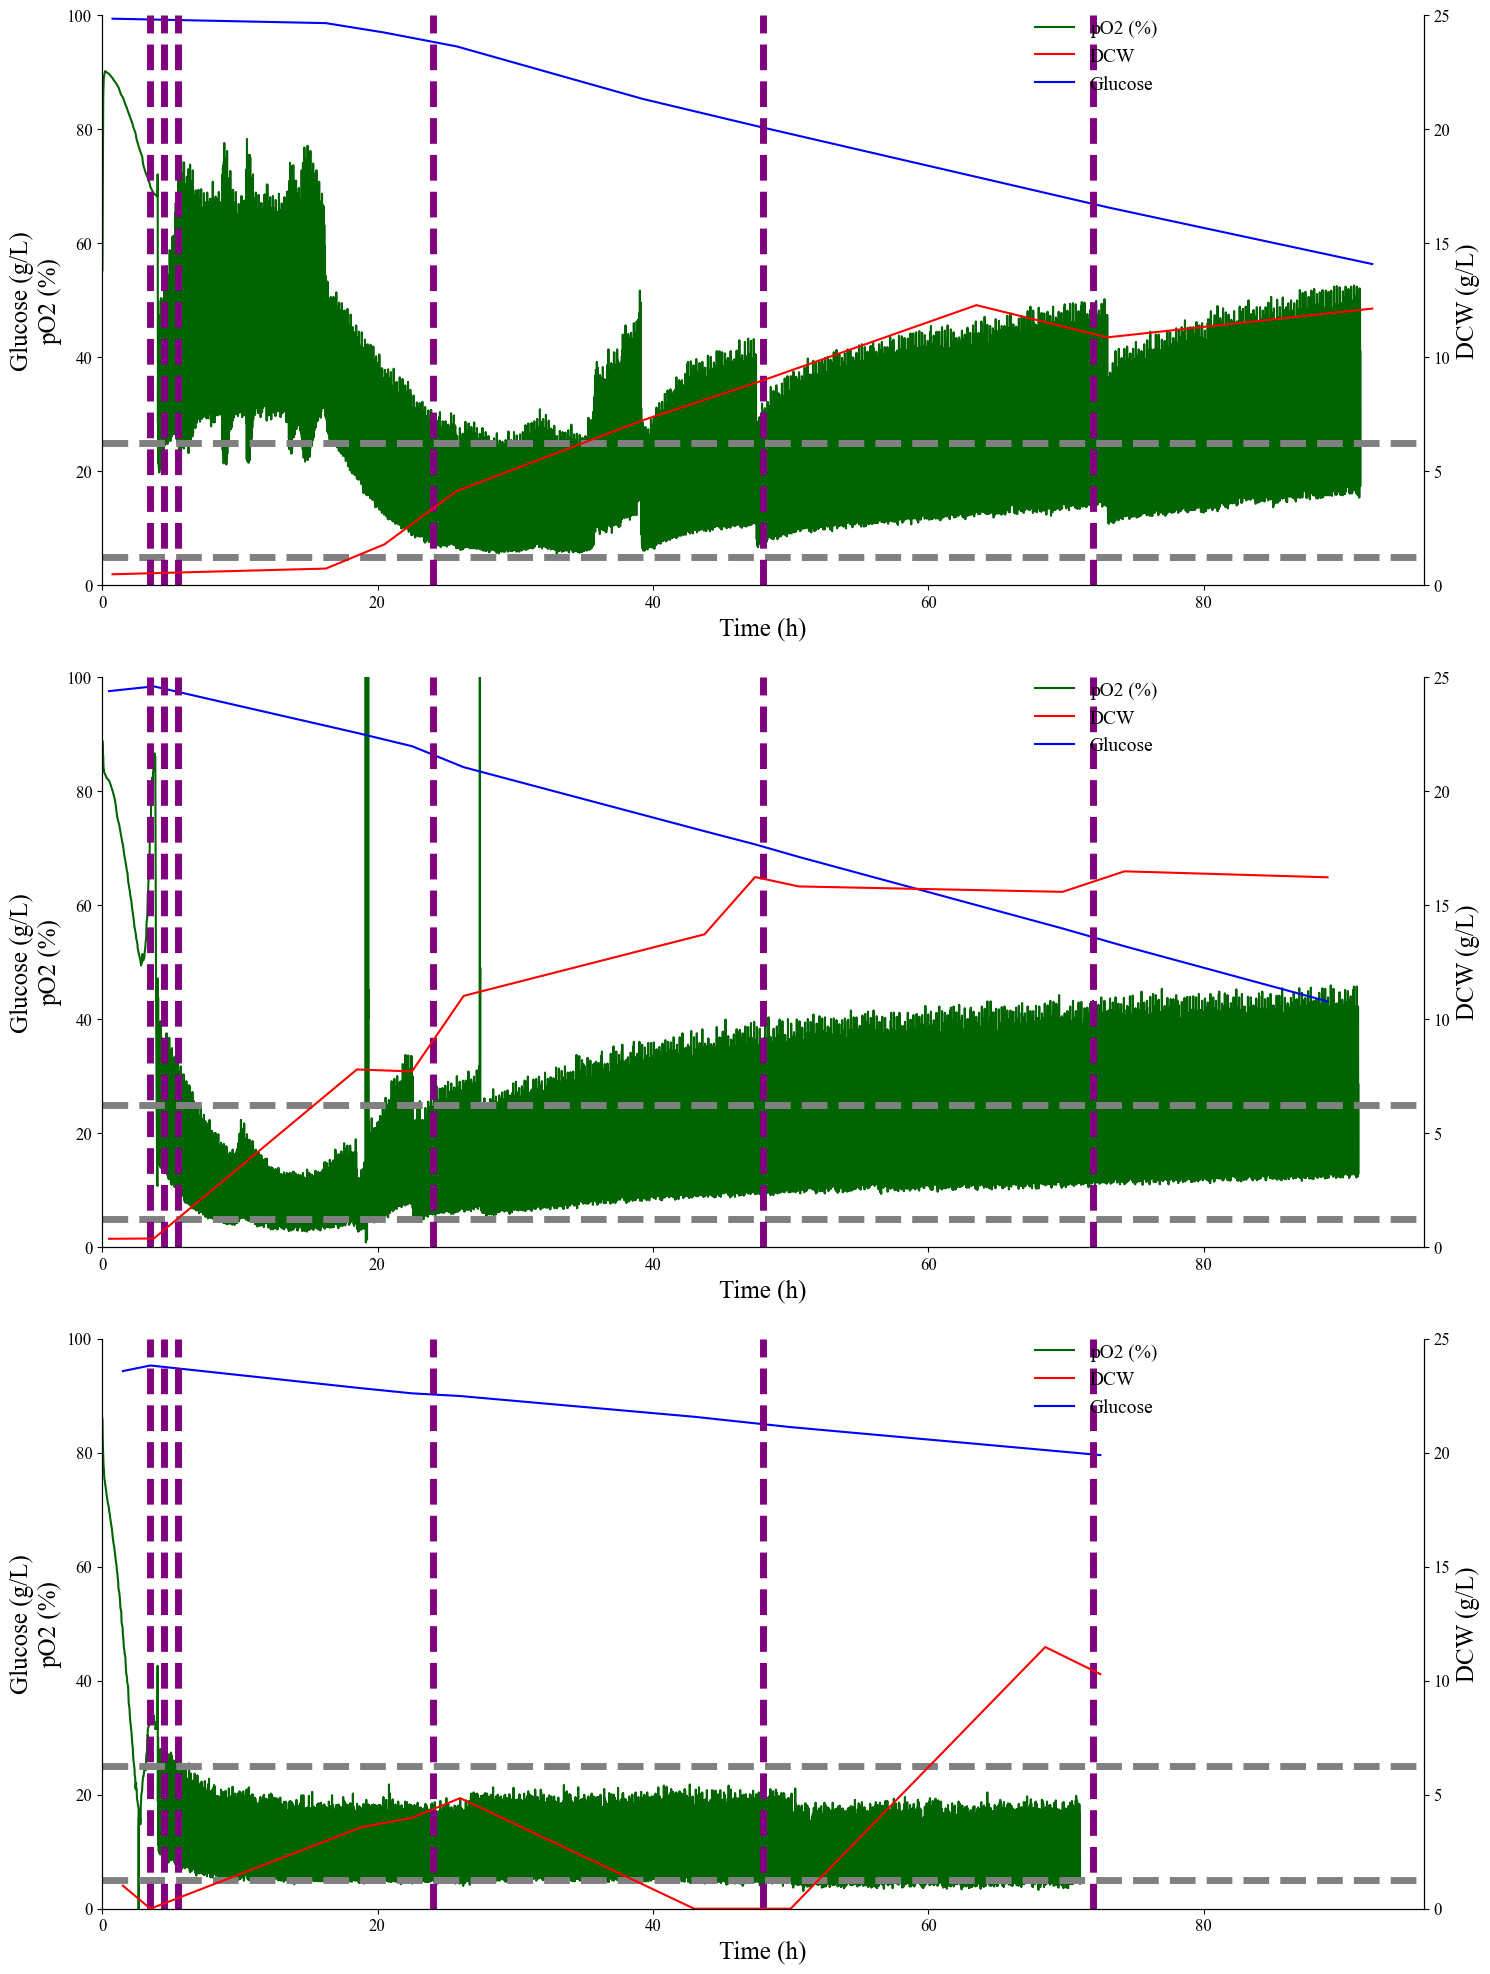

In [246]:

# Create subplots with 3 rows and 1 column
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(15, 20))

# Storage data 
# The dictionaries below should contain your actual data
storage_data = {
    'biostat22_r2': storage_22_r2,
    'biostat23_r2': storage_23_r2,
    # 'biostat24_r2': storage_24_r2,

    'biostat27_r1': storage_27_r1,

}

biostat_data = {

    'biostat22_r2': Biostat_22_r2,
    'biostat23_r2': Biostat_23_r2,
    # 'biostat24_r2': Biostat_24_r2,
    'biostat27_r1': Biostat_27_r1,
}

# Values and labels for each plot
# values = ['PO2_A_Value', 'PO2_A_Value', 'PO2_A_Value']
# x_labels = ['Batch Time (h)', 'Batch Time (h)', 'Batch Time (h)',]
# y_labels = ['pO2 (%)', 'pO2 (%)', 'pO2 (%)']
ax_lims = [100, 100, 100]

# Iterate through each subplot data
for idx, (key, storage) in enumerate(storage_data.items()):
    # Plot each subplot
    ax = axs[idx]

    # Plot main data
    lns1 = ax.plot(storage['PO2_A_Value']['age'], storage['PO2_A_Value']['value'], label='pO2 (%)', color='DarkGreen')
    ax.set_ylim(0, 100)
    ax.set_xlim(0, 96)

    # Use corresponding biostat data for secondary axis data
    biostat = biostat_data[key]
    ax_twin = ax.twinx()
    lns2 = ax_twin.plot(biostat['hour'], biostat['DCW (g/L)'], color='red', label='DCW')
    lns3 = ax.plot(biostat['hour'], biostat['Glucose.1'], color='blue', label='Glucose')

    ax.set_xlabel('Time (h)', fontsize=18)
    ax.set_ylabel('Glucose (g/L)\npO2 (%)', fontsize=18)
    ax_twin.set_ylabel('DCW (g/L)', fontsize=18)
    ax_twin.set_ylim(0, 25)

    # Plot horizontal lines
    ax.axhline(y=25, color='Gray', linestyle='--', linewidth=5)
    ax.axhline(y=5, color='Gray', linestyle='--', linewidth=5)

    # Combine all legend entries
    lns = lns1 + lns2 + lns3
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, fontsize=14, loc=(0.7, 0.85), frameon=False)

    # Apply font styles globally
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    ax_twin.tick_params(axis='both', which='major', labelsize=12)
    ax_twin.tick_params(axis='both', which='minor', labelsize=10)

    ax.margins(y=0)
    ax_twin.margins(y=0)
    ax.spines['top'].set_visible(False)
    ax_twin.spines['top'].set_visible(False)


    ax.axvline(x=3.5, color='Purple', linestyle='--', linewidth=5)
    ax.axvline(x=4.5, color='Purple', linestyle='--', linewidth=5)
    ax.axvline(x=5.5, color='Purple', linestyle='--', linewidth=5)
    ax.axvline(x=24, color='Purple', linestyle='--', linewidth=5)
    ax.axvline(x=48, color='Purple', linestyle='--', linewidth=5)
    ax.axvline(x=72, color='Purple', linestyle='--', linewidth=5)

# Adjust spacing between plots and save the figure
plt.tight_layout()
plt.savefig('Biostat_oscillations_complete_sampling.png')


#### combined, low o2

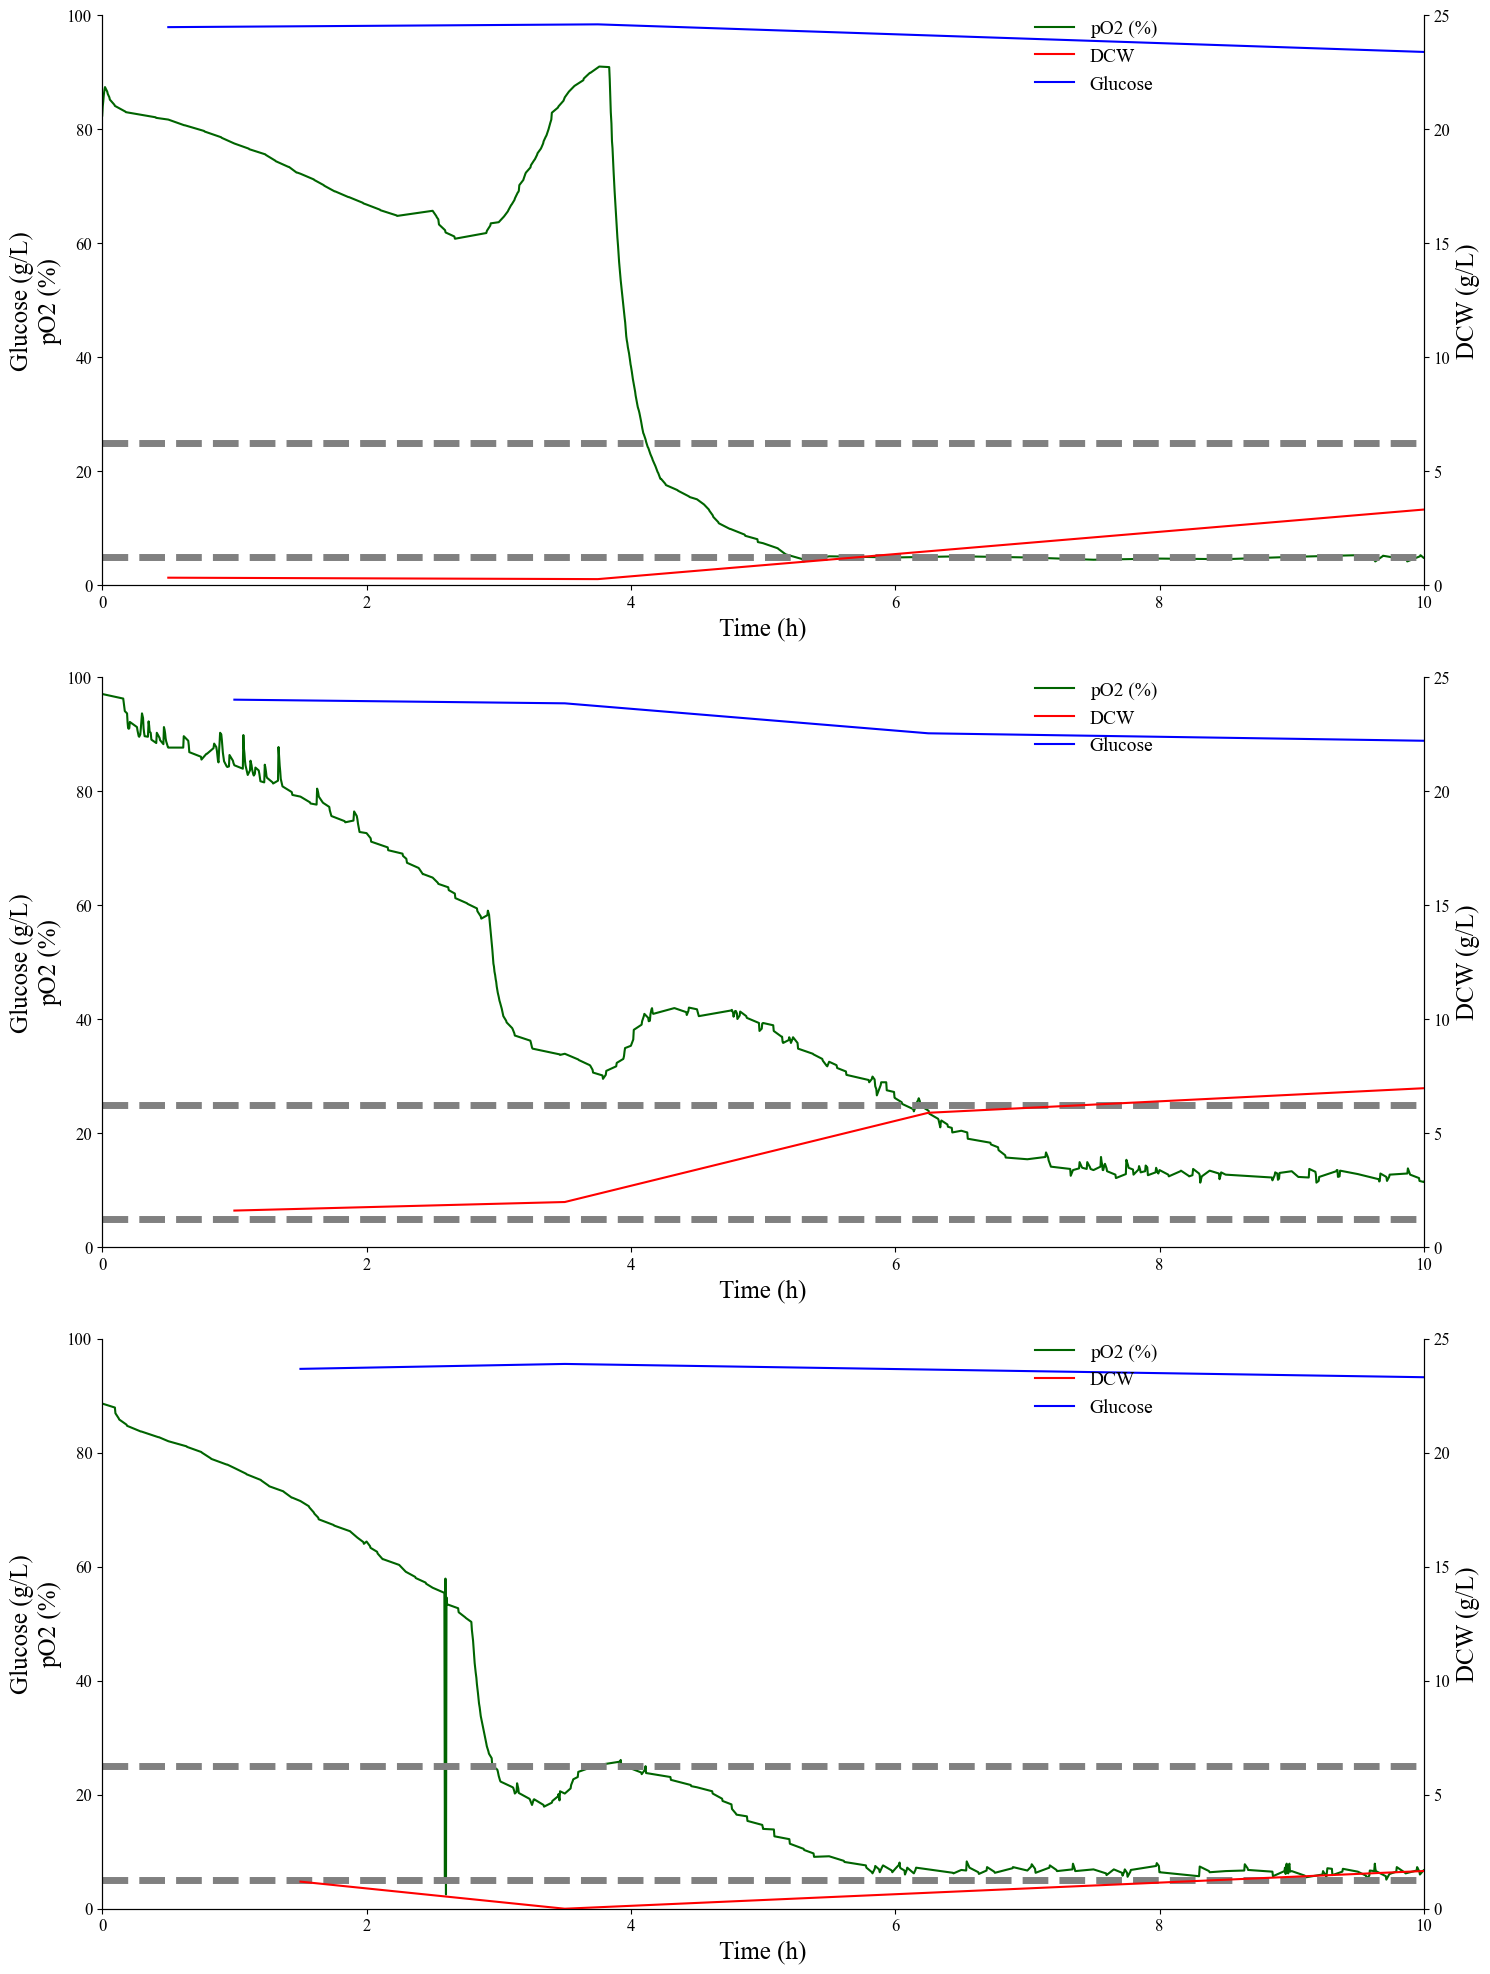

In [237]:

# Create subplots with 3 rows and 1 column
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(15, 20))

# storages = [
#     (Biostat_22_r1, 'Control', 'black', '-'), # control
#     (Biostat_22_r2, '1 min osc', 'blue', '-'), # oscillating
#     (Biostat_23_r1, 'low O2', 'green', '-'),  # pO2 5%   
#     (Biostat_23_r2, 'Biostat 23 r2', 'blue', '-'), # oscillating
#     (Biostat_24_r1, 'Control', 'black', '-'), # control
#     (Biostat_24_r2, '20 sec osc', 'orange', '-'), # 20 sec oscillating
#     (Biostat_26_r1, 'low O2', 'green', '-'), # pO2 5% 
#     (Biostat_26_r2, 'Control', 'black', '-'), # control
#     (Biostat_27_r1, '1 min osc', 'blue', '--'), # oscillating
#     (Biostat_27_r2, 'low O2', 'green', '--'),  # pO2 5% 
# ]


# Storage data 
# The dictionaries below should contain your actual data
storage_data = {
    'Biostat_23_r1': storage_23_r1,
    'Biostat_26_r1': storage_26_r1,
    'Biostat_27_r2': storage_27_r2,

}

biostat_data = {

    'Biostat_23_r1': Biostat_23_r1,
    'Biostat_26_r1': Biostat_26_r1,
    'Biostat_27_r2': Biostat_27_r2,
}

# Values and labels for each plot
values = ['PO2_A_Value', 'PO2_A_Value', 'PO2_A_Value']
x_labels = ['Batch Time (h)', 'Batch Time (h)', 'Batch Time (h)',]
y_labels = ['pO2 (%)', 'pO2 (%)', 'pO2 (%)']
ax_lims = [100, 100, 100]

# Iterate through each subplot data
for idx, (key, storage) in enumerate(storage_data.items()):
    # Plot each subplot
    ax = axs[idx]

    # Plot main data
    lns1 = ax.plot(storage['PO2_A_Value']['age'], storage['PO2_A_Value']['value'], label='pO2 (%)', color='DarkGreen')
    ax.set_ylim(0, 100)
    ax.set_xlim(0, 10)

    # Use corresponding biostat data for secondary axis data
    biostat = biostat_data[key]
    ax_twin = ax.twinx()
    lns2 = ax_twin.plot(biostat['hour'], biostat['DCW (g/L)'], color='red', label='DCW')
    lns3 = ax.plot(biostat['hour'], biostat['Glucose.1'], color='blue', label='Glucose')

    ax.set_xlabel('Time (h)', fontsize=18)
    ax.set_ylabel('Glucose (g/L)\npO2 (%)', fontsize=18)
    ax_twin.set_ylabel('DCW (g/L)', fontsize=18)
    ax_twin.set_ylim(0, 25)

    # Plot horizontal lines
    ax.axhline(y=25, color='Gray', linestyle='--', linewidth=5)
    ax.axhline(y=5, color='Gray', linestyle='--', linewidth=5)

    # Combine all legend entries
    lns = lns1 + lns2 + lns3
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, fontsize=14, loc=(0.7, 0.85), frameon=False)

    # Apply font styles globally
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    ax_twin.tick_params(axis='both', which='major', labelsize=12)
    ax_twin.tick_params(axis='both', which='minor', labelsize=10)

    ax.margins(y=0)
    ax_twin.margins(y=0)
    ax.spines['top'].set_visible(False)
    ax_twin.spines['top'].set_visible(False)

# Adjust spacing between plots and save the figure
plt.tight_layout()
plt.savefig('Biostat_lowo2_complete_zoomed.png')


#### combined, controls.

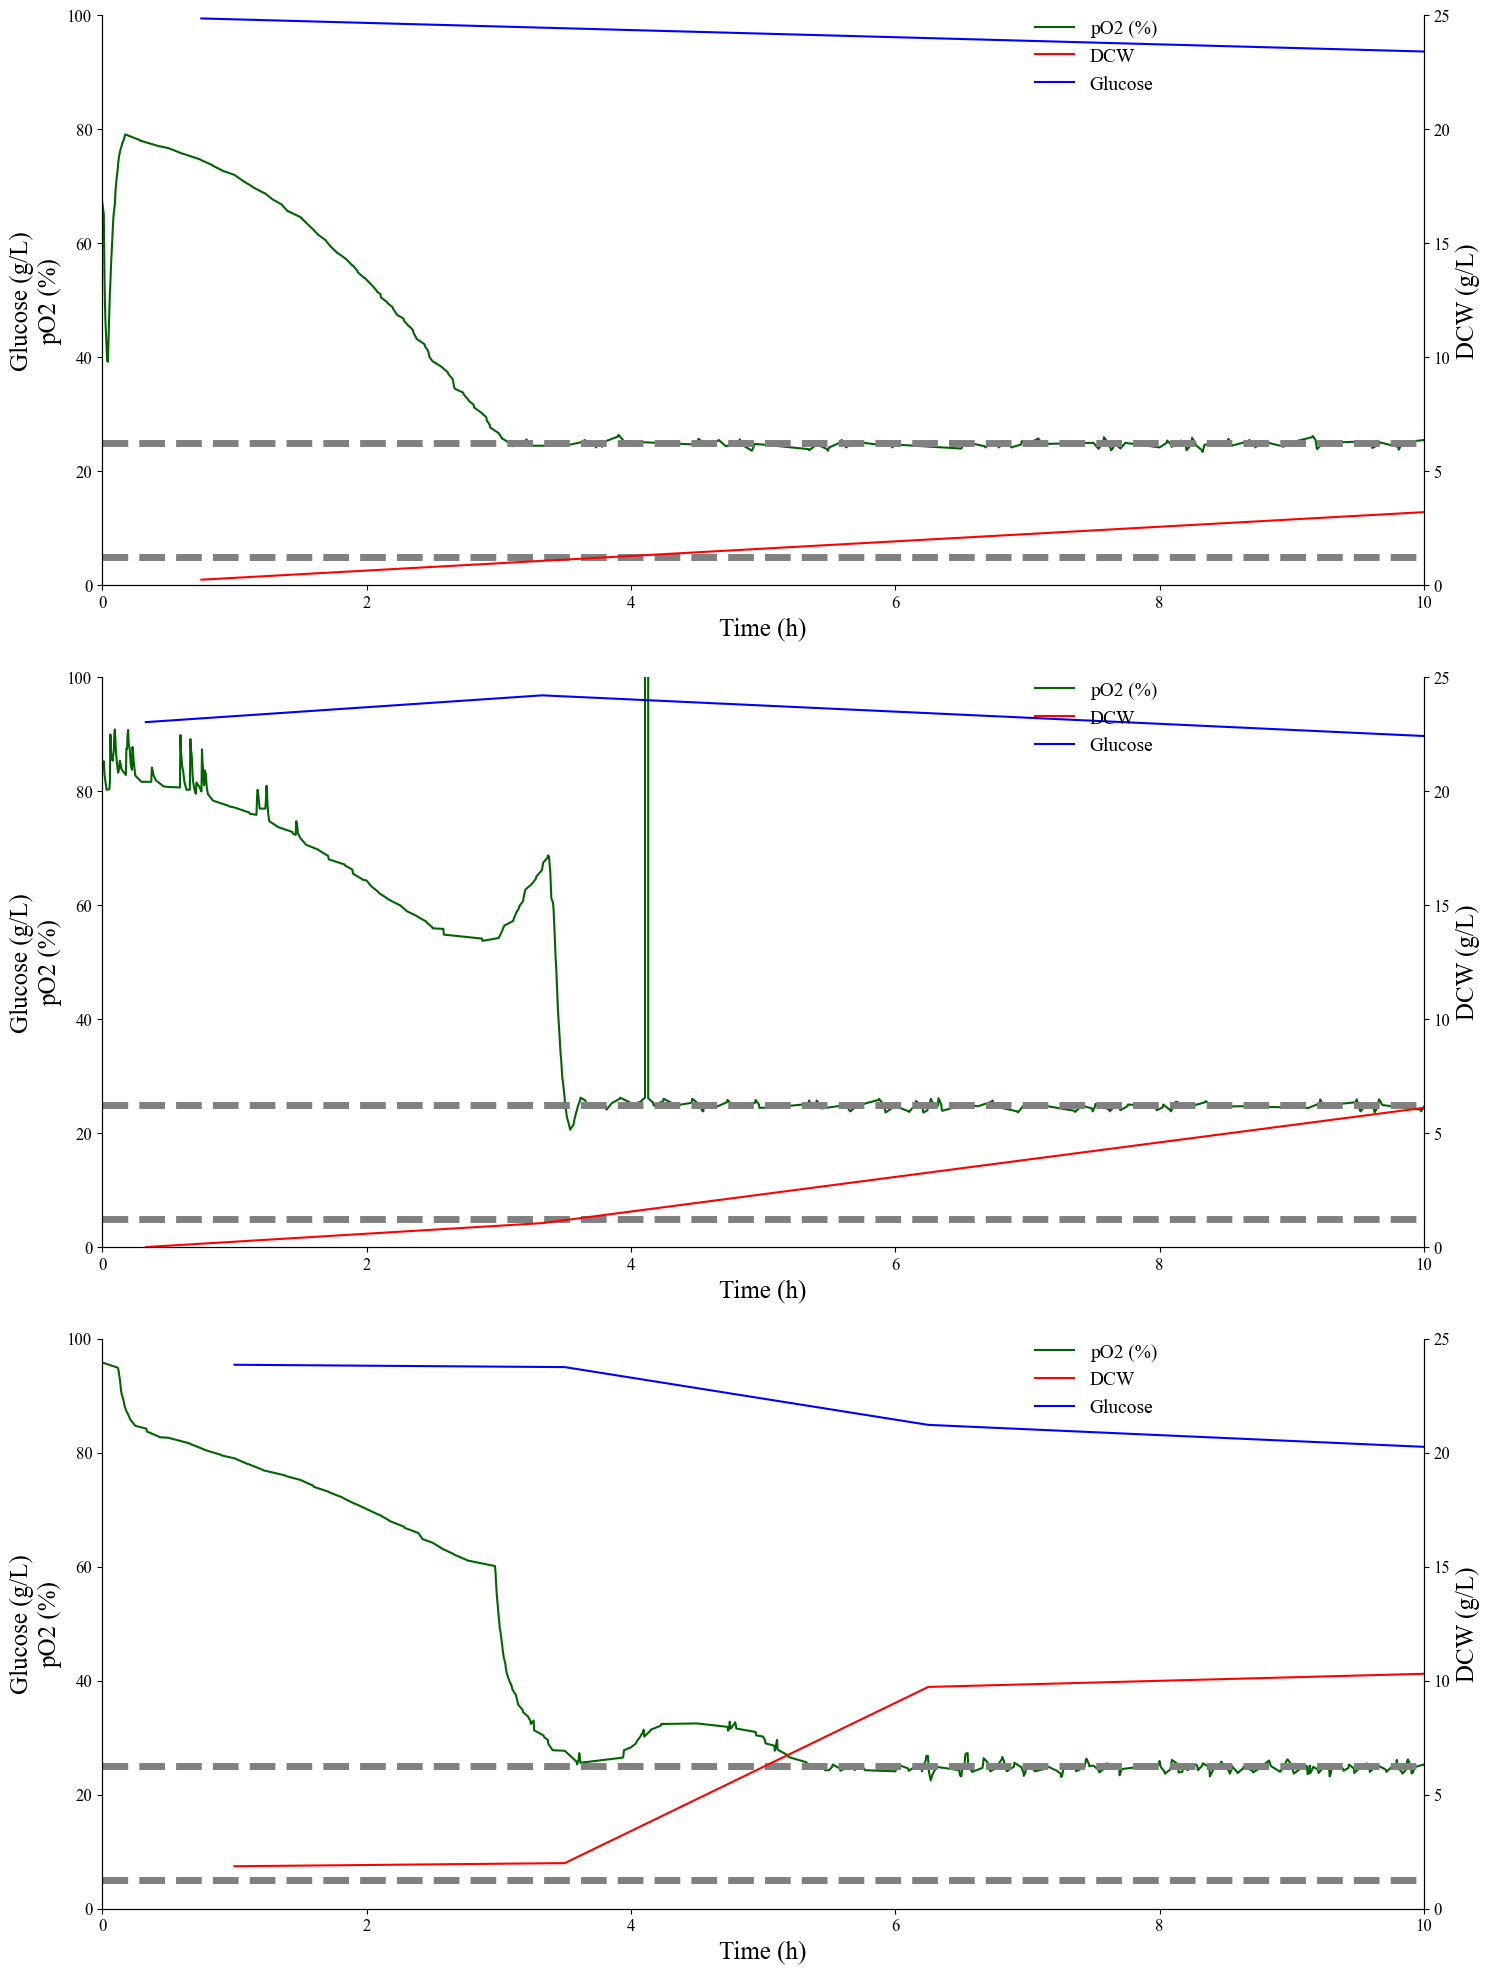

In [239]:

# Create subplots with 3 rows and 1 column
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(15, 20))

# storages = [
#     (Biostat_22_r1, 'Control', 'black', '-'), # control
#     (Biostat_22_r2, '1 min osc', 'blue', '-'), # oscillating
#     (Biostat_23_r1, 'low O2', 'green', '-'),  # pO2 5%   
#     (Biostat_23_r2, 'Biostat 23 r2', 'blue', '-'), # oscillating
#     (Biostat_24_r1, 'Control', 'black', '-'), # control
#     (Biostat_24_r2, '20 sec osc', 'orange', '-'), # 20 sec oscillating
#     (Biostat_26_r1, 'low O2', 'green', '-'), # pO2 5% 
#     (Biostat_26_r2, 'Control', 'black', '-'), # control
#     (Biostat_27_r1, '1 min osc', 'blue', '--'), # oscillating
#     (Biostat_27_r2, 'low O2', 'green', '--'),  # pO2 5% 
# ]


# Storage data 
# The dictionaries below should contain your actual data
storage_data = {
    'Biostat_22_r1': storage_22_r1,
    'Biostat_24_r1': storage_24_r1,
    'Biostat_26_r2': storage_26_r2,

}

biostat_data = {

    'Biostat_22_r1': Biostat_22_r1,
    'Biostat_24_r1': Biostat_24_r1,
    'Biostat_26_r2': Biostat_26_r2,
}

# Values and labels for each plot
values = ['PO2_A_Value', 'PO2_A_Value', 'PO2_A_Value']
x_labels = ['Batch Time (h)', 'Batch Time (h)', 'Batch Time (h)',]
y_labels = ['pO2 (%)', 'pO2 (%)', 'pO2 (%)']
ax_lims = [100, 100, 100]

# Iterate through each subplot data
for idx, (key, storage) in enumerate(storage_data.items()):
    # Plot each subplot
    ax = axs[idx]

    # Plot main data
    lns1 = ax.plot(storage['PO2_A_Value']['age'], storage['PO2_A_Value']['value'], label='pO2 (%)', color='DarkGreen')
    ax.set_ylim(0, 100)
    ax.set_xlim(0, 10)

    # Use corresponding biostat data for secondary axis data
    biostat = biostat_data[key]
    ax_twin = ax.twinx()
    lns2 = ax_twin.plot(biostat['hour'], biostat['DCW (g/L)'], color='red', label='DCW')
    lns3 = ax.plot(biostat['hour'], biostat['Glucose.1'], color='blue', label='Glucose')

    ax.set_xlabel('Time (h)', fontsize=18)
    ax.set_ylabel('Glucose (g/L)\npO2 (%)', fontsize=18)
    ax_twin.set_ylabel('DCW (g/L)', fontsize=18)
    ax_twin.set_ylim(0, 25)

    # Plot horizontal lines
    ax.axhline(y=25, color='Gray', linestyle='--', linewidth=5)
    ax.axhline(y=5, color='Gray', linestyle='--', linewidth=5)

    # Combine all legend entries
    lns = lns1 + lns2 + lns3
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, fontsize=14, loc=(0.7, 0.85), frameon=False)

    # Apply font styles globally
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    ax_twin.tick_params(axis='both', which='major', labelsize=12)
    ax_twin.tick_params(axis='both', which='minor', labelsize=10)

    ax.margins(y=0)
    ax_twin.margins(y=0)
    ax.spines['top'].set_visible(False)
    ax_twin.spines['top'].set_visible(False)

# Adjust spacing between plots and save the figure
plt.tight_layout()
plt.savefig('Biostat_control_complete_zoomed.png')


## Omic Runs.

### OfflineData

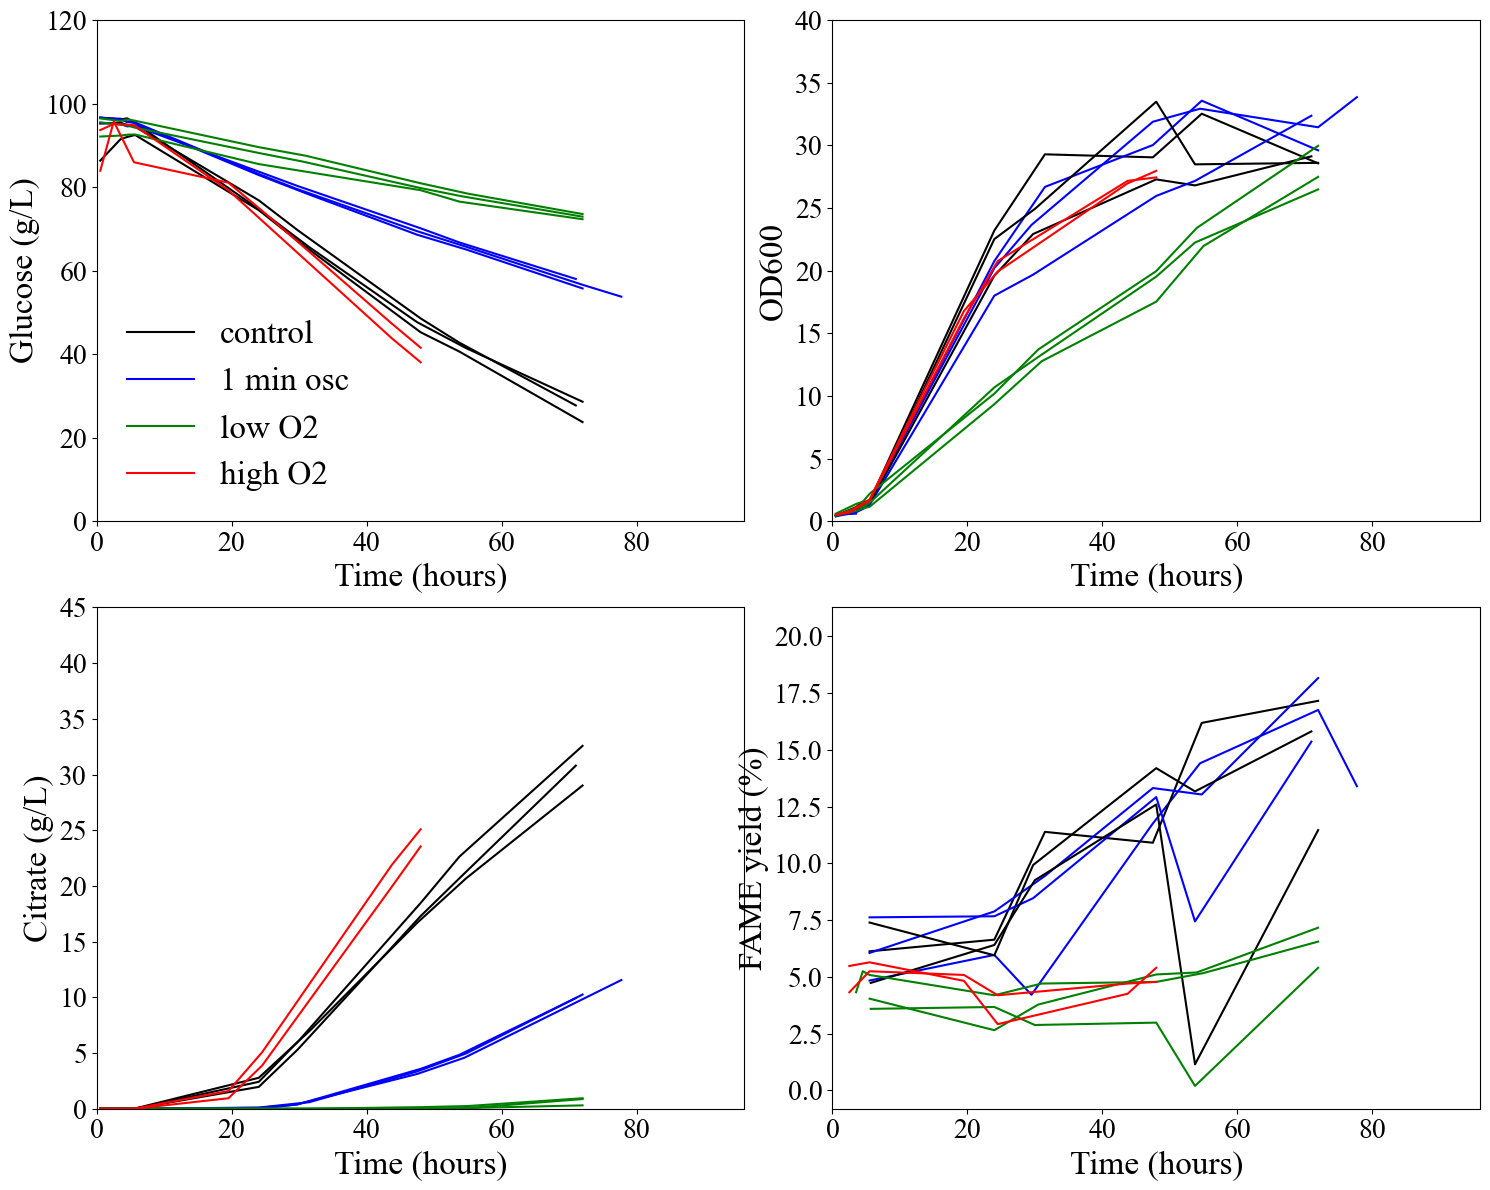

In [40]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # low O2 #4
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # low O2 #5
    (Biostat_35_r1, 'High O2', 'red', '-'), # low O2 #4
    (Biostat_35_r2, 'High O2', 'red', '-'),  # low O2 #5
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    ('OD600', 'OD600', (0, 40)),

    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
    # ('citrate yield', 'Citrate yield (g/gCarbon)', (0, 1)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)



# # Define the datasets and their labels and plotting styles

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'green', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
    (Biostat_35_r1, 'high O2', 'red', '-'), # oscillating
    (Biostat_35_r2, 'high O2', 'red', '-'),  # pO2 5% 
]
# # Add the FAME yield data to the last subplot
idx_fame = 3  # this is the index for the last subplot
for store, label, color, linestyle in storages:
    if fame_yield_col in store:
        # axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
        if "Biostat_23_r2" in label:
            axs[idx_fame].plot(store['hour'][:-1], store[fame_yield_col][:-1] * 100, label=label, color=color, linestyle=linestyle)
        elif "Biostat_22_r2" in label:
            axs[idx_fame].plot(store['hour'].iloc[2:], store[fame_yield_col].iloc[2:] * 100, label=label, color=color, linestyle=linestyle)
        else:
            axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
axs[idx_fame].set_xlim(0, 96)
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['control', '1 min osc', 'low O2', 'high O2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
plt.savefig('Biostat_omicsPhenotypeComparison2.png')
plt.show()


#### rates/yields 

In [41]:
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    (Biostat_33_r2, 'low O2', 'green', '-'),  # low O2 ##
    (Biostat_34_r1, 'low O2', 'green', '-'), # low O2 #3
    (Biostat_34_r2, 'low O2', 'green', '-'),  # low O2 ##
    (Biostat_35_r1, 'high O2', 'red', '-'), # high O2
    (Biostat_35_r2, 'high O2', 'red', '-'),  # high O2 
]
plot_pairs = [
    # ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    # ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
]

DCWstore = []
for y_col, y_label, y_lim in plot_pairs:
    for store, label, color, linestyle in storages:
        
        DCWstore.append(store['DCW (g/L)'] / store['OD600'])

In [42]:
for store, label, color, linestyle in storages:


    # Calculate rates using log difference and time difference
    log_diff_DCW = np.log(store['DCW (g/L)'].iloc[1:].values) - np.log(store['DCW (g/L)'].iloc[:-1].values)
    log_diff_OD = np.log(store['OD600'].iloc[1:].values) - np.log(store['OD600'].iloc[:-1].values)

    
    FAME_diff = store['FAME titer (g/L)'].iloc[1:].values - store['FAME titer (g/L)'].iloc[:-1].values
        
    
    time_diff = store['hour'].iloc[1:].values - store['hour'].iloc[:-1].values
    
    
    rates_DCW = log_diff_DCW / time_diff
    # rates_DCW = np.insert(rates_DCW, 0, np.nan) # insert 0 at beginning.
    rates_DCW = np.append(rates_DCW, np.nan) # insert 0 at end. 

    rates_OD = log_diff_OD / time_diff
    # rates_OD = np.insert(rates_OD, 0, np.nan)
    rates_OD = np.append(rates_OD, np.nan) # insert 0 at end. 

    
    FAME_specific_rate = FAME_diff/time_diff
    FAME_specific_rate = np.append(FAME_specific_rate, np.nan)
    
    
    
    store['specific_µ_DCW'] = rates_DCW
    store['specific_µ_OD'] = rates_OD
    store['specific_FAME_rate (g/L/h)'] = FAME_specific_rate


    
    # print(label)
    # print(rates_OD, rates_DCW)
    # DCWstore.append(store['DCW (g/L)']/store['OD600'])

plot rates/yields. 

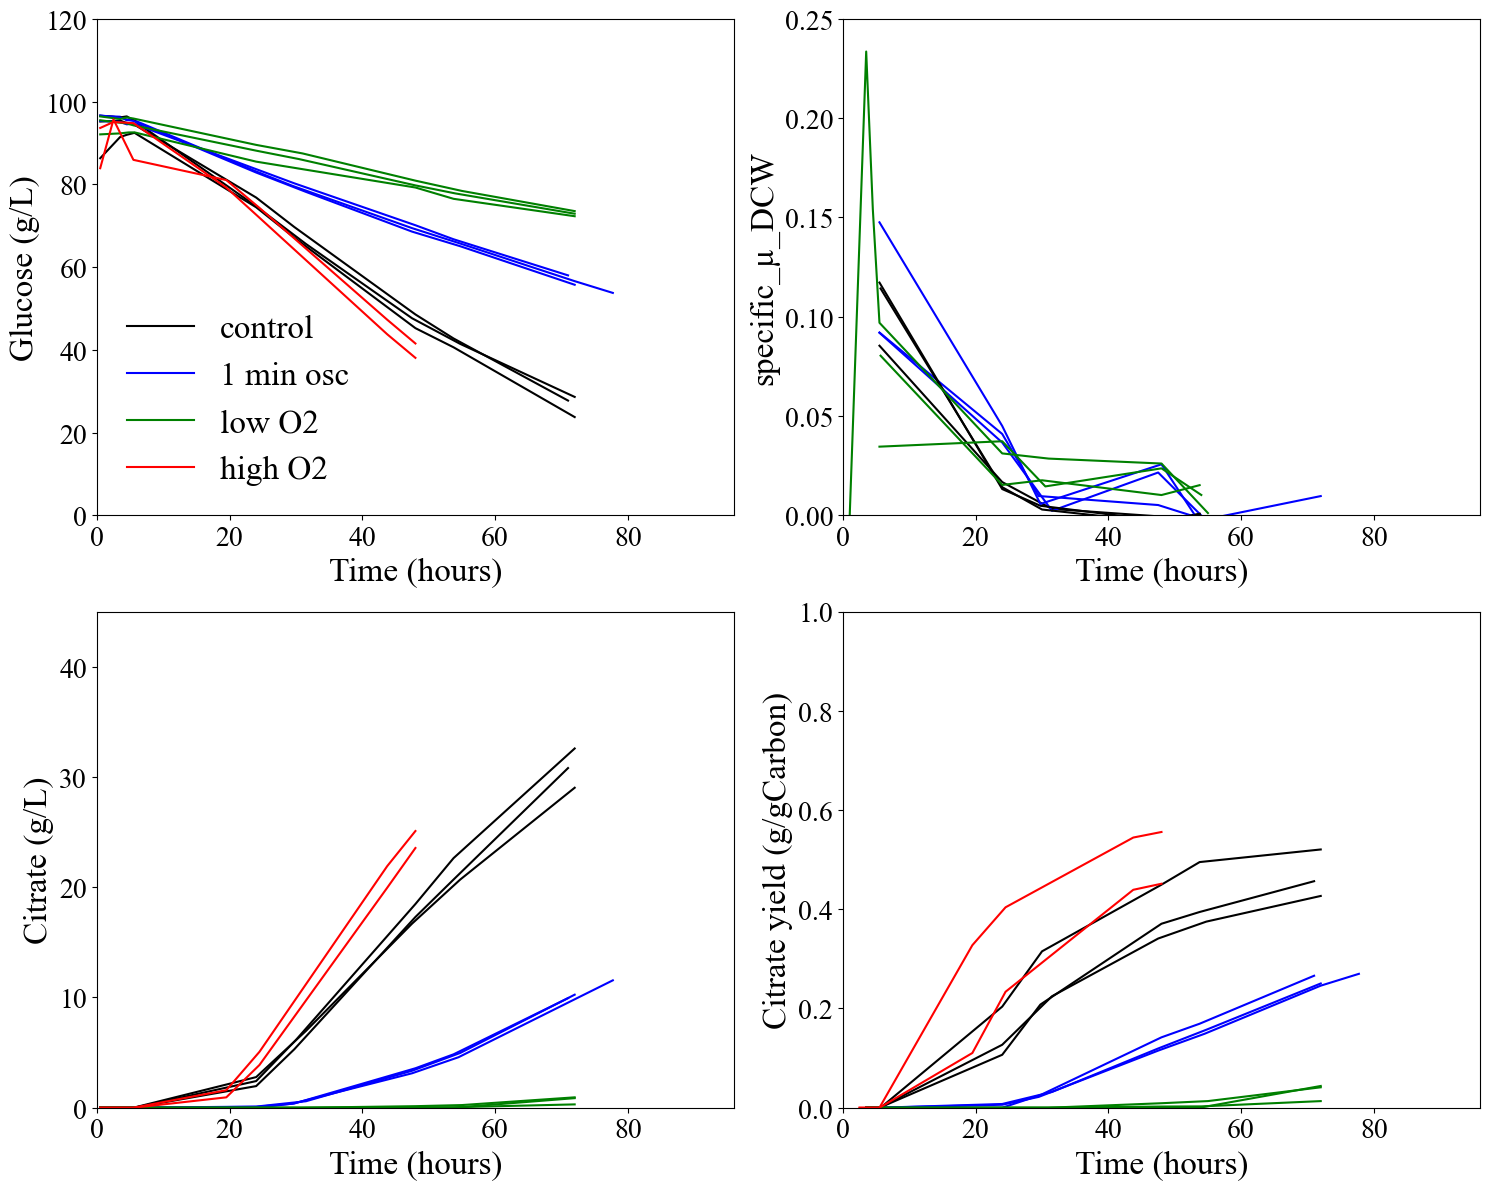

In [43]:
## plot rates/yields
fig, axs = plt.subplots(2, 2, figsize=(15, 12))


storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'green', '-'),  # low O2 ##
    (Biostat_34_r1, 'low O2', 'green', '-'), # low O2 #3
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # low O2 ##
    (Biostat_35_r1, 'high O2', 'red', '-'), # high O2
    (Biostat_35_r2, 'high O2', 'red', '-'),  # high O2 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    ('specific_µ_DCW', 'specific_µ_DCW', (0, .25)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
    ('citrate yield', 'Citrate yield (g/gCarbon)', (0, 1)),
    # ('specific citrate yield (g/g substrate)', 'Citrate yield (g/gCarbon)', (0, .2)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()


combined_data = []

# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        
        axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)


        temp_df = store[['hour', y_col]].copy()
        temp_df['variable'] = y_label
        temp_df['condition'] = label
        
        combined_data.append(temp_df)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)

custom_labels = ['control', '1 min osc', 'low O2', 'high O2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
# plt.savefig('Biostat_omicsPhenotypeComparison.png')
plt.show()


In [44]:
combined_df = pd.concat(combined_data, ignore_index=True)


wide_df = combined_df.pivot_table(
    index=['hour', 'condition'],
    columns='variable',
    values=combined_df.columns[1]  # auto-detect value column
)

In [45]:
combined_df[(combined_df['hour']>70) & (combined_df['variable']=='Citrate (g/L)')]

,hour,Glucose.1,variable,condition,specific_µ_DCW,Citric Acid.1,citrate yield
200,72.00,NaN,Citrate (g/L),1 min osc,NaN,9.8320,NaN
201,77.75,NaN,Citrate (g/L),1 min osc,NaN,11.5524,NaN
210,72.00,NaN,Citrate (g/L),Control,NaN,29.0174,NaN
219,72.00,NaN,Citrate (g/L),1 min osc,NaN,10.2517,NaN
228,71.00,NaN,Citrate (g/L),Control,NaN,30.8017,NaN
237,71.00,NaN,Citrate (g/L),1 min osc,NaN,9.9347,NaN
246,72.00,NaN,Citrate (g/L),Control,NaN,32.5777,NaN
255,72.00,NaN,Citrate (g/L),low O2,NaN,0.8676,NaN
264,72.00,NaN,Citrate (g/L),low O2,NaN,0.3014,NaN
273,72.00,NaN,Citrate (g/L),low O2,NaN,0.9420,NaN


### Combine DataFrames For modelers"

#### definition for incyte data first. 

In [61]:
def compute_average_for_columns(df, target_hour, columns, neighbor_count=25):
    df = df.reset_index(drop=True)

    
    # Find the closest index in the target DataFrame for the target_hour
    closest_idx = (df['Time (h)'] - target_hour).abs().idxmin()

    # Compute start and end indices for averaging
    start_idx = max(0, closest_idx - neighbor_count)
    end_idx = min(len(df), closest_idx + neighbor_count)

    # Compute averages for all specified columns
    averages = {}
    for column in columns:
        # Ensure the subset is valid and avoid slicing errors
        subset = df[column].iloc[start_idx:end_idx]  
        averages[column] = subset.mean() if not subset.empty else float('nan')
    return averages


In [62]:
storages_combined = [
    (Biostat_29_r2, '1 min osc', 'blue', '-', IncyteData_29_r2),
    # (Biostat_30_r1, 'Control', 'black', '-', IncyteData_30_r1),
    # (Biostat_30_r2, '1 min osc', 'blue', '-', IncyteData_30_r2),
    (Biostat_31_r1, 'Control', 'black', '-', IncyteData_31_r1),
    (Biostat_31_r2, '1 min osc', 'blue', '-', IncyteData_31_r2),
    (Biostat_32_r1, 'Control', 'black', '-', IncyteData_32_r1),
    (Biostat_32_r2, 'low O2', 'green', '-', IncyteData_32_r2),
    (Biostat_33_r1, 'low O2', 'green', '-', IncyteData_33_r1),
    # (Biostat_33_r2, 'low O2', 'green', '-', IncyteData_33_r2),
    (Biostat_34_r1, 'low O2', 'green', '-', IncyteData_34_r1),
    # (Biostat_34_r2, 'low O2', 'green', '-', IncyteData_34_r2),
]

In [63]:
# Iterate through each tuple in storages_combined
columns_to_compute = ['fc(kHz)', 'Cell Density(pF/cm)', 'Conductivity(mS/cm)', 'Permittivity(pF/cm)', 'DeltaEps(pF/cm)','Alpha']
for biostat_df, label, color, linestyle, incyte_data in storages_combined:
    # Initialize a dictionary to hold lists of computed average values for each column
    average_values_by_column = {column: [] for column in columns_to_compute}
    # print(label)
    for hour_value in biostat_df['hour']:
        # print(hour_value)
        # Compute averages for the target hour and specified columns
        averages = compute_average_for_columns(incyte_data, hour_value, columns_to_compute,neighbor_count=10)
        
        # Append computed averages to the lists for each column
        for column, avg_value in averages.items():
            average_values_by_column[column].append(avg_value)
    
    # Update the biostat_df with the computed average values for each target column
    for column, values in average_values_by_column.items():
        biostat_df[column] = values

### OUR/CER next. 

In [64]:
# Compute average for a given time series around specified index
def compute_average_for_series(series, target_hour, neighbor_count=10):
    # Reset series index for clean operation
    series = series.reset_index(drop=False)
    
    # Find closest index for the target hour
    closest_idx = (series['age'] - target_hour).abs().idxmin()

    # Calculate boundaries
    start_idx = max(0, closest_idx - neighbor_count)
    end_idx = min(len(series), closest_idx + neighbor_count + 1)

    # Calculate and return mean from subset
    subset = series.iloc[start_idx:end_idx]
    return subset.mean() if not subset.empty else float('nan')

In [65]:
# include the off gas. 
storages_combined = [
    (Biostat_29_r2, '1 min osc', 'blue', 'r2', df_29),
    (Biostat_30_r1, 'Control', 'black', 'r1', df_30),
    (Biostat_30_r2, '1 min osc', 'blue', 'r2', df_30),
    (Biostat_31_r1, 'Control', 'black', 'r1', df_31),
    (Biostat_31_r2, '1 min osc', 'blue', 'r2', df_31),
    (Biostat_32_r1, 'Control', 'black', 'r1', df_32),
    (Biostat_32_r2, 'low O2', 'green', 'r2', df_32),
    (Biostat_33_r1, 'low O2', 'green', 'r1', df_33),
    # (Biostat_33_r2, 'low O2', 'green', 'r2', IncyteData_33_r2),
    (Biostat_34_r1, 'low O2', 'green', 'r1', df_34),
    # (Biostat_34_r2, 'low O2', 'green', '-', df_34),
]

#
columns_to_compute = ['fc(kHz)', 'Cell Density(pF/cm)', 'Conductivity(mS/cm)', 'Permittivity(pF/cm)', 'DeltaEps(pF/cm)','Alpha']


# iterate through off gas. 
for biostat_df, label, color, vessel, offgas_data in storages_combined:

    # check vessel for appropriate gas indexing. 
    if vessel == 'r2':
        x_our = offgas_data[('Fermenter02', 'BDCU-2', 'OUR', 'g/h')]*1000/(32*1.5)
        x_cer = offgas_data[('Fermenter02', 'BDCU-2', 'CER', 'g/h')]*1000/(48*1.5)

        ## difficult calculating OUR/CER with no air in for balance purposes. 
        # drop oscillating instances when nitrogen is coming in. 
        if 'osc' in label:
            # Drop rows where F_in2 is zero
            valid_rows = offgas_data[('Fermenter02', 'BDCU-2', 'F_in2', 'LPM')] >= .375
            x_our = x_our.loc[valid_rows]  # Only select rows where F_in2 is not zero   
            x_cer = x_cer.loc[valid_rows]  # Only select rows where F_in2 is not zero   

    
    elif vessel == 'r1':
        x_our = offgas_data[('Fermenter01', 'BDCU-1', 'OUR', 'g/h')]*1000/(32*1.5)
        x_cer = offgas_data[('Fermenter01', 'BDCU-1', 'CER', 'g/h')]*1000/(48*1.5)


        ## difficult calculating OUR/CER with no air in for balance purposes. 
        # drop oscillating instances when nitrogen is coming in. 
        if 'osc' in label:
            # Drop rows where F_in2 is zero
            valid_rows = offgas_data[('Fermenter01', 'BDCU-1', 'F_in1', 'LPM')] >= .375
            x_our = x_our.loc[valid_rows]  # Only select rows where F_in2 is not zero   
            x_cer = x_cer.loc[valid_rows]  # Only select rows where F_in2 is not zero   

    
    # Compute averages for OUR and CER
    averages_our = []
    averages_cer = []


    
    for hour_value in biostat_df['hour']:
        avg_our = compute_average_for_series(x_our, hour_value, neighbor_count=5)
        avg_cer = compute_average_for_series(x_cer, hour_value, neighbor_count=5)
        
        averages_our.append(avg_our.values[1])
        averages_cer.append(avg_cer.values[1])


    # Update biostat DataFrame with calculated averages
    biostat_df['average_our'] = averages_our
    biostat_df['average_cer'] = averages_cer


In [66]:
Biostat_31_r1

,Unnamed: 14,date,time,hour,reactor,sample number,sample volume (mL),moxiflow D (µm),OD600,BASE (mL),...,specific_µ_OD,specific_FAME_rate (g/L/h),fc(kHz),Cell Density(pF/cm),Conductivity(mS/cm),Permittivity(pF/cm),DeltaEps(pF/cm),Alpha,average_our,average_cer
0,NaN,2025-01-21,09:45:00,0.50,r1,1.0,8.0,-,0.435,0.0,...,0.230282,NaN,1399.292493,-0.324262,4.703582,0.973691,1.288661,0.101258,-0.227103,0.668392
2,NaN,NaT,12:45:00,3.50,r1,3.0,8.0,-,0.868,1.0,...,0.236874,NaN,1786.927979,-0.053754,4.646231,1.244033,1.569340,0.101735,-2.454118,2.719696
4,NaN,NaT,13:45:00,4.50,r1,5.0,8.0,-,1.100,1.0,...,0.233994,NaN,1869.859985,0.212769,4.473820,1.511340,1.792730,0.101439,-2.374020,3.115345
6,NaN,NaT,14:45:00,5.50,r1,7.0,8.0,-,1.390,2.0,...,0.143039,0.031961,1884.670044,0.473110,4.469680,1.771680,2.084480,0.102267,-2.925892,3.644653
8,NaN,2025-01-22,09:15:00,24.00,r1,9.0,8.0,NaN,19.600,37.0,...,0.027214,0.095938,1629.981000,4.029963,3.826312,5.329225,7.419456,0.127330,-10.292716,9.056384
10,NaN,NaT,15:00:00,29.75,r1,11.0,8.0,NaN,22.920,62.0,...,0.009542,0.038079,1583.449017,4.815768,3.930689,6.118913,8.232499,0.129335,-10.136020,7.374398
12,NaN,2025-01-23,09:15:00,48.00,r1,13.0,8.0,NaN,27.280,159.0,...,-0.003087,-0.029471,1637.844489,5.380998,6.105211,6.686352,8.807052,0.113025,-9.034566,5.138857
14,NaN,NaT,15:00:00,53.75,r1,15.0,8.0,NaN,26.800,190.0,...,0.004813,0.022161,1720.826489,5.289934,7.056893,6.597975,9.011046,0.122718,-8.238370,4.465297
16,NaN,2025-01-24,08:15:00,71.00,r1,17.0,8.0,NaN,29.120,283.0,...,NaN,NaN,1807.135486,5.226096,10.443030,6.533414,8.579816,0.119793,-7.300385,3.834796


## tesst oscillating OUR. 

In [67]:
def calculate_pO2_trends(df_po2):
    # grab air data and time of fermentation. 
    df_po2 = pd.DataFrame({
        'age': store['PO2_A_Value']['age'],
        'value': store['PO2_A_Value']['value']
    })

    # calculate differences between pO2 points - note, the recording is not always 100% accurate. 
    df_po2['difference'] = df_po2['value'].diff()

    # note the trend, when there is a sign shift. 
    df_po2['trend_change'] = np.sign(df_po2['difference']) != np.sign(df_po2['difference'].shift())

    # grab index of when they shift signs. 
    trend_change_points = df_po2[df_po2['trend_change']].index


    
    # Initialize lists to store information.
    original_ages = []
    original_values = []
    value_differences = []
    age_differences = []
    
    # Calculate differences between consecutive trend change points.
    for idx in range(len(trend_change_points) - 1):
       
        t1_idx = trend_change_points[idx]
        t2_idx = trend_change_points[idx + 1]
    
        # append the time.
        original_ages.append(df_po2.loc[t1_idx, 'age'])

        # append the pO2. 
        original_values.append(df_po2.loc[t1_idx, 'value'])

        # calculate and append the change in time and pO2. 
        value_difference = df_po2.loc[t2_idx, 'value'] - df_po2.loc[t1_idx, 'value']
        age_difference = df_po2.loc[t2_idx, 'age'] - df_po2.loc[t1_idx, 'age']
    
        value_differences.append(value_difference)
        age_differences.append(age_difference)
    
    # Create new DataFrame with the extracted information.
    df_trend_changes = pd.DataFrame({
        'age': original_ages,
        'original_value': original_values,
        'value_difference': value_differences,
        'age_difference': age_differences
    })

    return (df_trend_changes)


In [68]:
def calculate_our_offgas_oscillate(df):
    
    # constants
    R = 8.314472 # [J /mol/K]
    mw_co2 = 44 # g/mol
    mw_o2 = 32 # g/mol
    df_po2 = pd.DataFrame({
        'age': df['temp_age_continue'],
        'yO2_out': df[('Fermenter02', 'BDCU-2', 'CH1-O2', 'Vol %')],
        'temp': df[('Fermenter02','BDCU-2','Temperature','°C')]+273.15, # in K
        'pres': df[('Fermenter02','BDCU-2','Pressure','bar')]*100 # kPa
    })
    df_po2['yO2_change'] = 20.95 - df_po2['yO2_out']
    df_po2['O2change'] = df_po2['yO2_change']/100*1.125*df_po2['pres']*mw_o2/(R*df_po2['temp'])
    df_po2['OUR (mmol/Lh)']= df_po2['O2change']*1000/(32*1.5)*-1

    return(df_po2)

In [69]:
oscillating_storages = [
    (Biostat_29_r2, '1 min osc', 'blue', 'r2',storage_29_r2, df_29),
    (Biostat_30_r1, 'Control', 'black', 'r1', storage_30_r1, df_30),
    (Biostat_30_r2, '1 min osc', 'blue', 'r2',storage_30_r2, df_30),
    (Biostat_31_r1, 'Control', 'black', 'r1', storage_31_r1, df_31),
    (Biostat_31_r2, '1 min osc', 'blue', 'r2', storage_31_r2, df_31),
    (Biostat_32_r1, 'Control', 'black', 'r1', storage_32_r1, df_32),
    (Biostat_32_r2, 'low O2', 'green', 'r2', storage_32_r2,df_32),
    (Biostat_33_r1, 'low O2', 'green', 'r1', storage_33_r1,df_33),
    # (Biostat_33_r2, 'low O2', 'green', 'r2', IncyteData_33_r2),
    (Biostat_34_r1, 'low O2', 'green', 'r1',storage_34_r1, df_34),
    # (Biostat_34_r2, 'low O2', 'green', '-', df_34),
]

In [70]:

# oscillating_storages = [
#     (Biostat_29_r2, '1 min osc', 'blue', 'r2', storage_29_r2, df_29),
#     (Biostat_30_r2, '1 min osc', 'blue', 'r2', storage_30_r2, df_30),
#     (Biostat_31_r2, '1 min osc', 'blue', 'r2', storage_31_r2, df_31),
# ]
oscillating_storages = [
    (Biostat_29_r2, '1 min osc', 'blue', 'r2',storage_29_r2, df_29),
    # (Biostat_30_r1, 'Control', 'black', 'r1', storage_30_r1, df_30),
    (Biostat_30_r2, '1 min osc', 'blue', 'r2',storage_30_r2, df_30),
    # (Biostat_31_r1, 'Control', 'black', 'r1', storage_31_r1, df_31),
    (Biostat_31_r2, '1 min osc', 'blue', 'r2', storage_31_r2, df_31),
    # (Biostat_32_r1, 'Control', 'black', 'r1', storage_32_r1, df_32),
    # (Biostat_32_r2, 'low O2', 'green', 'r2', storage_32_r2,df_32),
    # (Biostat_33_r1, 'low O2', 'green', 'r1', storage_33_r1,df_33),
    # (Biostat_33_r2, 'low O2', 'green', 'r2', IncyteData_33_r2),
    # (Biostat_34_r1, 'low O2', 'green', 'r1',storage_34_r1, df_34),
    # (Biostat_34_r2, 'low O2', 'green', '-', df_34),
]
kLa = 100 # assumed for oscillating condition. 

test_trend = pd.DataFrame()
for biostat_df, label, color, vessel, store, offgas in oscillating_storages:
    
    # calculate o2 change from gas. 
    df_our_offgas = calculate_our_offgas_oscillate(offgas)
    
    # calculate o2 change due to liquid. 
    df_trend = calculate_pO2_trends(store)

    # calculate OURs. 
    test_trend = df_trend[df_trend['age']>0]

    test_trend = test_trend.apply(pd.to_numeric, errors='coerce')

    
    # test_trend['Kla*[O2_star-[averageO2]]'] = 100*(100-(test_trend['value_difference'])/2) # %/h

    # convert to g/h. 7.54 mg/L is assumed saturation of O2 at 30C. 
    test_trend['Kla*[O2_star-[averageO2]]'] = kLa*(7.54-(test_trend['value_difference'])*7.54/2)/1000 # g/h

    # full OUR calculation
    # test_trend['OUR'] = test_trend['value_difference']*7.54/1000-test_trend['Kla*[O2_star-[averageO2]]']

    test_trend['OUR'] = test_trend['value_difference']*7.54/1000#-test_trend['Kla*[O2_star-[averageO2]]']

    
    test_trend['OUR (mmol/Lh)'] = test_trend['OUR']*1000/(32*1.5)

    test_trend = test_trend[test_trend['OUR']<0]

    x_our = test_trend['OUR (mmol/Lh)']
    x_our.index = test_trend['age']

    # recalculating OUR from offgas. 
    x_our_offgas = df_our_offgas['OUR (mmol/Lh)']
    x_our_offgas.index = df_our_offgas['age']
   
    # # Compute averages for OUR and CER
    averages_our = []
    averages_our_offgas = []
    averages_calc = []
    # for calculating averages. 
    
    for hour_value in biostat_df['hour']:
        avg_our = compute_average_for_series(x_our, hour_value, neighbor_count=5)
        avg_our_offgas_series = compute_average_for_series(x_our_offgas, hour_value, neighbor_count=5)

        
        averages_our.append(avg_our.values[1])
        averages_our_offgas.append(avg_our_offgas_series.values[1])
        averages_calc.append(avg_our_offgas_series.values[1]+avg_our.values[1])
    
    # # Update biostat DataFrame with calculated averages

    #
    
    # biostat_df['average_our_airflow'] = averages_our
    
    # biostat_df['average_our_offgas'] = averages_our_offgas

    # # biostat_df['average_cer'] = averages_cer

    # biostat_df['average_our_new'] =  biostat_df['average_our_offgas'] + biostat_df['average_our_airflow']
    biostat_df['average_our'] = averages_calc

In [71]:
biostat_df

,Unnamed: 14,date,time,hour,reactor,sample number,sample volume (mL),moxiflow D (µm),OD600,BASE (mL),...,specific_µ_OD,specific_FAME_rate (g/L/h),fc(kHz),Cell Density(pF/cm),Conductivity(mS/cm),Permittivity(pF/cm),DeltaEps(pF/cm),Alpha,average_our,average_cer
1,NaN,NaT,NaN,0.50,r2,2.0,8.0,-,0.390,0.0,...,0.202511,NaN,482.055251,0.185345,4.809594,0.272560,0.251870,0.100565,-1.090387,0.717018
3,NaN,NaT,NaN,3.50,r2,4.0,8.0,-,0.716,0.0,...,0.307731,NaN,2100.103003,0.486700,4.749256,0.573319,0.651599,0.098390,-1.421895,2.807175
5,NaN,NaT,NaN,4.50,r2,6.0,8.0,-,0.974,1.0,...,0.277881,NaN,2543.355029,0.577977,4.708655,0.665025,0.883563,0.105998,-6.295148,2.636458
7,NaN,NaT,NaN,5.50,r2,8.0,8.0,NaN,1.286,1.0,...,0.142640,0.031207,2129.868018,0.713157,4.665035,0.800170,1.021146,0.106047,-6.724480,3.078952
9,NaN,NaT,NaN,24.00,r2,10.0,8.0,NaN,18.000,16.0,...,0.015518,0.046115,1305.983478,5.552153,4.928499,5.639887,11.870725,0.187142,-6.005932,7.324264
11,NaN,NaT,NaN,29.75,r2,12.0,8.0,NaN,19.680,19.0,...,0.015176,0.033499,1216.109985,5.674490,6.890480,5.761620,11.728500,0.165289,-7.071850,5.920899
13,NaN,NaT,NaN,48.00,r2,14.0,8.0,NaN,25.960,40.0,...,0.007859,-0.086384,1283.930054,4.671310,14.538100,4.758450,9.536220,0.142391,-6.469812,4.326100
15,NaN,NaT,NaN,53.75,r2,16.0,8.0,NaN,27.160,49.0,...,0.010155,0.054307,1285.228510,4.409822,16.548079,4.498390,9.167496,0.141913,-6.290759,3.651626
17,NaN,NaT,NaN,71.00,r2,18.0,8.0,NaN,32.360,81.0,...,NaN,NaN,1277.270020,4.074830,22.685699,4.165270,8.112790,0.136309,-7.096855,3.028068


In [119]:

storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'green', '-'),  # low O2 ##
    (Biostat_34_r1, 'low O2', 'green', '-'), # low O2 #3
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # low O2 ##
    # (Biostat_35_r1, 'high O2', 'red', '-'), # high O2
    # (Biostat_35_r2, 'high O2', 'red', '-'),  # high O2 
]


# Dictionary mapping each DataFrame to its name
df_names = {
    id(Biostat_29_r2): 'Biostat_29_r2',
    id(Biostat_30_r1): 'Biostat_30_r1',
    id(Biostat_30_r2): 'Biostat_30_r2',
    id(Biostat_31_r1): 'Biostat_31_r1',
    id(Biostat_31_r2): 'Biostat_31_r2',
    id(Biostat_32_r1): 'Biostat_32_r1',
    id(Biostat_32_r2): 'Biostat_32_r2',
    id(Biostat_33_r1): 'Biostat_33_r1',
    id(Biostat_34_r1): 'Biostat_34_r1',
    id(Biostat_35_r1): 'Biostat_35_r1',
    id(Biostat_35_r2): 'Biostat_35_r2',
}


In [120]:
Biostat_34_r1.columns

Index(['Unnamed: 14', 'date', 'time', 'hour', 'reactor', 'sample number',
       'sample volume (mL)', 'moxiflow D (µm)', 'OD600', 'BASE (mL)', 'pre',
       'post', 'volume', 'weight (g)', 'DCW (g/L)', 'FAME bio weight (mg)',
       'FAME (mg)', 'FAME yield (g/g biomass)', 'FAME titer (g/L)',
       'Unnamed: 33', 'sugar consumed', 'citrate rate', 'citrate yield',
       'biomass rate', 'biomass yield', 'Fame rate (g/L/h)',
       'FAME yield (g/g substrate)', 'specific sugar consumed (g/L)',
       'specific sugar consumed (g/L/h)', 'specific biomass rate (g/L/h)',
       'specific biomass yield (g/g substrate)',
       'specific citrate rate (g/L/h)',
       'specific citrate yield (g/g substrate)', 'specific Fame (g/L/h)',
       'total yields (g/g substrate)', 'Unnamed: 49', 'Unnamed: 50',
       'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54',
       'Trehalose.1', 'Citric Acid.1', 'Glucose.1', 'Xylose.1', 'Erythritol.1',
       'Lactic Acid.1', 'Glycerol.1', 'Acetic A

calculate mu for incyte data. 

In [121]:
storages_combined = [
    (Biostat_29_r2, '1 min osc', 'blue', '-'),
    # (Biostat_30_r1, 'Control', 'black', '-', IncyteData_30_r1),
    # (Biostat_30_r2, '1 min osc', 'blue', '-', IncyteData_30_r2),
    (Biostat_31_r1, 'Control', 'black', '-'),
    (Biostat_31_r2, '1 min osc', 'blue', '-'),
    (Biostat_32_r1, 'Control', 'black', '-'),
    (Biostat_32_r2, 'low O2', 'green', '-'),
    (Biostat_33_r1, 'low O2', 'green', '-'),
    # (Biostat_33_r2, 'low O2', 'green', '-', IncyteData_33_r2),
    (Biostat_34_r1, 'low O2', 'green', '-'),
    # (Biostat_34_r2, 'low O2', 'green', '-', IncyteData_34_r2),
]

for store, label, color, linestyle in storages_combined:

    print()
    # Calculate rates using log difference and time difference
    log_diff_permittivity = np.log(store['Permittivity(pF/cm)'].iloc[1:].values) - np.log(store['Permittivity(pF/cm)'].iloc[:-1].values)
    log_diff_cellDensity = np.log(store['Cell Density(pF/cm)'].iloc[1:].values) - np.log(store['Cell Density(pF/cm)'].iloc[:-1].values)

        
    
    time_diff = store['hour'].iloc[1:].values - store['hour'].iloc[:-1].values
    
    
    rates_permittivity = log_diff_permittivity / time_diff
    # rates_DCW = np.insert(rates_DCW, 0, np.nan) # insert 0 at beginning.
    rates_permittivity = np.append(rates_permittivity, np.nan) # insert 0 at end. 

    rates_cellDensity = log_diff_cellDensity / time_diff
    # rates_OD = np.insert(rates_OD, 0, np.nan)
    rates_cellDensity = np.append(rates_cellDensity, np.nan) # insert 0 at end. 

        
    
    
    store['specific_µ_permittivity'] = rates_permittivity
    store['specific_µ_cellDensityProbe'] = rates_cellDensity

    
    # print(label)
    # print(rates_OD, rates_DCW)
    # DCWstore.append(store['DCW (g/L)']/store['OD600'])

In [122]:
combined_df = pd.DataFrame()


In [123]:
# Iterate through each element in storages
set_01 = set(Biostat_29_r2.columns)
set_02 = set(Biostat_33_r1.columns)
drop_set = set_02-set_01




for df, condition, _, _ in storages:
    # Add the condition to a new column
    
    df_name = df_names[id(df)]  # Retrieve the name using the id of the DataFrame

    df['Condition'] =  f"{condition} + {df_name}"
    
    print(condition,len(df.columns))
    # Append the modified DataFrame to combined_df
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# View the combined DataFrame
combined_df.drop(columns=list(drop_set),inplace=True)
combined_df.head()


1 min osc 83
Control 75
1 min osc 75
Control 83
1 min osc 83
Control 83
low O2 83
low O2 97
low O2 83


,Unnamed: 14,date,time,hour,reactor,sample number,sample volume (mL),moxiflow D (µm),OD600,BASE (mL),...,Cell Density(pF/cm),Conductivity(mS/cm),Permittivity(pF/cm),DeltaEps(pF/cm),Alpha,average_our,average_cer,specific_µ_permittivity,specific_µ_cellDensityProbe,Condition
0,NaN,NaT,NaN,0.5,r2,2.0,8.0,-,0.523,0.0,...,-0.021530,4.682294,0.257175,0.513937,0.101675,-1.465111,0.771537,0.264824,NaN,1 min osc + Biostat_29_r2
1,NaN,NaT,NaN,3.5,r2,4.0,8.0,-,0.604,0.0,...,0.291649,4.746709,0.569198,0.753552,0.106032,-0.344230,3.030968,0.226564,0.402168,1 min osc + Biostat_29_r2
2,NaN,NaT,NaN,4.5,r2,6.0,8.0,-,NaN,1.0,...,0.436034,4.653700,0.713935,0.917434,0.101366,-6.128778,2.782124,0.227941,0.350075,1 min osc + Biostat_29_r2
3,NaN,NaT,NaN,5.5,r2,8.0,8.0,-,1.600,1.0,...,0.618808,4.605170,0.896710,1.067690,0.098861,-6.159482,3.264168,0.091838,0.108726,1 min osc + Biostat_29_r2
4,NaN,NaT,NaN,24.0,r2,10.0,8.0,-,20.200,16.0,...,4.624994,5.302573,4.903646,8.005513,0.155614,-6.024390,7.423844,-0.014741,-0.014746,1 min osc + Biostat_29_r2


In [124]:
combined_df.columns

Index(['Unnamed: 14', 'date', 'time', 'hour', 'reactor', 'sample number',
       'sample volume (mL)', 'moxiflow D (µm)', 'OD600', 'BASE (mL)', 'pre',
       'post', 'volume', 'weight (g)', 'DCW (g/L)', 'FAME bio weight (mg)',
       'FAME (mg)', 'FAME yield (g/g biomass)', 'FAME titer (g/L)',
       'Unnamed: 33', 'sugar consumed', 'citrate rate', 'citrate yield',
       'biomass rate', 'biomass yield', 'Fame rate (g/L/h)',
       'FAME yield (g/g substrate)', 'specific sugar consumed (g/L)',
       'specific sugar consumed (g/L/h)', 'specific biomass rate (g/L/h)',
       'specific biomass yield (g/g substrate)',
       'specific citrate rate (g/L/h)',
       'specific citrate yield (g/g substrate)', 'specific Fame (g/L/h)',
       'total yields (g/g substrate)', 'Unnamed: 49', 'Unnamed: 50',
       'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54',
       'Trehalose.1', 'Citric Acid.1', 'Glucose.1', 'Xylose.1', 'Erythritol.1',
       'Lactic Acid.1', 'Glycerol.1', 'Acetic A

In [125]:
columns_to_drop = ['Unnamed: 14', 'date', 'time','sample number',
                   'sample volume (mL)', 'moxiflow D (µm)','Unnamed: 33',
                   'Unnamed: 49', 'Unnamed: 50',
                   'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54','date.1', 'BLANK',
       'Unnamed: 69', 'Unnamed: 70', 'Unnamed: 71','Titer (g/L)',
       'estimated titer with evaporation', 'equivilant titer (g/L)','Unnamed: 77','pre', 'post', 'volume',
       'weight (g)','Xylose.1', 'Lactic Acid.1', 'Glycerol.1',
       'Acetic Acid.1', 'Ethanol.1', 'Oxalic Acid.1', 'Succinic Acid.1',
       'Fumaric Acid', 'total sugar (g/L)', 'sugar consumed (g/L)',
       'sugar consumption rates (g/L/h)', 'sugar consumed / timepoint',
       'specific sugar consumption rate (g/L/h)', 'specifc biomass formation ','FAME bio weight (mg)',
       'FAME (mg)','specific Fame (g/L/h)']
        

In [126]:
combined_df.drop(columns=list(columns_to_drop),inplace=True)


calculate FAME metrics. 

In [127]:
combined_df['Fame rate (g/L/h)'] = combined_df['FAME titer (g/L)']/combined_df['hour']
combined_df['FAME yield (g/g substrate)'] = combined_df['FAME titer (g/L)']/combined_df['sugar consumed']
combined_df['RQ'] = abs(combined_df['average_cer']/combined_df['average_our'])

In [128]:
combined_df.to_csv('test_combineddata.csv')

In [129]:
for col in combined_df.columns:
    print(col)

hour
reactor
OD600
BASE (mL)
DCW (g/L)
FAME yield (g/g biomass)
FAME titer (g/L)
sugar consumed
citrate rate
citrate yield
biomass rate
biomass yield
Fame rate (g/L/h)
FAME yield (g/g substrate)
specific sugar consumed (g/L)
specific sugar consumed (g/L/h)
specific biomass rate (g/L/h)
specific biomass yield (g/g substrate)
specific citrate rate (g/L/h)
specific citrate yield (g/g substrate)
total yields (g/g substrate)
Trehalose.1
Citric Acid.1
Glucose.1
Erythritol.1
biomass yield.1
specific_µ_DCW
specific_µ_OD
specific_FAME_rate (g/L/h)
fc(kHz)
Cell Density(pF/cm)
Conductivity(mS/cm)
Permittivity(pF/cm)
DeltaEps(pF/cm)
Alpha
average_our
average_cer
specific_µ_permittivity
specific_µ_cellDensityProbe
Condition
RQ


In [83]:
DCWstore = []
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        # print(store['hour'], store[y_col], store['OD600'])
        DCWstore.append(store['DCW (g/L)'])

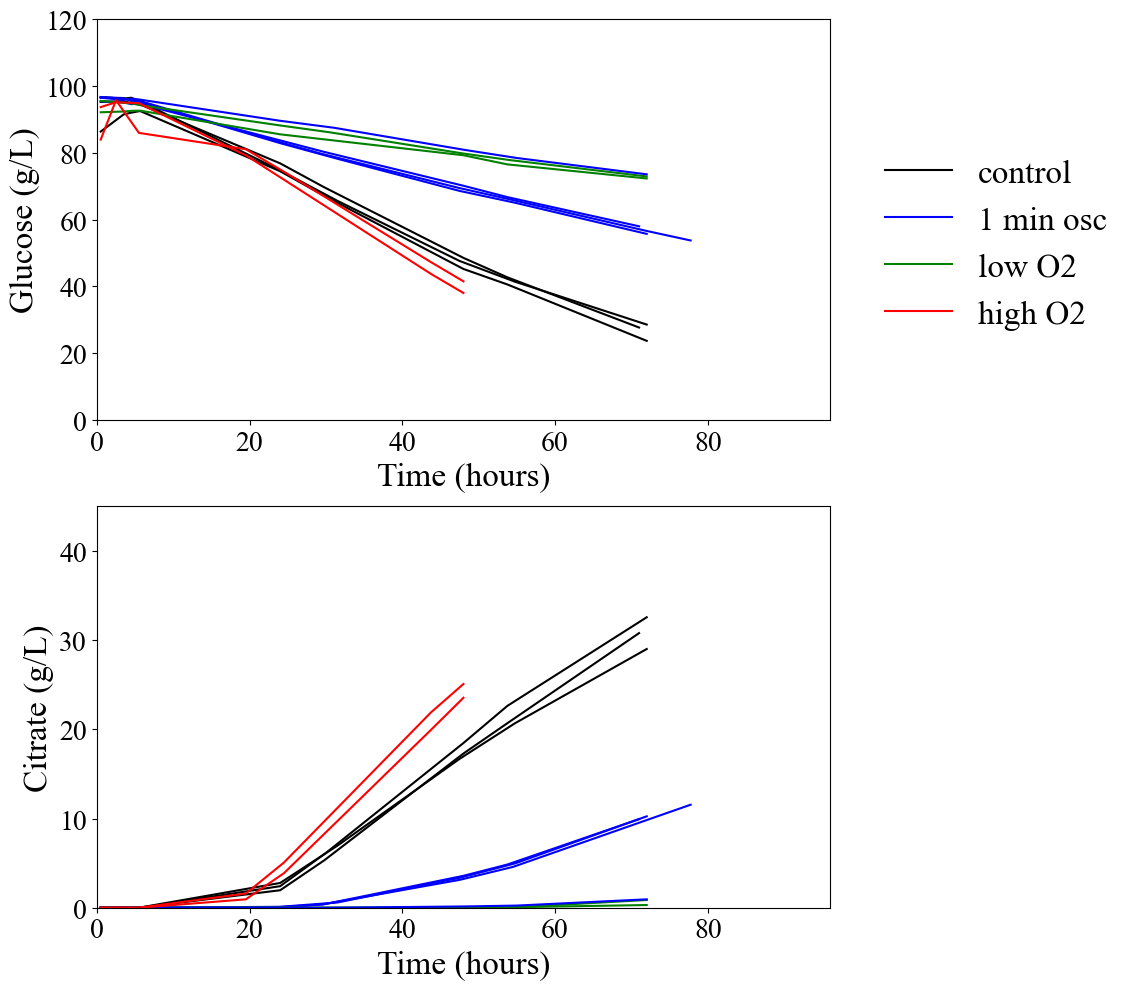

In [84]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'blue', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
    (Biostat_35_r1, 'high O2', 'red', '-'), # oscillating
    (Biostat_35_r2, 'high O2', 'red', '-'),  # pO2 5% 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)



# # Define the datasets and their labels and plotting styles

# Define the datasets and their labels and plotting styles
# storages = [
#     #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
#     (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
#     #(Biostat_30_r1, 'Control', 'black', '-'),  # control #1
#     (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
#     #(Biostat_31_r1, 'Control', 'black', '-'), # control #2
#     (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
#     #(Biostat_32_r1, 'Control', 'black', '-'), # control #3
#     #(Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
#     # (Biostat_33_r1, '1 min osc', 'blue', '-'), # low O2 #2
#     # (Biostat_33_r2, 'low O2', 'green', '-'),  # low O2 #3
#     # (Biostat_34_r1, '1 min osc', 'blue', '-'), # oscillating
#     # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
# ]
# # # Add the FAME yield data to the last subplot
# idx_fame = 3  # this is the index for the last subplot
# for store, label, color, linestyle in storages:
#     if fame_yield_col in store:
#         # axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
#         if "Biostat_23_r2" in label:
#             axs[idx_fame].plot(store['hour'][:-1], store[fame_yield_col][:-1] * 100, label=label, color=color, linestyle=linestyle)
#         elif "Biostat_22_r2" in label:
#             axs[idx_fame].plot(store['hour'].iloc[2:], store[fame_yield_col].iloc[2:] * 100, label=label, color=color, linestyle=linestyle)
#         else:
#             axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# # axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
# axs[idx_fame].set_xlim(0, 96)
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['control', '1 min osc', 'low O2', 'high O2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),

    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
# axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='right',frameon=False)
fig.legend(custom_lines, custom_labels, fontsize=24, loc='center left', bbox_to_anchor=(.86, 0.75), frameon=False)

# Adjust layout
# plt.tight_layout()
plt.tight_layout(rect=[0, 0, 0.85, 1])


# Save and show the plot
# plt.savefig('Biostat_omicsPhenotypeComparison.png', bbox_inches='tight')
plt.show()


Bounding box dimensions (in pixels): (0.0, 0.0, 800.0, 500.0)
Bounding box dimensions (in inches): [0.0, 0.0, 8.0, 5.0]


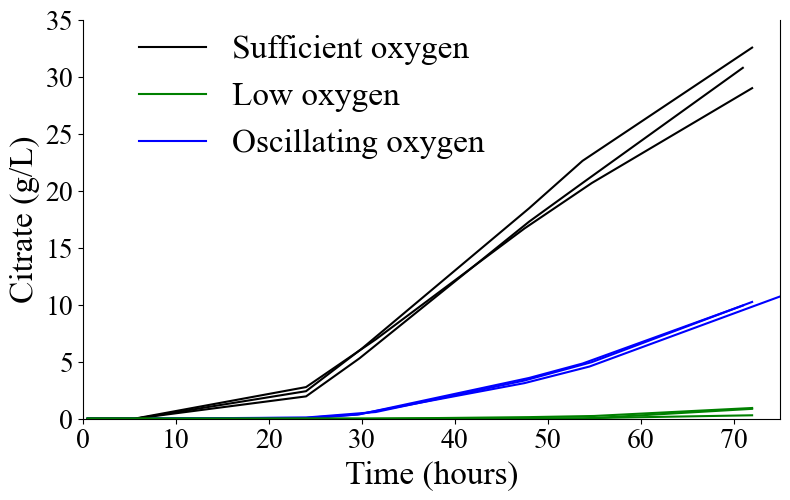

In [85]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    # ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
# axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs.plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs.set_xlabel('Time (hours)', fontsize=24)
    axs.set_ylabel(y_label, fontsize=24)
    axs.set_ylim(*y_lim)
    axs.set_xlim(0, 75)
    axs.tick_params(axis='both', which='major', labelsize=20)
    axs.tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['Sufficient oxygen',  'Low oxygen', 'Oscillating oxygen']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    # plt.Line2D([0], [0], color='orange', linestyle='-'),

    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
# axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='right',frameon=False)
fig.legend(custom_lines, custom_labels, fontsize=24,bbox_to_anchor=(0.65, 1), frameon=False)

# Adjust layout
# plt.tight_layout()
plt.tight_layout()

axs.spines['top'].set_visible(False)

# Save and show the plot
plt.savefig('Biostat_omicsPhenotypeComparison.png', bbox_inches='tight')
# Get the bounding box dimensions
bbox_dims = fig.bbox.bounds
print(f"Bounding box dimensions (in pixels): {bbox_dims}")

# Convert bounding box dimensions to inches
bbox_inches = [dim / fig.dpi for dim in bbox_dims]
print(f"Bounding box dimensions (in inches): {bbox_inches}")

plt.show()


Bounding box dimensions (in pixels): (0.0, 0.0, 800.0, 500.0)
Bounding box dimensions (in inches): [0.0, 0.0, 8.0, 5.0]


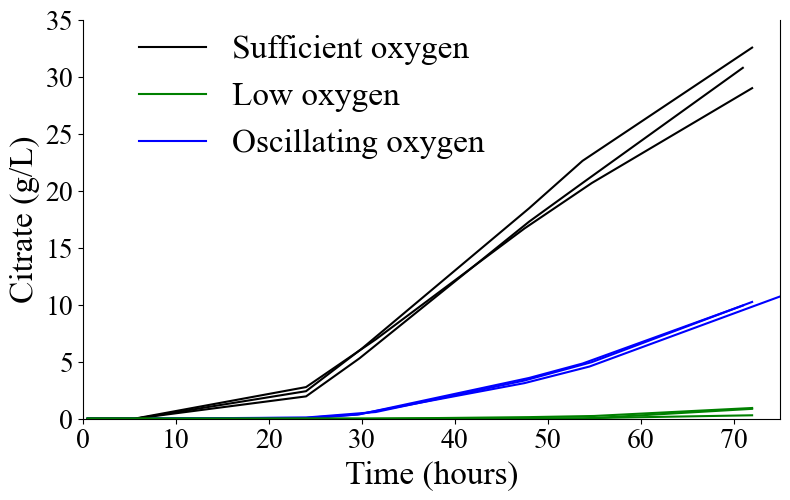

In [86]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    # ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
# axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs.plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs.set_xlabel('Time (hours)', fontsize=24)
    axs.set_ylabel(y_label, fontsize=24)
    axs.set_ylim(*y_lim)
    axs.set_xlim(0, 75)
    axs.tick_params(axis='both', which='major', labelsize=20)
    axs.tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['Sufficient oxygen',  'Low oxygen', 'Oscillating oxygen']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    # plt.Line2D([0], [0], color='orange', linestyle='-'),

    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
# axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='right',frameon=False)
fig.legend(custom_lines, custom_labels, fontsize=24,bbox_to_anchor=(0.65, 1), frameon=False)

# Adjust layout
# plt.tight_layout()
plt.tight_layout()

axs.spines['top'].set_visible(False)

# Save and show the plot
plt.savefig('Biostat_omicsPhenotypeComparison.png', bbox_inches='tight')
# Get the bounding box dimensions
bbox_dims = fig.bbox.bounds
print(f"Bounding box dimensions (in pixels): {bbox_dims}")

# Convert bounding box dimensions to inches
bbox_inches = [dim / fig.dpi for dim in bbox_dims]
print(f"Bounding box dimensions (in inches): {bbox_inches}")

plt.show()


Bounding box dimensions (in pixels): (0.0, 0.0, 800.0, 500.0)
Bounding box dimensions (in inches): [0.0, 0.0, 8.0, 5.0]


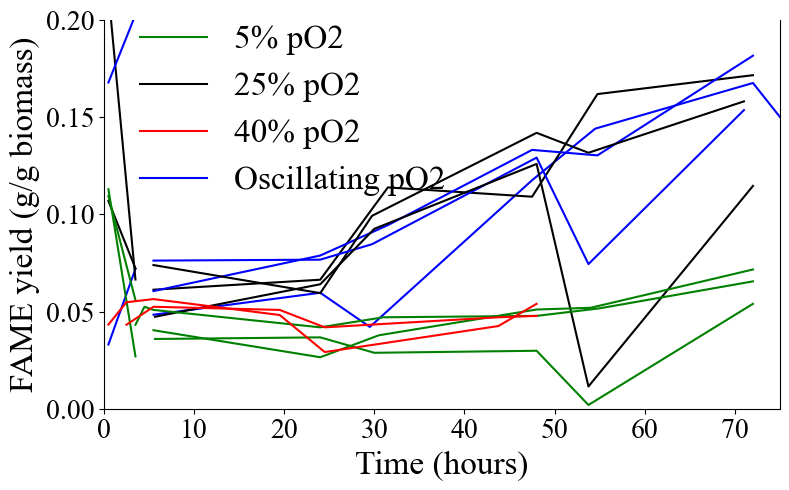

In [87]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
    (Biostat_35_r1, 'high O2', 'red', '-'), # high O2
    (Biostat_35_r2, 'high O2', 'red', '-'), # high O2

]

# Define the y-axis labels and their limits for each subplot
# plot_pairs = [
#     # ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
#     # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
#     ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),
# ]
plot_pairs = [
    # ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('specific_µ_DCW', 'specific_µ_DCW', (0, .25)),
    # ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
    # ('citrate yield', 'Citrate yield (g/gCarbon)', (0, 1)),
    # ('specific citrate yield (g/g substrate)', 'Citrate yield (g/gCarbon)', (0, .2)),
    ('FAME yield (g/g biomass)', 'FAME yield (g/g biomass)', (0, .2)),

]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
# axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs.plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs.set_xlabel('Time (hours)', fontsize=24)
    axs.set_ylabel(y_label, fontsize=24)
    axs.set_ylim(*y_lim)
    axs.set_xlim(0, 75)
    axs.tick_params(axis='both', which='major', labelsize=20)
    axs.tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['Low oxygen', 'Sufficient oxygen', 'High oxygen', 'Oscillating oxygen',]
custom_labels = ['5% pO2', '25% pO2', '40% pO2', 'Oscillating pO2',]

custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),

    # plt.Line2D([0], [0], color='orange', linestyle='-'),

    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
# axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='right',frameon=False)
fig.legend(custom_lines, custom_labels, fontsize=24,bbox_to_anchor=(0.6, 1), frameon=False)

# Adjust layout
# plt.tight_layout()
plt.tight_layout()

axs.spines['top'].set_visible(False)

# Save and show the plot
plt.savefig('Biostat_omicsPhenotypeComparison_highO2.png', bbox_inches='tight')
# Get the bounding box dimensions
bbox_dims = fig.bbox.bounds
print(f"Bounding box dimensions (in pixels): {bbox_dims}")

# Convert bounding box dimensions to inches
bbox_inches = [dim / fig.dpi for dim in bbox_dims]
print(f"Bounding box dimensions (in inches): {bbox_inches}")

plt.show()


In [88]:
from scipy.interpolate import interp1d


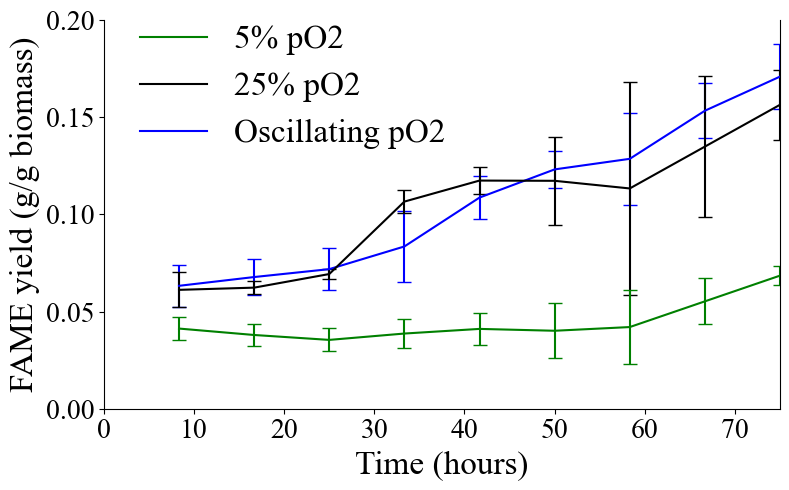

In [89]:


# Define storages and their labels and plotting styles
storages = [
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'),  # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'),  # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'),   # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'),   # low O2 #2
    (Biostat_34_r1, 'low O2', 'green', '-'),   # low O2 #3
    # (Biostat_35_r1, 'high O2', 'red', '-'),    # high O2 #1
    # (Biostat_35_r2, 'high O2', 'red', '-'),    # high O2 #2
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('FAME yield (g/g biomass)', 'FAME yield (g/g biomass)', (0, .2)),
]

# Define a common time grid for interpolation
common_time_grid = np.linspace(0, 75, 10)

# Aggregate data by label with interpolation
data_aggregated = {}
for store, label, color, linestyle in storages:
    if label not in data_aggregated:
        data_aggregated[label] = {'hour': [], 'FAME yield (g/g biomass)': []}
    f_hour = interp1d(store['hour'], store['FAME yield (g/g biomass)'], bounds_error=False, fill_value='extrapolate')
    interpolated_yield = f_hour(common_time_grid)
    data_aggregated[label]['hour'].append(common_time_grid)
    data_aggregated[label]['FAME yield (g/g biomass)'].append(interpolated_yield)

# Compute averages and standard deviations
for label in data_aggregated:
    fame_yields = np.array(data_aggregated[label]['FAME yield (g/g biomass)'])
    avg_fame_yields = np.mean(fame_yields, axis=0)
    std_fame_yields = np.std(fame_yields, axis=0)
    data_aggregated[label]['avg_hour'] = common_time_grid
    data_aggregated[label]['avg_fame_yield'] = avg_fame_yields
    data_aggregated[label]['std_fame_yield'] = std_fame_yields

# Create a plot
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

for (y_col, y_label, y_lim) in plot_pairs:
    for label in data_aggregated:
        color = storages[[i for i, s in enumerate(storages) if s[1] == label][0]][2]
        linestyle = storages[[i for i, s in enumerate(storages) if s[1] == label][0]][3]
        axs.errorbar(
            data_aggregated[label]['avg_hour'],
            data_aggregated[label]['avg_fame_yield'],
            yerr=data_aggregated[label]['std_fame_yield'],
            label=label,
            color=color,
            linestyle=linestyle,
            capsize=5
        )
    axs.set_xlabel('Time (hours)', fontsize=24)
    axs.set_ylabel(y_label, fontsize=24)
    axs.set_ylim(*y_lim)
    axs.set_xlim(0, 75)
    axs.tick_params(axis='both', which='major', labelsize=20)
    axs.tick_params(axis='both', which='minor', labelsize=10)

# Custom legend
custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']

custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    # plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fig.legend(custom_lines, custom_labels, fontsize=24, bbox_to_anchor=(0.6, 1), frameon=False)

plt.tight_layout()

axs.spines['top'].set_visible(False)

# plt.savefig('Biostat_omicsPhenotypeComparison_highO2.png', bbox_inches='tight')

plt.show()


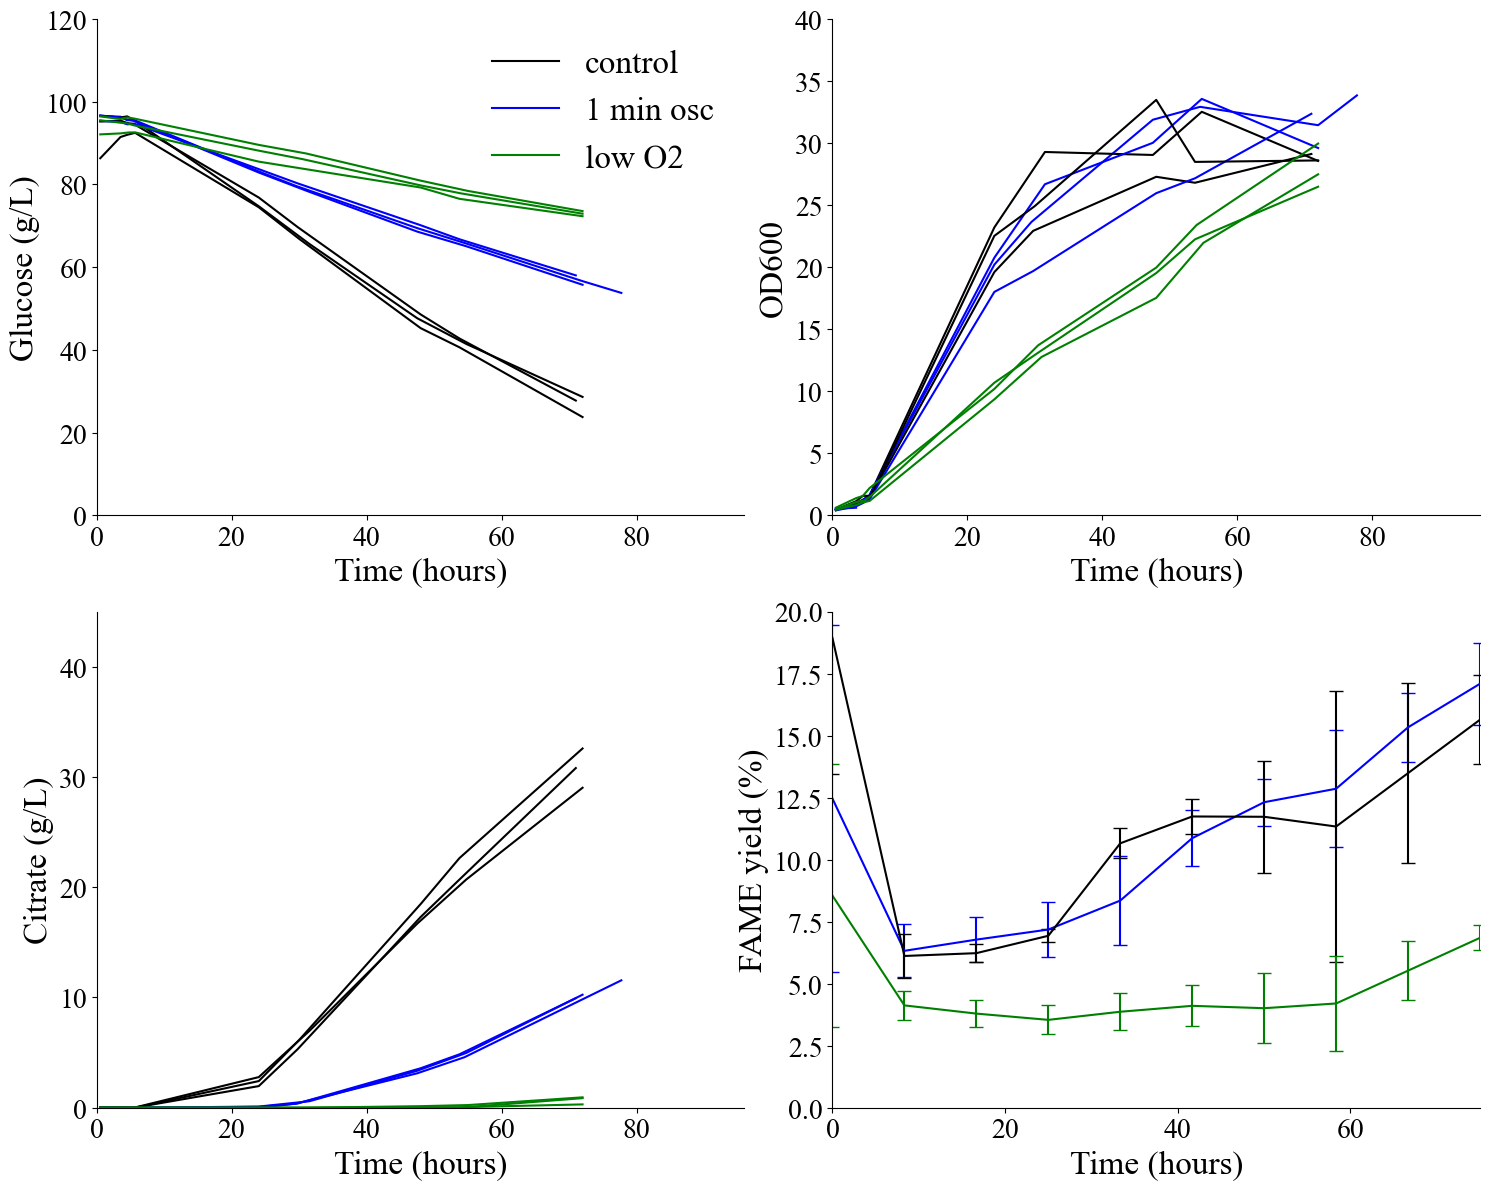

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# -----------------------------
# Define datasets and styles
# -----------------------------
storages = [
    (Biostat_29_r2, '1 min osc', 'blue', '-'),
    (Biostat_30_r1, 'Control', 'black', '-'),
    (Biostat_30_r2, '1 min osc', 'blue', '-'),
    (Biostat_31_r1, 'Control', 'black', '-'),
    (Biostat_31_r2, '1 min osc', 'blue', '-'),
    (Biostat_32_r1, 'Control', 'black', '-'),
    (Biostat_32_r2, 'low O2', 'green', '-'),
    (Biostat_33_r1, 'low O2', 'green', '-'),
    (Biostat_34_r1, 'low O2', 'green', '-'),
    # (Biostat_35_r1, 'high O2', 'red', '-'),
    # (Biostat_35_r2, 'high O2', 'red', '-'),
]

# -----------------------------
# Create 2x2 subplot layout
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.flatten()

# -----------------------------
# First 3 panels
# -----------------------------
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),
    ('OD600', 'OD600', (0, 40)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
]

for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs[idx].plot(
            store['hour'],
            store[y_col],
            label=label,
            color=color,
            linestyle=linestyle
        )
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)
    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)

# -----------------------------
# Fourth panel: interpolated FAME
# -----------------------------
fame_yield_col = 'FAME yield (g/g biomass)'
common_time_grid = np.linspace(0, 75, 10)

data_aggregated = {}

for store, label, color, linestyle in storages:
    if fame_yield_col in store.columns:
        if label not in data_aggregated:
            data_aggregated[label] = {
                'hour': [],
                'fame_yield': [],
                'color': color,
                'linestyle': linestyle
            }

        # Drop NaNs just in case
        valid = store[['hour', fame_yield_col]].dropna()

        # Interpolate onto common grid
        f_interp = interp1d(
            valid['hour'],
            valid[fame_yield_col],
            bounds_error=False,
            fill_value='extrapolate'
        )
        interpolated_y = f_interp(common_time_grid)

        data_aggregated[label]['hour'].append(common_time_grid)
        data_aggregated[label]['fame_yield'].append(interpolated_y)

# Compute averages/std and plot on 4th panel
idx_fame = 3

for label, group_data in data_aggregated.items():
    fame_array = np.array(group_data['fame_yield'])
    avg_fame = np.mean(fame_array, axis=0)
    std_fame = np.std(fame_array, axis=0)

    axs[idx_fame].errorbar(
        common_time_grid,
        avg_fame * 100,              # convert to %
        yerr=std_fame * 100,         # convert to %
        label=label,
        color=group_data['color'],
        linestyle=group_data['linestyle'],
        capsize=5
    )

axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_xlim(0, 75)
axs[idx_fame].set_ylim(0, 20)  # adjust if needed
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

custom_labels = ['control', '1 min osc', 'low O2',]# 'high O2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    # plt.Line2D([0], [0], color='red', linestyle='-'),
]

axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

plt.tight_layout()
plt.savefig('Biostat_omicsPhenotypeComparison2_interpolatedFAME.png', bbox_inches='tight')
plt.show()


GROUPED TIMEPOINTS USED FOR ALL PANELS
[ 0.5  3.5  4.5  5.5 24.  30.  48.  54.  72. ]

RAW TIMEPOINTS BY CONDITION

Condition: 1 min osc
  Biostat_29_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.5 , 47.5 , 54.5 , 72.  , 77.75]
  Biostat_30_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]

Condition: Control
  Biostat_30_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]
  Biostat_32_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]

Condition: low O2
  Biostat_32_r2: [ 0.5 ,  3.5 ,  4.75,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]
  Biostat_33_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 30.5, 48. , 54. , 72. ]
  Biostat_34_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 31. , 48. , 55. , 72. ]


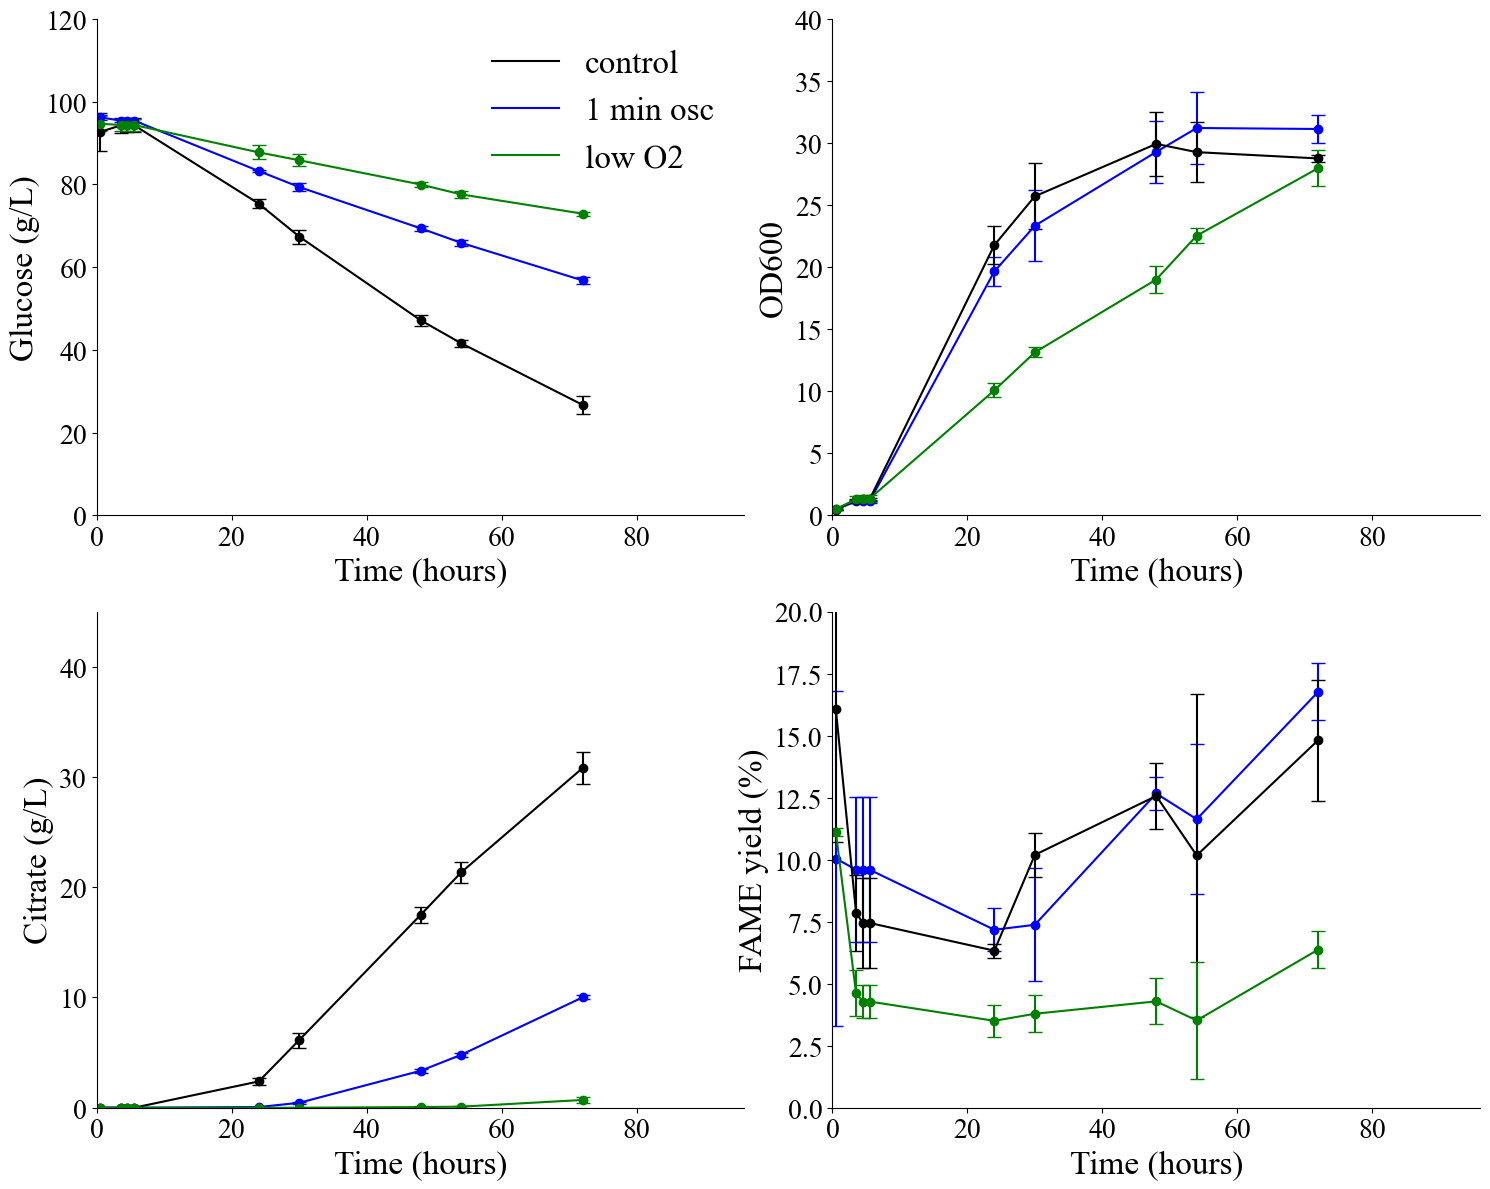

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Define grouped timepoints
# -----------------------------
grouped_timepoints = np.array([0.5, 3.5, 4.5, 5.5, 24.0, 30.0, 48.0, 54.0, 72.0])
tolerance = 2.0  # hours

# -----------------------------
# Define datasets and styles
# -----------------------------
storages_named = [
    ('Biostat_29_r2', Biostat_29_r2, '1 min osc', 'blue', '-'),
    ('Biostat_30_r1', Biostat_30_r1, 'Control', 'black', '-'),
    ('Biostat_30_r2', Biostat_30_r2, '1 min osc', 'blue', '-'),
    ('Biostat_31_r1', Biostat_31_r1, 'Control', 'black', '-'),
    ('Biostat_31_r2', Biostat_31_r2, '1 min osc', 'blue', '-'),
    ('Biostat_32_r1', Biostat_32_r1, 'Control', 'black', '-'),
    ('Biostat_32_r2', Biostat_32_r2, 'low O2', 'green', '-'),
    ('Biostat_33_r1', Biostat_33_r1, 'low O2', 'green', '-'),
    ('Biostat_34_r1', Biostat_34_r1, 'low O2', 'green', '-'),
    # ('Biostat_35_r1', Biostat_35_r1, 'high O2', 'red', '-'),
    # ('Biostat_35_r2', Biostat_35_r2, 'high O2', 'red', '-'),
]

# -----------------------------
# Helper function:
# bin each replicate to grouped timepoints
# -----------------------------
def bin_to_grouped_timepoints(store, y_col, grouped_timepoints, tolerance=2.0):
    valid = store[['hour', y_col]].dropna().copy()
    x = valid['hour'].to_numpy()
    y = valid[y_col].to_numpy()

    grouped_y = []
    for t0 in grouped_timepoints:
        diffs = np.abs(x - t0)
        in_bin = diffs <= tolerance

        if np.any(in_bin):
            grouped_y.append(np.mean(y[in_bin]))
        else:
            grouped_y.append(np.nan)

    return np.array(grouped_y)

# -----------------------------
# Optional: print grouping summary
# -----------------------------
print("\n" + "="*80)
print("GROUPED TIMEPOINTS USED FOR ALL PANELS")
print("="*80)
print(grouped_timepoints)

print("\n" + "="*80)
print("RAW TIMEPOINTS BY CONDITION")
print("="*80)

condition_times = {}
for name, store, label, color, linestyle in storages_named:
    times = store['hour'].dropna().to_numpy()
    condition_times.setdefault(label, []).append((name, times))

for label, reps in condition_times.items():
    print(f"\nCondition: {label}")
    for rep_name, times in reps:
        print(f"  {rep_name}: {np.array2string(times, precision=2, separator=', ')}")

# -----------------------------
# Create 2x2 subplot layout
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.flatten()

# -----------------------------
# First 3 panels
# -----------------------------
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),
    ('OD600', 'OD600', (0, 40)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
]

for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    aggregated = {}

    for name, store, label, color, linestyle in storages_named:
        if y_col not in store.columns:
            continue

        grouped_y = bin_to_grouped_timepoints(
            store=store,
            y_col=y_col,
            grouped_timepoints=grouped_timepoints,
            tolerance=tolerance
        )

        if label not in aggregated:
            aggregated[label] = {
                'y_values': [],
                'color': color,
                'linestyle': linestyle
            }

        aggregated[label]['y_values'].append(grouped_y)

    for label, group_data in aggregated.items():
        y_array = np.array(group_data['y_values'])
        avg_y = np.nanmean(y_array, axis=0)
        std_y = np.nanstd(y_array, axis=0)

        axs[idx].errorbar(
            grouped_timepoints,
            avg_y,
            yerr=std_y,
            label=label,
            color=group_data['color'],
            linestyle=group_data['linestyle'],
            marker='o',
            capsize=5
        )

    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)
    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)

# -----------------------------
# Fourth panel: FAME
# same grouped-time averaging approach
# -----------------------------
fame_yield_col = 'FAME yield (g/g biomass)'
idx_fame = 3

aggregated_fame = {}

for name, store, label, color, linestyle in storages_named:
    if fame_yield_col not in store.columns:
        continue

    grouped_y = bin_to_grouped_timepoints(
        store=store,
        y_col=fame_yield_col,
        grouped_timepoints=grouped_timepoints,
        tolerance=tolerance
    )

    if label not in aggregated_fame:
        aggregated_fame[label] = {
            'y_values': [],
            'color': color,
            'linestyle': linestyle
        }

    aggregated_fame[label]['y_values'].append(grouped_y)

for label, group_data in aggregated_fame.items():
    y_array = np.array(group_data['y_values'])
    avg_y = np.nanmean(y_array, axis=0)
    std_y = np.nanstd(y_array, axis=0)

    axs[idx_fame].errorbar(
        grouped_timepoints,
        avg_y * 100,      # convert to %
        yerr=std_y * 100, # convert to %
        label=label,
        color=group_data['color'],
        linestyle=group_data['linestyle'],
        marker='o',
        capsize=5
    )

axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_xlim(0, 96)
axs[idx_fame].set_ylim(0, 20)  # adjust if needed
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

custom_labels = ['control', '1 min osc', 'low O2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
]

axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

plt.tight_layout()
# plt.savefig('Biostat_omicsPhenotypeComparison2_groupedAveragedAllPanels.png', bbox_inches='tight')
plt.show()

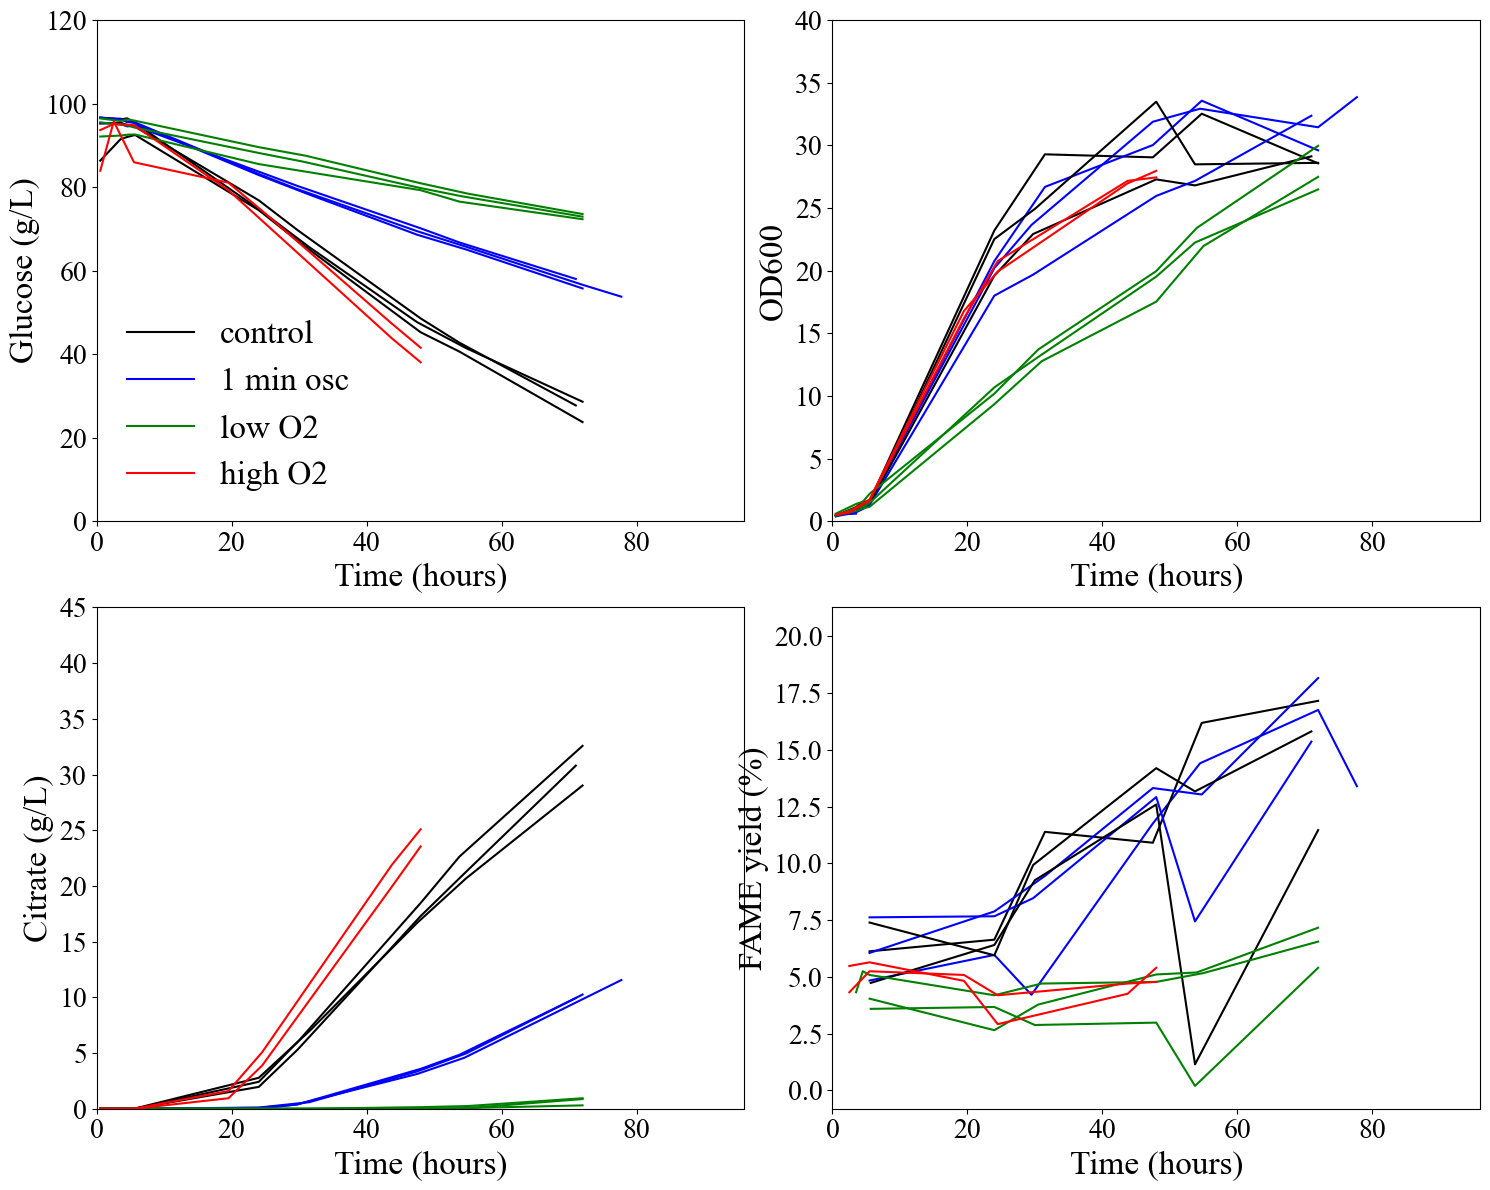

In [92]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # low O2 #4
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # low O2 #5
    (Biostat_35_r1, 'High O2', 'red', '-'), # low O2 #4
    (Biostat_35_r2, 'High O2', 'red', '-'),  # low O2 #5
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
    ('OD600', 'OD600', (0, 40)),

    ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
    # ('citrate yield', 'Citrate yield (g/gCarbon)', (0, 1)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs[idx].plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)



# # Define the datasets and their labels and plotting styles

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'green', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
    (Biostat_35_r1, 'high O2', 'red', '-'), # oscillating
    (Biostat_35_r2, 'high O2', 'red', '-'),  # pO2 5% 
]
# # Add the FAME yield data to the last subplot
idx_fame = 3  # this is the index for the last subplot
for store, label, color, linestyle in storages:
    if fame_yield_col in store:
        # axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
        if "Biostat_23_r2" in label:
            axs[idx_fame].plot(store['hour'][:-1], store[fame_yield_col][:-1] * 100, label=label, color=color, linestyle=linestyle)
        elif "Biostat_22_r2" in label:
            axs[idx_fame].plot(store['hour'].iloc[2:], store[fame_yield_col].iloc[2:] * 100, label=label, color=color, linestyle=linestyle)
        else:
            axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
axs[idx_fame].set_xlim(0, 96)
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['control', '1 min osc', 'low O2', 'high O2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
# plt.savefig('Biostat_omicsPhenotypeComparison2.png')
plt.show()


In [93]:
from matplotlib.ticker import FormatStrFormatter


## Averaged and grouped.


GROUPED TIMEPOINTS USED FOR ALL PANELS
[ 0.5  3.5  4.5  5.5 24.  30.  48.  54.  72. ]

RAW TIMEPOINTS BY CONDITION

Condition: 1 min osc
  Biostat_29_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.5 , 47.5 , 54.5 , 72.  , 77.75]
  Biostat_30_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]

Condition: Control
  Biostat_30_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]
  Biostat_32_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]

Condition: low O2
  Biostat_32_r2: [ 0.5 ,  3.5 ,  4.75,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]
  Biostat_33_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 30.5, 48. , 54. , 72. ]
  Biostat_34_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 31. , 48. , 55. , 72. ]


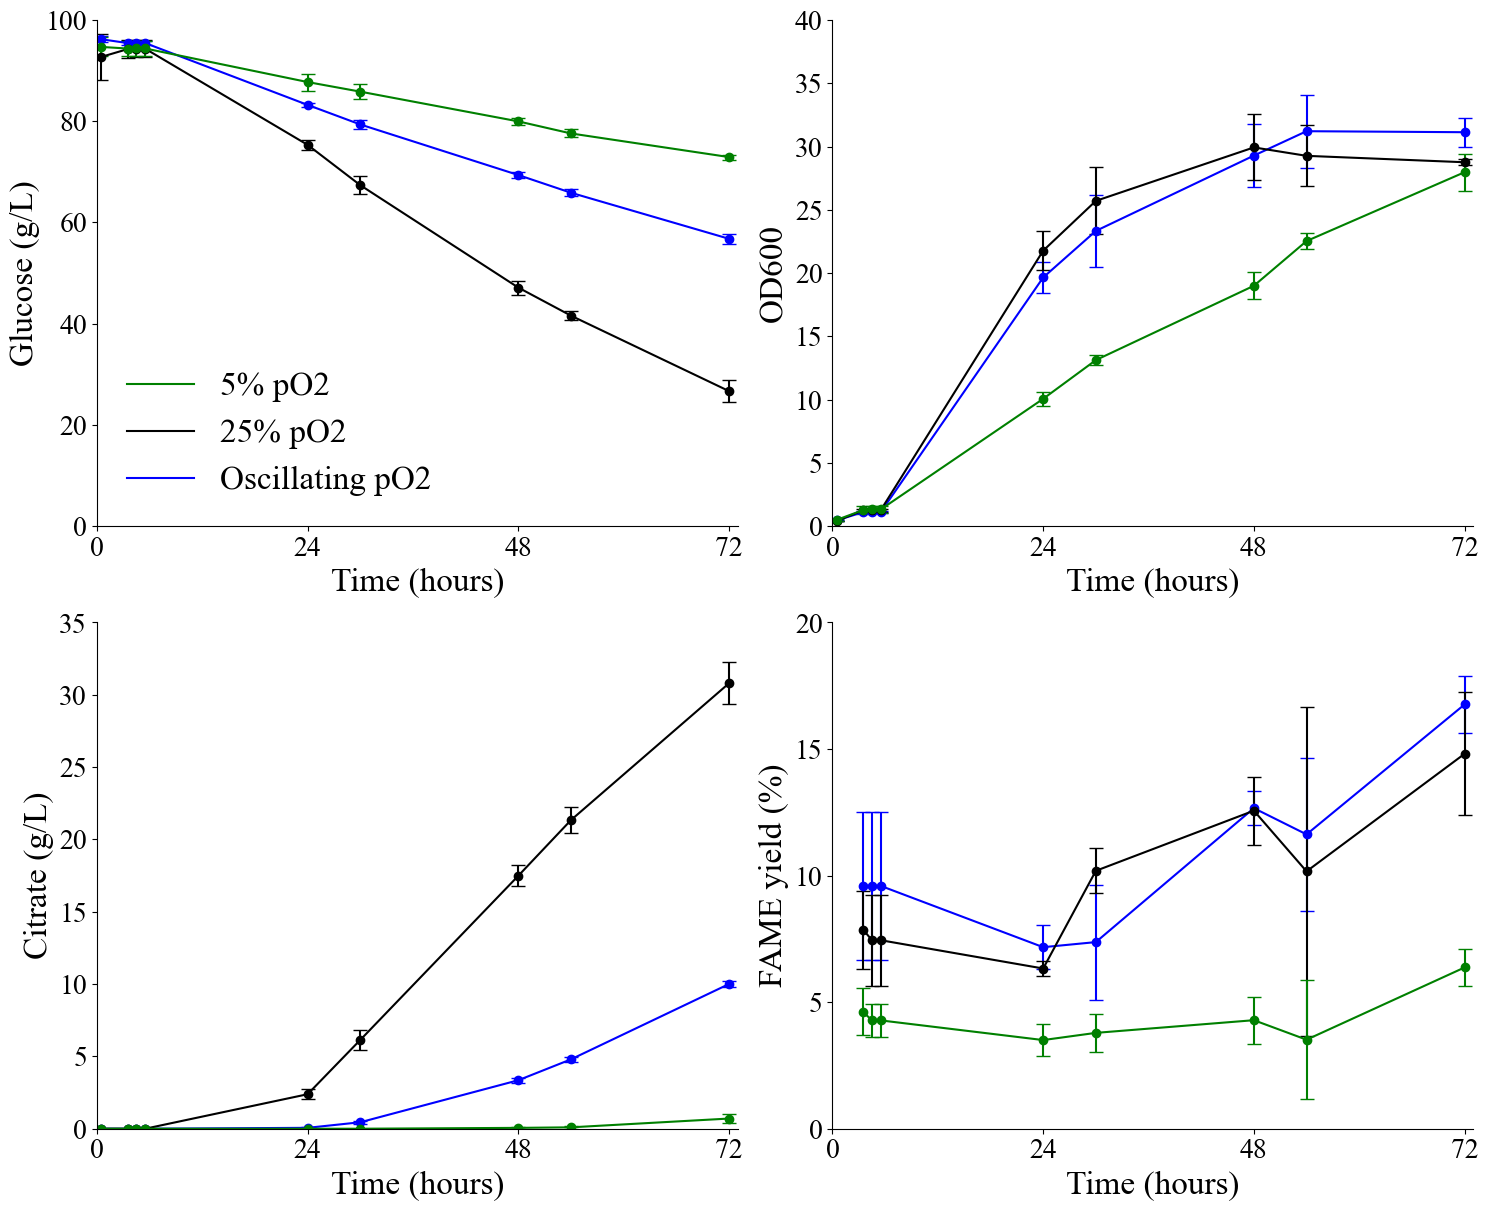

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
# -----------------------------
# Define grouped timepoints
# -----------------------------
grouped_timepoints = np.array([0.5, 3.5, 4.5, 5.5, 24.0, 30.0, 48.0, 54.0, 72.0])
tolerance = 2.0  # hours

# -----------------------------
# Define datasets and styles
# -----------------------------
storages_named = [
    ('Biostat_29_r2', Biostat_29_r2, '1 min osc', 'blue', '-'),
    ('Biostat_30_r1', Biostat_30_r1, 'Control', 'black', '-'),
    ('Biostat_30_r2', Biostat_30_r2, '1 min osc', 'blue', '-'),
    ('Biostat_31_r1', Biostat_31_r1, 'Control', 'black', '-'),
    ('Biostat_31_r2', Biostat_31_r2, '1 min osc', 'blue', '-'),
    ('Biostat_32_r1', Biostat_32_r1, 'Control', 'black', '-'),
    ('Biostat_32_r2', Biostat_32_r2, 'low O2', 'green', '-'),
    ('Biostat_33_r1', Biostat_33_r1, 'low O2', 'green', '-'),
    ('Biostat_34_r1', Biostat_34_r1, 'low O2', 'green', '-'),
    # ('Biostat_35_r1', Biostat_35_r1, 'high O2', 'red', '-'),
    # ('Biostat_35_r2', Biostat_35_r2, 'high O2', 'red', '-'),
]

# -----------------------------
# Helper function:
# bin each replicate to grouped timepoints
# -----------------------------
def bin_to_grouped_timepoints(store, y_col, grouped_timepoints, tolerance=2.0):
    valid = store[['hour', y_col]].dropna().copy()
    x = valid['hour'].to_numpy()
    y = valid[y_col].to_numpy()

    grouped_y = []
    for t0 in grouped_timepoints:
        diffs = np.abs(x - t0)
        in_bin = diffs <= tolerance

        if np.any(in_bin):
            grouped_y.append(np.mean(y[in_bin]))
        else:
            grouped_y.append(np.nan)

    return np.array(grouped_y)

# -----------------------------
# Optional: print grouping summary
# -----------------------------
print("\n" + "="*80)
print("GROUPED TIMEPOINTS USED FOR ALL PANELS")
print("="*80)
print(grouped_timepoints)

print("\n" + "="*80)
print("RAW TIMEPOINTS BY CONDITION")
print("="*80)

condition_times = {}
for name, store, label, color, linestyle in storages_named:
    times = store['hour'].dropna().to_numpy()
    condition_times.setdefault(label, []).append((name, times))

for label, reps in condition_times.items():
    print(f"\nCondition: {label}")
    for rep_name, times in reps:
        print(f"  {rep_name}: {np.array2string(times, precision=2, separator=', ')}")

# -----------------------------
# Create 2x2 subplot layout
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(15, 12.2))
axs = axs.flatten()

# -----------------------------
# First 3 panels
# -----------------------------
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 100)),
    ('OD600', 'OD600', (0, 40)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),
]

xticks_24h = np.arange(0, 75, 24)

for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    aggregated = {}

    for name, store, label, color, linestyle in storages_named:
        if y_col not in store.columns:
            continue

        grouped_y = bin_to_grouped_timepoints(
            store=store,
            y_col=y_col,
            grouped_timepoints=grouped_timepoints,
            tolerance=tolerance
        )

        if label not in aggregated:
            aggregated[label] = {
                'y_values': [],
                'color': color,
                'linestyle': linestyle
            }

        aggregated[label]['y_values'].append(grouped_y)

    for label, group_data in aggregated.items():
        y_array = np.array(group_data['y_values'])
        avg_y = np.nanmean(y_array, axis=0)
        std_y = np.nanstd(y_array, axis=0)

        axs[idx].errorbar(
            grouped_timepoints,
            avg_y,
            yerr=std_y,
            label=label,
            color=group_data['color'],
            linestyle=group_data['linestyle'],
            marker='o',
            capsize=5
        )

    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 73)
    axs[idx].set_xticks(xticks_24h)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)
    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)

# -----------------------------
# Fourth panel: FAME
# same grouped-time averaging approach as panels 1–3
# -----------------------------
fame_yield_col = 'FAME yield (g/g biomass)'
idx_fame = 3

aggregated_fame = {}

for name, store, label, color, linestyle in storages_named:
    if fame_yield_col not in store.columns:
        continue

    grouped_y = bin_to_grouped_timepoints(
        store=store,
        y_col=fame_yield_col,
        grouped_timepoints=grouped_timepoints,
        tolerance=tolerance
    )

    if label not in aggregated_fame:
        aggregated_fame[label] = {
            'y_values': [],
            'color': color,
            'linestyle': linestyle
        }

    aggregated_fame[label]['y_values'].append(grouped_y)

# drop first timepoint for FAME panel only
fame_timepoints_plot = grouped_timepoints[1:]

for label, group_data in aggregated_fame.items():
    y_array = np.array(group_data['y_values'])
    avg_y = np.nanmean(y_array, axis=0)
    std_y = np.nanstd(y_array, axis=0)

    axs[idx_fame].errorbar(
        fame_timepoints_plot,
        avg_y[1:] * 100,
        yerr=std_y[1:] * 100,
        label=label,
        color=group_data['color'],
        linestyle=group_data['linestyle'],
        marker='o',
        capsize=5
    )

# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_xlim(0, 96)
# axs[idx_fame].set_ylim(0, 20)
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
# axs[idx_fame].spines['top'].set_visible(False)
# axs[idx_fame].spines['right'].set_visible(False)

# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_xlim(0, 73)
# axs[idx_fame].set_xticks(xticks_24h)
# axs[idx_fame].set_ylim(0, 20)  # adjust if needed
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
# axs[idx_fame].spines['top'].set_visible(False)
# axs[idx_fame].spines['right'].set_visible(False)

axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_xlim(0, 73)
axs[idx_fame].set_xticks(xticks_24h)
axs[idx_fame].set_ylim(0, 20)
axs[idx_fame].set_yticks(np.arange(0, 21, 5))
axs[idx_fame].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']
custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]

axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

plt.tight_layout()
plt.savefig('Biostat_omicsPhenotypeComparison2_groupedAveragedAllPanels.png', bbox_inches='tight')
plt.show()


GROUPED TIMEPOINTS USED FOR ALL PANELS
[ 0.5  3.5  4.5  5.5 24.  30.  48.  54.  72. ]

RAW TIMEPOINTS BY CONDITION

Condition: 1 min osc
  Biostat_29_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.5 , 47.5 , 54.5 , 72.  , 77.75]
  Biostat_30_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]

Condition: Control
  Biostat_30_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]
  Biostat_32_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]

Condition: low O2
  Biostat_32_r2: [ 0.5 ,  3.5 ,  4.75,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]
  Biostat_33_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 30.5, 48. , 54. , 72. ]
  Biostat_34_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 31. , 48. , 55. , 72. ]
[0.10043719 0.09593608 0.09593608 0.09593608 0.07172294 0.07373031
 0.12665042 0.1162862  0.16762169] 
 [

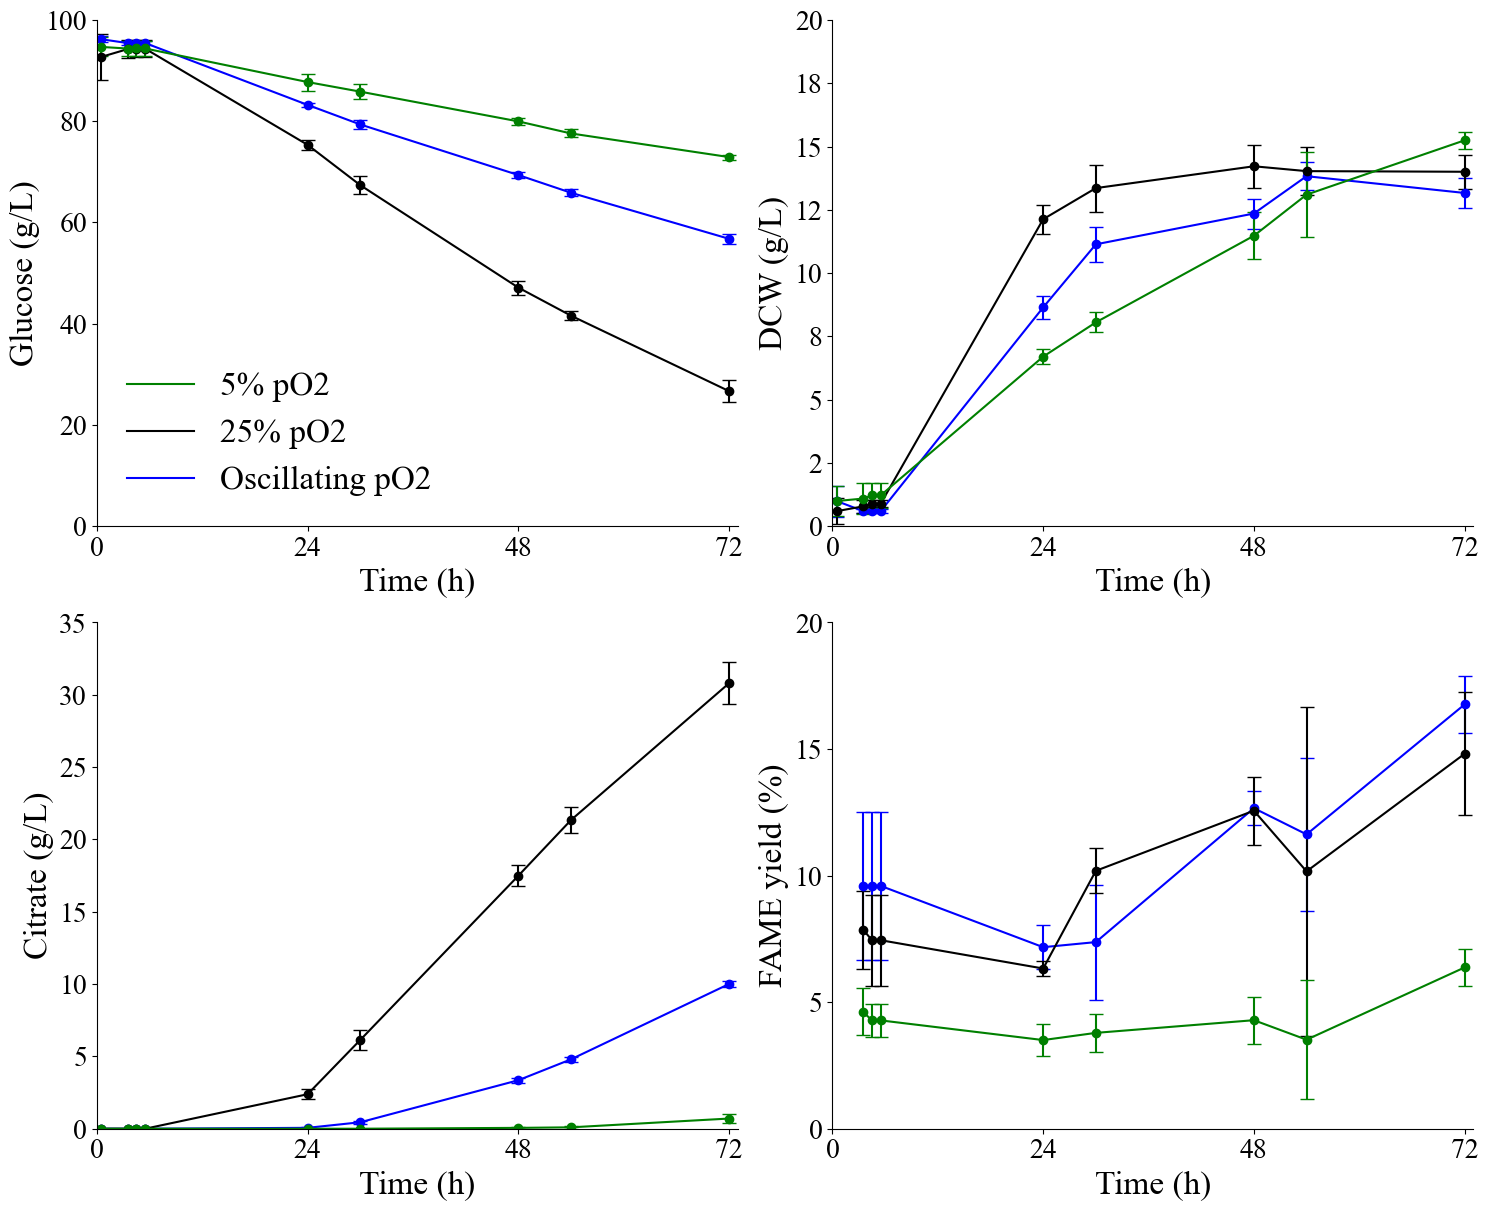

In [95]:


# -----------------------------
# Define grouped timepoints
# -----------------------------
grouped_timepoints = np.array([0.5, 3.5, 4.5, 5.5, 24.0, 30.0, 48.0, 54.0, 72.0])
tolerance = 2.0  # hours

# -----------------------------
# Define datasets and styles
# -----------------------------
storages_named = [
    ('Biostat_29_r2', Biostat_29_r2, '1 min osc', 'blue', '-'),
    ('Biostat_30_r1', Biostat_30_r1, 'Control', 'black', '-'),
    ('Biostat_30_r2', Biostat_30_r2, '1 min osc', 'blue', '-'),
    ('Biostat_31_r1', Biostat_31_r1, 'Control', 'black', '-'),
    ('Biostat_31_r2', Biostat_31_r2, '1 min osc', 'blue', '-'),
    ('Biostat_32_r1', Biostat_32_r1, 'Control', 'black', '-'),
    ('Biostat_32_r2', Biostat_32_r2, 'low O2', 'green', '-'),
    ('Biostat_33_r1', Biostat_33_r1, 'low O2', 'green', '-'),
    ('Biostat_34_r1', Biostat_34_r1, 'low O2', 'green', '-'),
    # ('Biostat_35_r1', Biostat_35_r1, 'high O2', 'red', '-'),
    # ('Biostat_35_r2', Biostat_35_r2, 'high O2', 'red', '-'),
]

# -----------------------------
# Helper function:
# bin each replicate to grouped timepoints
# -----------------------------
def bin_to_grouped_timepoints(store, y_col, grouped_timepoints, tolerance=2.0):
    valid = store[['hour', y_col]].dropna().copy()
    x = valid['hour'].to_numpy()
    y = valid[y_col].to_numpy()

    grouped_y = []
    for t0 in grouped_timepoints:
        diffs = np.abs(x - t0)
        in_bin = diffs <= tolerance

        if np.any(in_bin):
            grouped_y.append(np.mean(y[in_bin]))
        else:
            grouped_y.append(np.nan)

    return np.array(grouped_y)

# -----------------------------
# Optional: print grouping summary
# -----------------------------
print("\n" + "="*80)
print("GROUPED TIMEPOINTS USED FOR ALL PANELS")
print("="*80)
print(grouped_timepoints)

print("\n" + "="*80)
print("RAW TIMEPOINTS BY CONDITION")
print("="*80)

condition_times = {}
for name, store, label, color, linestyle in storages_named:
    times = store['hour'].dropna().to_numpy()
    condition_times.setdefault(label, []).append((name, times))

for label, reps in condition_times.items():
    print(f"\nCondition: {label}")
    for rep_name, times in reps:
        print(f"  {rep_name}: {np.array2string(times, precision=2, separator=', ')}")

# -----------------------------
# Create 2x2 subplot layout
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(15, 12.2))
axs = axs.flatten()

# -----------------------------
# First 3 panels
# -----------------------------
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 100)),
    ('DCW (g/L)', 'DCW (g/L)', (0, 20)),

    # ('OD600', 'OD600', (0, 40)),
    ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),
]

xticks_24h = np.arange(0, 75, 24)

for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    aggregated = {}

    for name, store, label, color, linestyle in storages_named:
        if y_col not in store.columns:
            continue

        grouped_y = bin_to_grouped_timepoints(
            store=store,
            y_col=y_col,
            grouped_timepoints=grouped_timepoints,
            tolerance=tolerance
        )

        if label not in aggregated:
            aggregated[label] = {
                'y_values': [],
                'color': color,
                'linestyle': linestyle
            }

        aggregated[label]['y_values'].append(grouped_y)

    for label, group_data in aggregated.items():
        y_array = np.array(group_data['y_values'])
        avg_y = np.nanmean(y_array, axis=0)
        std_y = np.nanstd(y_array, axis=0)

        axs[idx].errorbar(
            grouped_timepoints,
            avg_y,
            yerr=std_y,
            label=label,
            color=group_data['color'],
            linestyle=group_data['linestyle'],
            marker='o',
            capsize=5
        )

    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 73)
    axs[idx].set_xticks(xticks_24h)
    axs[idx].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)
    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)

# -----------------------------
# Fourth panel: FAME
# same grouped-time averaging approach as panels 1–3
# -----------------------------
fame_yield_col = 'FAME yield (g/g biomass)'
idx_fame = 3

aggregated_fame = {}

for name, store, label, color, linestyle in storages_named:
    if fame_yield_col not in store.columns:
        continue

    grouped_y = bin_to_grouped_timepoints(
        store=store,
        y_col=fame_yield_col,
        grouped_timepoints=grouped_timepoints,
        tolerance=tolerance
    )

    if label not in aggregated_fame:
        aggregated_fame[label] = {
            'y_values': [],
            'color': color,
            'linestyle': linestyle
        }

    aggregated_fame[label]['y_values'].append(grouped_y)

# drop first timepoint for FAME panel only
fame_timepoints_plot = grouped_timepoints[1:]

for label, group_data in aggregated_fame.items():
    y_array = np.array(group_data['y_values'])
    avg_y = np.nanmean(y_array, axis=0)
    std_y = np.nanstd(y_array, axis=0)
    print( avg_y,'\n', std_y,label,'\n')

    axs[idx_fame].errorbar(
        fame_timepoints_plot,
        avg_y[1:] * 100,
        yerr=std_y[1:] * 100,
        label=label,
        color=group_data['color'],
        linestyle=group_data['linestyle'],
        marker='o',
        capsize=5
    )


# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_xlim(0, 96)
# axs[idx_fame].set_ylim(0, 20)
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
# axs[idx_fame].spines['top'].set_visible(False)
# axs[idx_fame].spines['right'].set_visible(False)

# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_xlim(0, 73)
# axs[idx_fame].set_xticks(xticks_24h)
# axs[idx_fame].set_ylim(0, 20)  # adjust if needed
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
# axs[idx_fame].spines['top'].set_visible(False)
# axs[idx_fame].spines['right'].set_visible(False)
for ax in axs.ravel():
    ax.set_xlabel("Time (h)")
axs[idx_fame].set_xlabel('Time (h)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_xlim(0, 73)
axs[idx_fame].set_xticks(xticks_24h)
axs[idx_fame].set_ylim(0, 20)
axs[idx_fame].set_yticks(np.arange(0, 21, 5))
axs[idx_fame].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']
# custom_lines = [
#     plt.Line2D([0], [0], color='black', linestyle='-'),
#     plt.Line2D([0], [0], color='blue', linestyle='-'),
#     plt.Line2D([0], [0], color='green', linestyle='-'),
# ]

custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']
custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]
axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

plt.tight_layout()
plt.savefig('Biostat_omicsPhenotypeComparison2_groupedAveragedAllPanels.png', bbox_inches='tight')
plt.show()

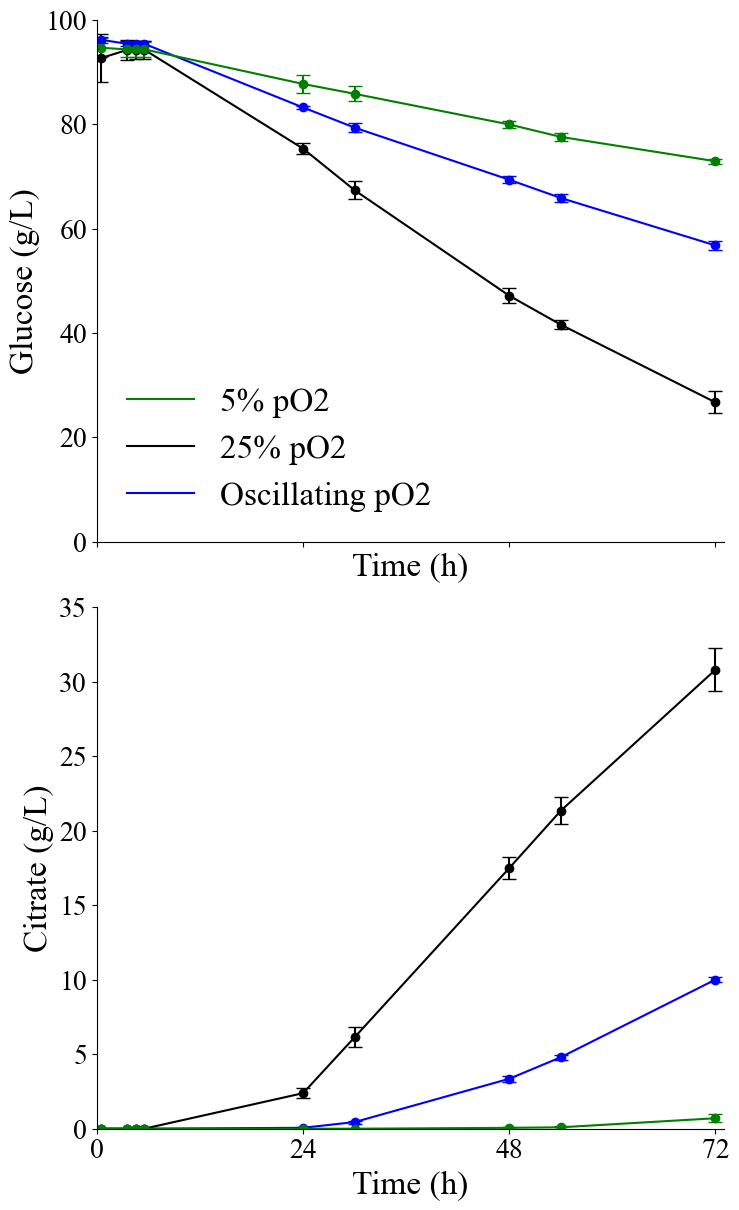

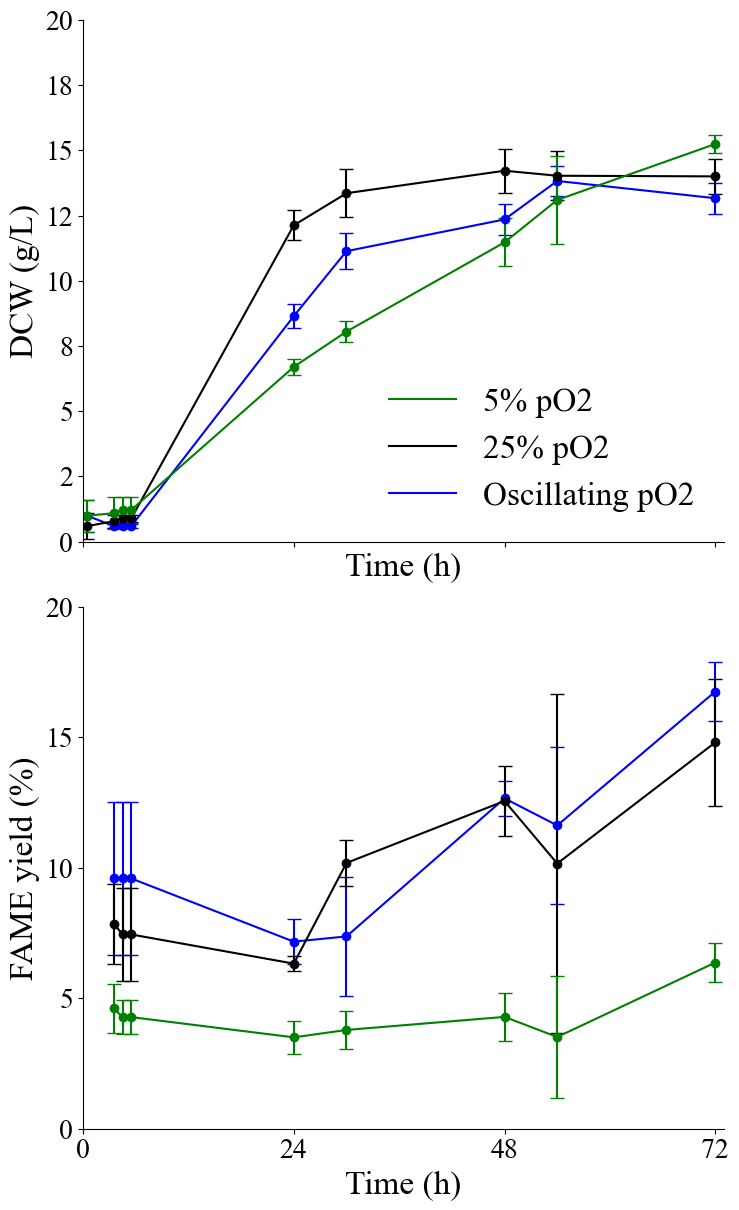

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# --- keep your grouped_timepoints, tolerance, storages_named, bin_to_grouped_timepoints as-is ---

xticks_24h = np.arange(0, 75, 24)

def plot_panel(ax, y_col, y_label, y_lim, grouped_timepoints, tolerance, storages_named):
    aggregated = {}
    for name, store, label, color, linestyle in storages_named:
        if y_col not in store.columns:
            continue
        grouped_y = bin_to_grouped_timepoints(store, y_col, grouped_timepoints, tolerance)
        aggregated.setdefault(label, {'y_values': [], 'color': color, 'linestyle': linestyle})
        aggregated[label]['y_values'].append(grouped_y)

    for label, group_data in aggregated.items():
        y_array = np.array(group_data['y_values'])
        avg_y = np.nanmean(y_array, axis=0)
        std_y = np.nanstd(y_array, axis=0)

        ax.errorbar(
            grouped_timepoints, avg_y, yerr=std_y,
            label=label, color=group_data['color'],
            linestyle=group_data['linestyle'],
            marker='o', capsize=5
        )

    ax.set_xlabel("Time (h)", fontsize=24)
    ax.set_ylabel(y_label, fontsize=24)
    ax.set_ylim(*y_lim)
    ax.set_xlim(0, 73)
    ax.set_xticks(xticks_24h)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def plot_fame_panel(ax, fame_yield_col, grouped_timepoints, tolerance, storages_named):
    aggregated_fame = {}
    for name, store, label, color, linestyle in storages_named:
        if fame_yield_col not in store.columns:
            continue
        grouped_y = bin_to_grouped_timepoints(store, fame_yield_col, grouped_timepoints, tolerance)
        aggregated_fame.setdefault(label, {'y_values': [], 'color': color, 'linestyle': linestyle})
        aggregated_fame[label]['y_values'].append(grouped_y)

    # drop first timepoint for FAME panel only
    fame_timepoints_plot = grouped_timepoints[1:]

    for label, group_data in aggregated_fame.items():
        y_array = np.array(group_data['y_values'])
        avg_y = np.nanmean(y_array, axis=0)
        std_y = np.nanstd(y_array, axis=0)

        ax.errorbar(
            fame_timepoints_plot,
            avg_y[1:] * 100,
            yerr=std_y[1:] * 100,
            label=label,
            color=group_data['color'],
            linestyle=group_data['linestyle'],
            marker='o',
            capsize=5
        )

    ax.set_xlabel("Time (h)", fontsize=24)
    ax.set_ylabel("FAME yield (%)", fontsize=24)
    ax.set_xlim(0, 73)
    ax.set_xticks(xticks_24h)
    ax.set_ylim(0, 20)
    ax.set_yticks(np.arange(0, 21, 5))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# -----------------------------
# Shared legend setup (your custom order)
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']
custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]

# =============================
# FIGURE 1 (left column): Glucose + DCW
# =============================
fig1, axs1 = plt.subplots(2, 1, figsize=(7.5, 12.2), sharex=True)
axs1 = axs1.flatten()

# FIGURE 1 (left column): Glucose + Citrate
plot_panel(axs1[0], 'Glucose.1', 'Glucose (g/L)', (0, 100),
           grouped_timepoints, tolerance, storages_named)
plot_panel(axs1[1], 'Citric Acid.1', 'Citrate (g/L)', (0, 35),
           grouped_timepoints, tolerance, storages_named)

axs1[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)






fig1.tight_layout()
fig1.savefig('Biostat_leftColumn_Glucose_DCW.png', bbox_inches='tight', dpi=300)

# =============================
# FIGURE 2 (right column): Citrate + FAME
# =============================
fig2, axs2 = plt.subplots(2, 1, figsize=(7.5, 12.2), sharex=True)
axs2 = axs2.flatten()

# FIGURE 2 (right column): DCW + FAME
plot_panel(axs2[0], 'DCW (g/L)', 'DCW (g/L)', (0, 20),
           grouped_timepoints, tolerance, storages_named)
plot_fame_panel(axs2[1], 'FAME yield (g/g biomass)',
                grouped_timepoints, tolerance, storages_named)

# (optional) put legend here instead, or on both figures
axs2[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

fig2.tight_layout()
fig2.savefig('Biostat_rightColumn_Citrate_FAME.png', bbox_inches='tight', dpi=300)

plt.show()


GROUPED TIMEPOINTS USED FOR ALL PANELS
[ 0.5  3.5  4.5  5.5 24.  30.  48.  54.  72. ]

RAW TIMEPOINTS BY CONDITION

Condition: 1 min osc
  Biostat_29_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.5 , 47.5 , 54.5 , 72.  , 77.75]
  Biostat_30_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r2: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]

Condition: Control
  Biostat_30_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 31.5 , 47.5 , 54.75, 72.  ]
  Biostat_31_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.5 , 24.  , 29.75, 48.  , 53.75, 71.  ]
  Biostat_32_r1: [ 0.5 ,  3.5 ,  4.5 ,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]

Condition: low O2
  Biostat_32_r2: [ 0.5 ,  3.5 ,  4.75,  5.67, 24.  , 30.  , 48.  , 53.75, 72.  ]
  Biostat_33_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 30.5, 48. , 54. , 72. ]
  Biostat_34_r1: [ 0.5,  3.5,  4.5,  5.5, 24. , 31. , 48. , 55. , 72. ]


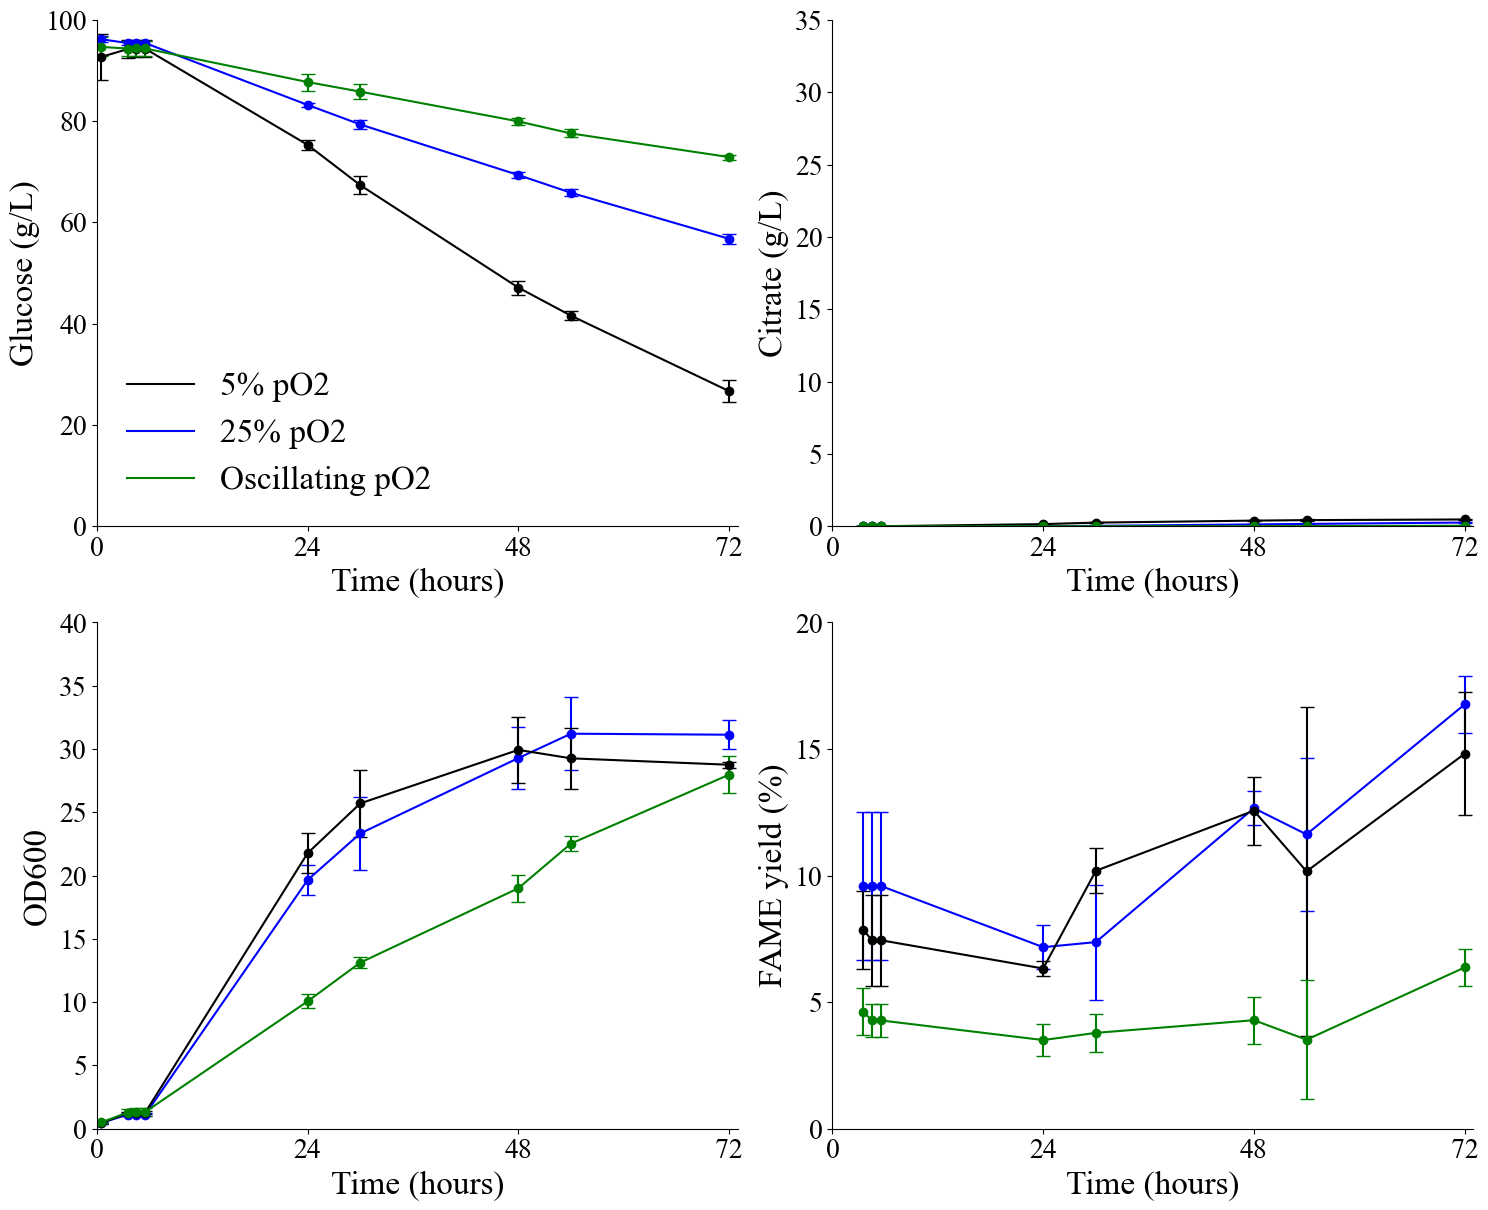

,Panel,Condition,Timepoint_h,Mean,StDev
0,Citrate (g/L),1 min osc,0.5,NaN,NaN
1,Citrate (g/L),1 min osc,3.5,0.000000,0.000000
2,Citrate (g/L),1 min osc,4.5,0.000000,0.000000
3,Citrate (g/L),1 min osc,5.5,0.000000,0.000000
4,Citrate (g/L),1 min osc,24.0,0.004513,0.003250
...,...,...,...,...,...
100,OD600,low O2,24.0,10.066667,0.552891
101,OD600,low O2,30.0,13.126667,0.410636
102,OD600,low O2,48.0,19.000000,1.061822
103,OD600,low O2,54.0,22.533333,0.623396


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# -----------------------------
# Define grouped timepoints
# -----------------------------
grouped_timepoints = np.array([0.5, 3.5, 4.5, 5.5, 24.0, 30.0, 48.0, 54.0, 72.0])
tolerance = 2.0  # hours

# -----------------------------
# Define datasets and styles
# -----------------------------
storages_named = [
    ('Biostat_29_r2', Biostat_29_r2, '1 min osc', 'blue', '-'),
    ('Biostat_30_r1', Biostat_30_r1, 'Control', 'black', '-'),
    ('Biostat_30_r2', Biostat_30_r2, '1 min osc', 'blue', '-'),
    ('Biostat_31_r1', Biostat_31_r1, 'Control', 'black', '-'),
    ('Biostat_31_r2', Biostat_31_r2, '1 min osc', 'blue', '-'),
    ('Biostat_32_r1', Biostat_32_r1, 'Control', 'black', '-'),
    ('Biostat_32_r2', Biostat_32_r2, 'low O2', 'green', '-'),
    ('Biostat_33_r1', Biostat_33_r1, 'low O2', 'green', '-'),
    ('Biostat_34_r1', Biostat_34_r1, 'low O2', 'green', '-'),
    # ('Biostat_35_r1', Biostat_35_r1, 'high O2', 'red', '-'),
    # ('Biostat_35_r2', Biostat_35_r2, 'high O2', 'red', '-'),
]

# -----------------------------
# Helper function:
# bin each replicate to grouped timepoints
# -----------------------------
def bin_to_grouped_timepoints(store, y_col, grouped_timepoints, tolerance=2.0):
    valid = store[['hour', y_col]].dropna().copy()
    x = valid['hour'].to_numpy()
    y = valid[y_col].to_numpy()

    grouped_y = []
    for t0 in grouped_timepoints:
        diffs = np.abs(x - t0)
        in_bin = diffs <= tolerance

        if np.any(in_bin):
            grouped_y.append(np.mean(y[in_bin]))
        else:
            grouped_y.append(np.nan)

    return np.array(grouped_y)

# -----------------------------
# Collect averages + stdev in a dataframe
# -----------------------------
summary_rows = []

def collect_condition_stats(panel_name, label, timepoints, avg_y, std_y):
    for t, mean_val, std_val in zip(timepoints, avg_y, std_y):
        summary_rows.append({
            "Panel": panel_name,
            "Condition": label,
            "Timepoint_h": t,
            "Mean": mean_val,
            "StDev": std_val
        })

# -----------------------------
# Optional: print grouping summary
# -----------------------------
print("\n" + "="*80)
print("GROUPED TIMEPOINTS USED FOR ALL PANELS")
print("="*80)
print(grouped_timepoints)

print("\n" + "="*80)
print("RAW TIMEPOINTS BY CONDITION")
print("="*80)

condition_times = {}
for name, store, label, color, linestyle in storages_named:
    times = store['hour'].dropna().to_numpy()
    condition_times.setdefault(label, []).append((name, times))

for label, reps in condition_times.items():
    print(f"\nCondition: {label}")
    for rep_name, times in reps:
        print(f"  {rep_name}: {np.array2string(times, precision=2, separator=', ')}")

# -----------------------------
# Create 2x2 subplot layout
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(15, 12.2))
axs = axs.flatten()

# -----------------------------
# First 3 panels
# -----------------------------
plot_pairs = [
    ('Glucose.1', 'Glucose (g/L)', (0, 100)),
    ('citrate yield', 'Citrate (g/L)', (0, 35)),

    ('OD600', 'OD600', (0, 40)),
    # ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),

]

xticks_24h = np.arange(0, 75, 24)

for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    aggregated = {}

    for name, store, label, color, linestyle in storages_named:
        if y_col not in store.columns:
            continue

        grouped_y = bin_to_grouped_timepoints(
            store=store,
            y_col=y_col,
            grouped_timepoints=grouped_timepoints,
            tolerance=tolerance
        )

        if label not in aggregated:
            aggregated[label] = {
                'y_values': [],
                'color': color,
                'linestyle': linestyle
            }

        aggregated[label]['y_values'].append(grouped_y)

    for label, group_data in aggregated.items():
        y_array = np.array(group_data['y_values'])
        avg_y = np.nanmean(y_array, axis=0)
        std_y = np.nanstd(y_array, axis=0)

        collect_condition_stats(y_label, label, grouped_timepoints, avg_y, std_y)

        axs[idx].errorbar(
            grouped_timepoints,
            avg_y,
            yerr=std_y,
            label=label,
            color=group_data['color'],
            linestyle=group_data['linestyle'],
            marker='o',
            capsize=5
        )

    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 73)
    axs[idx].set_xticks(xticks_24h)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)
    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)

# -----------------------------
# Fourth panel: FAME
# same grouped-time averaging approach as panels 1–3
# -----------------------------
fame_yield_col = 'FAME yield (g/g biomass)'
idx_fame = 3

aggregated_fame = {}

for name, store, label, color, linestyle in storages_named:
    if fame_yield_col not in store.columns:
        continue

    grouped_y = bin_to_grouped_timepoints(
        store=store,
        y_col=fame_yield_col,
        grouped_timepoints=grouped_timepoints,
        tolerance=tolerance
    )

    if label not in aggregated_fame:
        aggregated_fame[label] = {
            'y_values': [],
            'color': color,
            'linestyle': linestyle
        }

    aggregated_fame[label]['y_values'].append(grouped_y)

# drop first timepoint for FAME panel only
fame_timepoints_plot = grouped_timepoints[1:]

for label, group_data in aggregated_fame.items():
    y_array = np.array(group_data['y_values'])
    avg_y = np.nanmean(y_array, axis=0)
    std_y = np.nanstd(y_array, axis=0)

    avg_y_plot = avg_y[1:] * 100
    std_y_plot = std_y[1:] * 100

    collect_condition_stats("FAME yield (%)", label, fame_timepoints_plot, avg_y_plot, std_y_plot)

    axs[idx_fame].errorbar(
        fame_timepoints_plot,
        avg_y_plot,
        yerr=std_y_plot,
        label=label,
        color=group_data['color'],
        linestyle=group_data['linestyle'],
        marker='o',
        capsize=5
    )

axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
axs[idx_fame].set_xlim(0, 73)
axs[idx_fame].set_xticks(xticks_24h)
axs[idx_fame].set_ylim(0, 20)
axs[idx_fame].set_yticks(np.arange(0, 21, 5))
axs[idx_fame].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)
axs[idx_fame].spines['top'].set_visible(False)
axs[idx_fame].spines['right'].set_visible(False)

# -----------------------------
# Styling and legend
# -----------------------------
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']
custom_lines = [
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
    plt.Line2D([0], [0], color='green', linestyle='-'),
]

axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best', frameon=False)

plt.tight_layout()
# plt.savefig('Biostat_omicsPhenotypeComparison2_groupedAveragedAllPanels.png', bbox_inches='tight')
plt.show()

# -----------------------------
# Save stats for later lookup
# -----------------------------
condition_averages_df = pd.DataFrame(summary_rows)
condition_averages_df = condition_averages_df.sort_values(
    ["Panel", "Condition", "Timepoint_h"]
).reset_index(drop=True)

condition_averages_df

In [21]:
condition_averages_df.to_csv('figure_data_yield.csv')

In [18]:
condition_averages_df

,Panel,Condition,Timepoint_h,Mean,StDev
0,Citrate (g/L),1 min osc,0.5,0.000000,0.000000
1,Citrate (g/L),1 min osc,3.5,0.000000,0.000000
2,Citrate (g/L),1 min osc,4.5,0.000000,0.000000
3,Citrate (g/L),1 min osc,5.5,0.000000,0.000000
4,Citrate (g/L),1 min osc,24.0,0.061567,0.044527
...,...,...,...,...,...
100,OD600,low O2,24.0,10.066667,0.552891
101,OD600,low O2,30.0,13.126667,0.410636
102,OD600,low O2,48.0,19.000000,1.061822
103,OD600,low O2,54.0,22.533333,0.623396


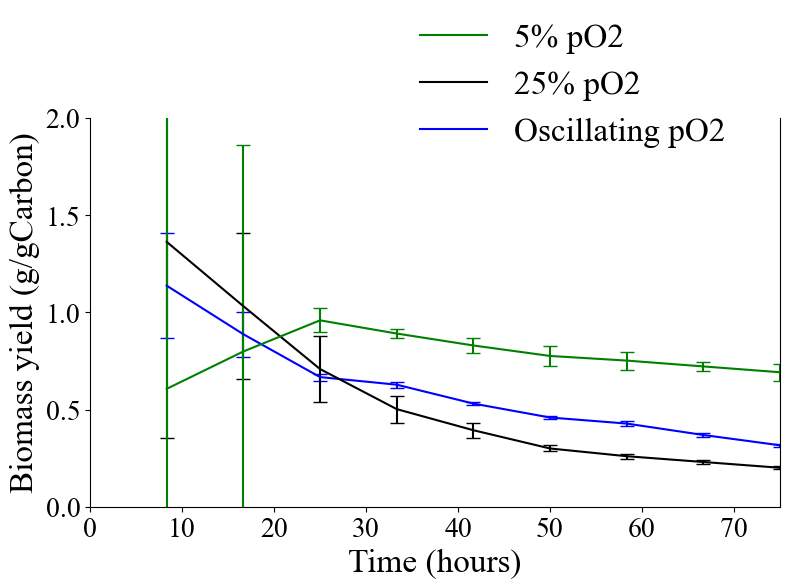

In [96]:


# Define storages and their labels and plotting styles
storages = [
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'),  # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'),  # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'),   # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'),   # low O2 #2
    (Biostat_34_r1, 'low O2', 'green', '-'),   # low O2 #3
    # (Biostat_35_r1, 'high O2', 'red', '-'),    # high O2 #1
    # (Biostat_35_r2, 'high O2', 'red', '-'),    # high O2 #2
]

# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('biomass yield', 'Biomass yield (g/gCarbon)', (0, 2)),
]

# Define a common time grid for interpolation
common_time_grid = np.linspace(0, 75, 10)

# Aggregate data by label with interpolation
data_aggregated = {}
for store, label, color, linestyle in storages:
    if label not in data_aggregated:
        data_aggregated[label] = {'hour': [], 'biomass yield': []}
    f_hour = interp1d(store['hour'], store['biomass yield'], bounds_error=False, fill_value='extrapolate')
    interpolated_yield = f_hour(common_time_grid)
    data_aggregated[label]['hour'].append(common_time_grid)
    data_aggregated[label]['biomass yield'].append(interpolated_yield)

# Compute averages and standard deviations
for label in data_aggregated:
    fame_yields = np.array(data_aggregated[label]['biomass yield'])
    avg_fame_yields = np.mean(fame_yields, axis=0)
    std_fame_yields = np.std(fame_yields, axis=0)
    data_aggregated[label]['avg_hour'] = common_time_grid
    data_aggregated[label]['avg_fame_yield'] = avg_fame_yields
    data_aggregated[label]['std_fame_yield'] = std_fame_yields

# Create a plot
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

for (y_col, y_label, y_lim) in plot_pairs:
    for label in data_aggregated:
        color = storages[[i for i, s in enumerate(storages) if s[1] == label][0]][2]
        linestyle = storages[[i for i, s in enumerate(storages) if s[1] == label][0]][3]
        axs.errorbar(
            data_aggregated[label]['avg_hour'],
            data_aggregated[label]['avg_fame_yield'],
            yerr=data_aggregated[label]['std_fame_yield'],
            label=label,
            color=color,
            linestyle=linestyle,
            capsize=5
        )
    axs.set_xlabel('Time (hours)', fontsize=24)
    axs.set_ylabel(y_label, fontsize=24)
    axs.set_ylim(*y_lim)
    axs.set_xlim(0, 75)
    axs.tick_params(axis='both', which='major', labelsize=20)
    axs.tick_params(axis='both', which='minor', labelsize=10)

# Custom legend
custom_labels = ['5% pO2', '25% pO2', 'Oscillating pO2']

custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    # plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),
]

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

fig.legend(custom_lines, custom_labels, fontsize=24, bbox_to_anchor=(0.95, 1.2), frameon=False)

plt.tight_layout()

axs.spines['top'].set_visible(False)

plt.savefig('Biostat_omicsPhenotypeComparison_DCW.png', bbox_inches='tight')

plt.show()


Bounding box dimensions (in pixels): (0.0, 0.0, 800.0, 500.0)
Bounding box dimensions (in inches): [0.0, 0.0, 8.0, 5.0]


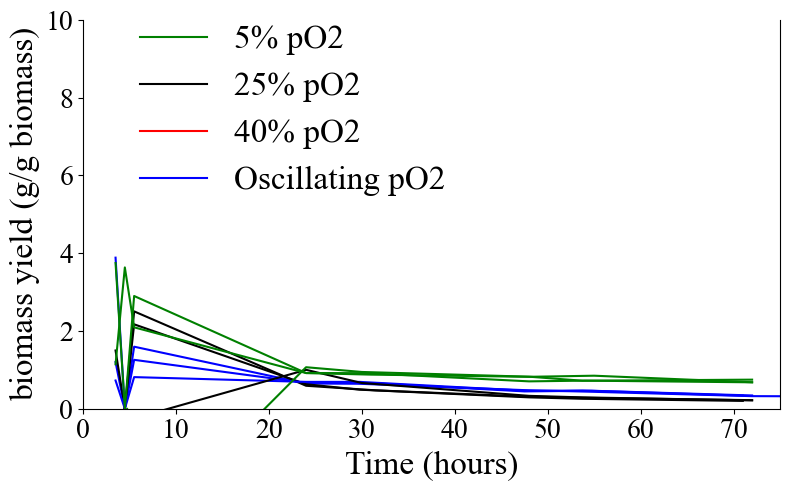

In [97]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

# Define the datasets and their labels and plotting styles
storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (Biostat_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (Biostat_30_r1, 'Control', 'black', '-'),  # control #1
    (Biostat_30_r2, '1 min osc', 'blue', '-'), # oscillating #2
    (Biostat_31_r1, 'Control', 'black', '-'), # control #2
    (Biostat_31_r2, '1 min osc', 'blue', '-'), # oscillating #3
    (Biostat_32_r1, 'Control', 'black', '-'), # control #3
    (Biostat_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (Biostat_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (Biostat_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (Biostat_34_r1, 'low O2', 'green', '-'), # oscillating
    # (Biostat_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
    # (Biostat_35_r1, 'high O2', 'red', '-'), # high O2
    # (Biostat_35_r2, 'high O2', 'red', '-'), # high O2

]

# Define the y-axis labels and their limits for each subplot
# plot_pairs = [
#     # ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
#     # ('DCW (g/L)', 'DCW (g/L)', (0, 25)),
#     ('Citric Acid.1', 'Citrate (g/L)', (0, 35)),
# ]
plot_pairs = [
    # ('Glucose.1', 'Glucose (g/L)', (0, 120)),  # Adjust according to actual data range
    # ('specific_µ_DCW', 'specific_µ_DCW', (0, .25)),
    # ('Citric Acid.1', 'Citrate (g/L)', (0, 45)),
    # ('citrate yield', 'Citrate yield (g/gCarbon)', (0, 1)),
    # ('specific citrate yield (g/g substrate)', 'Citrate yield (g/gCarbon)', (0, .2)),
    # ('FAME yield (g/g biomass)', 'FAME yield (g/g biomass)', (0, .2)),
    ('biomass yield', 'biomass yield (g/g biomass)', (0, 10)),

]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
# axs = axs.flatten()




# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        axs.plot(store['hour'], store[y_col], label=label, color=color, linestyle=linestyle)
    axs.set_xlabel('Time (hours)', fontsize=24)
    axs.set_ylabel(y_label, fontsize=24)
    axs.set_ylim(*y_lim)
    axs.set_xlim(0, 75)
    axs.tick_params(axis='both', which='major', labelsize=20)
    axs.tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
custom_labels = ['Low oxygen', 'Sufficient oxygen', 'High oxygen', 'Oscillating oxygen',]
custom_labels = ['5% pO2', '25% pO2', '40% pO2', 'Oscillating pO2',]

custom_lines = [
    plt.Line2D([0], [0], color='green', linestyle='-'),
    plt.Line2D([0], [0], color='black', linestyle='-'),
    plt.Line2D([0], [0], color='red', linestyle='-'),
    plt.Line2D([0], [0], color='blue', linestyle='-'),

    # plt.Line2D([0], [0], color='orange', linestyle='-'),

    # plt.Line2D([0], [0], color='orange', linestyle='-'),
]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
# axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='right',frameon=False)
fig.legend(custom_lines, custom_labels, fontsize=24,bbox_to_anchor=(0.6, 1), frameon=False)

# Adjust layout
# plt.tight_layout()
plt.tight_layout()

axs.spines['top'].set_visible(False)

# Save and show the plot
plt.savefig('Biostat_omicsPhenotypeComparison_highO2_biomassyield.png', bbox_inches='tight')
# Get the bounding box dimensions
bbox_dims = fig.bbox.bounds
print(f"Bounding box dimensions (in pixels): {bbox_dims}")

# Convert bounding box dimensions to inches
bbox_inches = [dim / fig.dpi for dim in bbox_dims]
print(f"Bounding box dimensions (in inches): {bbox_inches}")

plt.show()



### processData. 

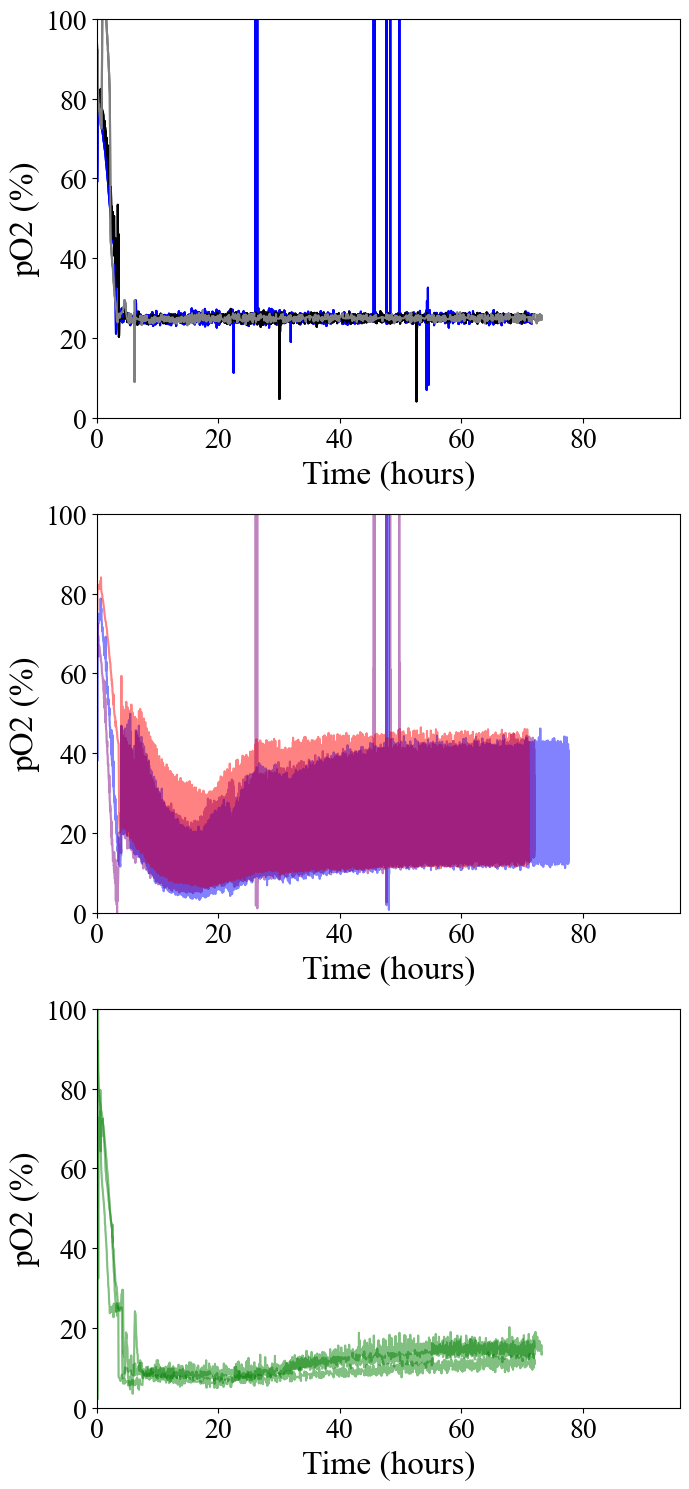

In [104]:
# Create a 2x2 subplot layout
fig, axs = plt.subplots(3, 1, figsize=(7, 15))

# # Define the datasets and their labels and plotting styles
# storages = [
#     (storage_21_r1, 'Control (25% pO2)', 'black', '-'), # control
#     (storage_21_r2, '1 min osc', 'yellow', '-'), # oscillating
#     (storage_23_r1, 'low O2', 'green', '-'),  # pO2 5%   
#     (storage_23_r2, '1 min osc', 'blue', '-'), # oscillating
#     (storage_24_r1, 'Control', 'black', '-'), # control
#     (storage_24_r2, '20 sec osc', 'orange', '-'), # 20 sec oscillating
#     (storage_26_r1, 'low O2', 'red', '-'), # pO2 5% 
#     (storage_26_r2, 'Control', 'black', '-'), # control
#     (storage_27_r1, '1 min osc', 'blue', '-.'), # oscillating
#     (storage_27_r2, 'low O2', 'green', '-.'),  # pO2 5% 
# ]

storages = [
    #(Biostat_29_r1, 'Control (25% pO2)', 'black', '-'), # control - shutdown. 
    (storage_29_r2, '1 min osc', 'blue', '-'), # oscillating #1
    (storage_30_r1, 'Control', 'blue', '-'),  # control #1
    (storage_30_r2, '1 min osc', 'purple', '-'), # oscillating #2
    (storage_31_r1, 'Control', 'black', '-'), # control #2
    (storage_31_r2, '1 min osc', 'red', '-'), # oscillating #3
    (storage_32_r1, 'Control', 'grey', '-'), # control #3
    (storage_32_r2, 'low O2', 'green', '-'), # low O2 #1
    (storage_33_r1, 'low O2', 'green', '-'), # low O2 #2
    # (storage_33_r2, 'low O2', 'orange', '-'),  # low O2 #3
    (storage_34_r1, 'low O2', 'green', '-'), # oscillating
    # (storage_34_r2, 'low O2', 'green', '-'),  # pO2 5% 
    # (storage_35_r1, 'high O2', 'red', '-'), # oscillating
    # (storage_35_r2, 'high O2', 'red', '-'),  # pO2 5% 
]
# Define the y-axis labels and their limits for each subplot
plot_pairs = [
    ('Glucose.1', 'pO2 (%)', (0, 100)),  # Adjust according to actual data range
    ('DCW (g/L)', 'pO2 (%)', (0, 100)),
    ('Citric Acid.1',  'pO2 (%)', (0, 100)),
]

# Adding FAME yield
fame_yield_col = 'FAME yield (g/g biomass)'

# Flatten axs for easier iteration
axs = axs.flatten()

# Iterate over each subplot and each storage dataset to plot
for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        if label == 'Control':
            axs[0].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=label, color=color, linestyle=linestyle)
        if (label == '1 min osc'):
            axs[1].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=label, color=color, linestyle=linestyle,alpha=0.2)
        if label == 'low O2':
            axs[2].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=label, color=color, linestyle=linestyle,alpha=0.2)
        if label == 'high O2':
            axs[3].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'], label=label, color=color, linestyle=linestyle,alpha=0.2)
    axs[idx].set_xlabel('Time (hours)', fontsize=24)
    axs[idx].set_ylabel(y_label, fontsize=24)
    axs[idx].set_ylim(*y_lim)
    axs[idx].set_xlim(0, 96)
    axs[idx].tick_params(axis='both', which='major', labelsize=20)
    axs[idx].tick_params(axis='both', which='minor', labelsize=10)

# Add the FAME yield data to the last subplot
# idx_fame = 3  # this is the index for the last subplot
# for store, label, color, linestyle in storages:
#     if fame_yield_col in store:
#         axs[idx_fame].plot(store['hour'].iloc[1:], store[fame_yield_col].iloc[1:] * 100, label=label, color=color, linestyle=linestyle)
# axs[idx_fame].set_xlabel('Time (hours)', fontsize=24)
# axs[idx_fame].set_ylabel('FAME yield (%)', fontsize=24)
# axs[idx_fame].set_ylim(0, 25)  # Adjust according to actual data range
# axs[idx_fame].set_xlim(0, 96)
# axs[idx_fame].tick_params(axis='both', which='major', labelsize=20)
# axs[idx_fame].tick_params(axis='both', which='minor', labelsize=10)

# Add legend to the first subplot
# axs[0].legend(fontsize=10, loc='best')
# custom_labels = [ '1 min osc', '20 sec osc']
# custom_lines = [
#     # plt.Line2D([0], [0], color='black', linestyle='-'),
#     plt.Line2D([0], [0], color='blue', linestyle='-'),
#     # plt.Line2D([0], [0], color='green', linestyle='-'),
#     plt.Line2D([0], [0], color='orange', linestyle='-'),
# ]
# Apply font styles globally
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
# Add custom legend to the first subplot
# axs[0].legend(custom_lines, custom_labels, fontsize=24, loc='best',frameon=False)

# Adjust layout
plt.tight_layout()

# Save and show the plot
plt.savefig('Biostat_pO2.png')
plt.show()


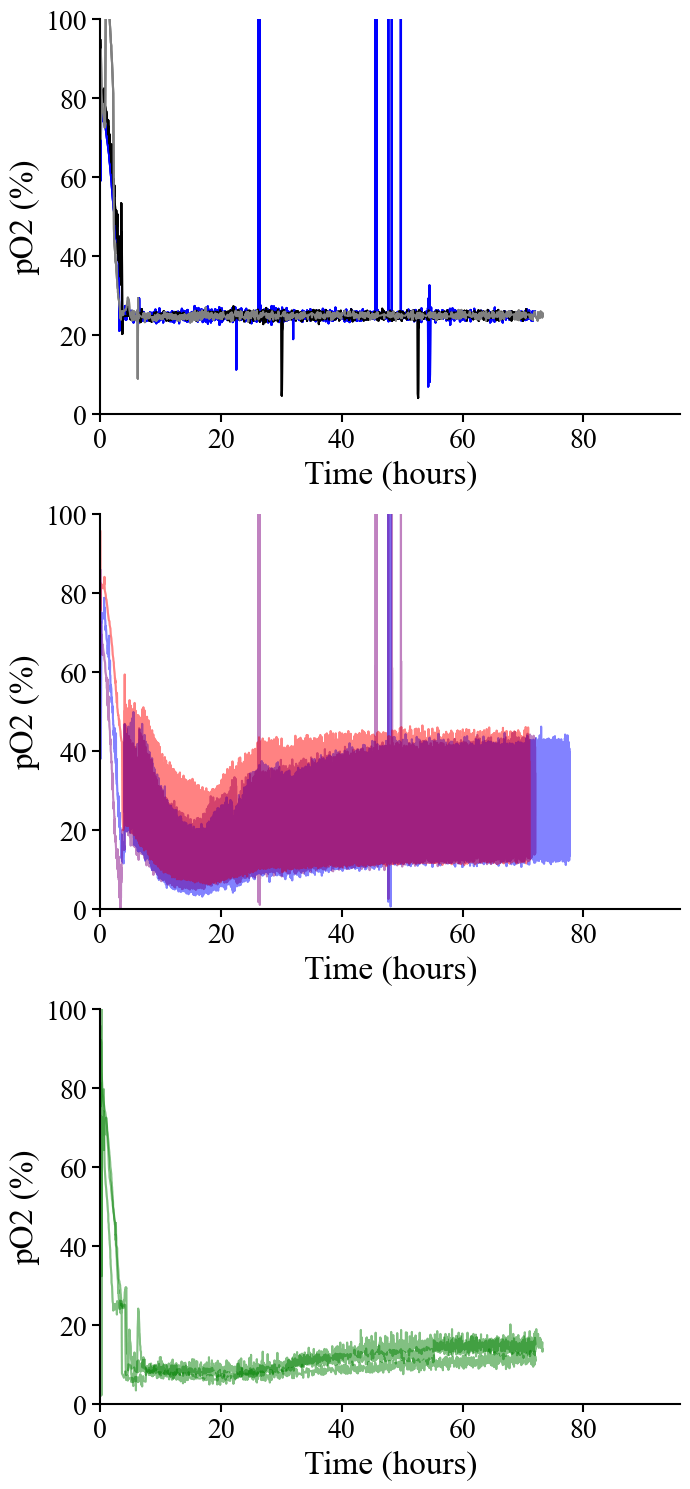

In [105]:
# Adding this near the top, before plotting (or in rcParams block)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['pdf.fonttype'] = 42   # keeps text editable in Illustrator/Inkscape for PDF export
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

# Create a 2x2 subplot layout
fig, axs = plt.subplots(3, 1, figsize=(7, 15))

storages = [
    (storage_29_r2, '1 min osc', 'blue', '-'),
    (storage_30_r1, 'Control', 'blue', '-'),
    (storage_30_r2, '1 min osc', 'purple', '-'),
    (storage_31_r1, 'Control', 'black', '-'),
    (storage_31_r2, '1 min osc', 'red', '-'),
    (storage_32_r1, 'Control', 'grey', '-'),
    (storage_32_r2, 'low O2', 'green', '-'),
    (storage_33_r1, 'low O2', 'green', '-'),
    (storage_34_r1, 'low O2', 'green', '-'),
]

plot_pairs = [
    ('Glucose.1', 'pO2 (%)', (0, 100)),
    ('DCW (g/L)', 'pO2 (%)', (0, 100)),
    ('Citric Acid.1', 'pO2 (%)', (0, 100)),
]

axs = axs.flatten()

for idx, (y_col, y_label, y_lim) in enumerate(plot_pairs):
    for store, label, color, linestyle in storages:
        if label == 'Control':
            axs[0].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'],
                        label=label, color=color, linestyle=linestyle)
        if label == '1 min osc':
            axs[1].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'],
                        label=label, color=color, linestyle=linestyle, alpha=0.2)
        if label == 'low O2':
            axs[2].plot(store['PO2_A_Value']['age'], store['PO2_A_Value']['value'],
                        label=label, color=color, linestyle=linestyle, alpha=0.2)

    ax = axs[idx]
    ax.set_xlabel('Time (hours)', fontsize=24)
    ax.set_ylabel(y_label, fontsize=24)
    ax.set_ylim(*y_lim)
    ax.set_xlim(0, 96)
    ax.tick_params(axis='both', which='major', labelsize=20, width=1.5, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10)

    # --- Remove top/right spines, thicken remaining ones ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()

# --- High-quality save ---
plt.savefig('Biostat_pO2.png', dpi=600, bbox_inches='tight')
plt.savefig('Biostat_pO2.pdf', bbox_inches='tight')  # vector version, ideal for publication
plt.savefig('Biostat_pO2.svg', bbox_inches='tight')  # editable vector version

plt.show()